# Setup  

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
drive.mount('/content/drive')

df_curated = pd.read_excel("/content/drive/MyDrive/data/PPMI_Curated_Data_Cut_Public_20260223.xlsx")

df_vital = pd.read_csv("/content/drive/MyDrive/data/Vital_Signs_22Mar2026.csv")

Mounted at /content/drive


In [3]:
!apt-get install r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.6.0-4.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [4]:
!pip install "rpy2[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.0 MB/s eta 0:00:00


In [5]:
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

In [6]:
%load_ext rpy2.ipython

In [7]:
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packages = ["lcmm"]
# packages = ["lcmm", "moments"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/RtmpfpruW6/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x799be2083490> [0]

In [8]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00


/tmp/ipykernel_1195/2891563905.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# Inclusion criteria  
drug naïve; early course with Hoehn-Yahr stage (H-Y stage) of 1 or 2 at baseline; disease duration within 2 years   


In [9]:
curated = df_curated[[
    # ID
    "PATNO",
    "COHORT",
    "EVENT_ID",

    # time variable
    "YEAR", # visit year, derived from EVENT_ID, numeric
    "visit_date", # Month and Year of Clinical Visit (Note: Collection dates of DATSCAN, lumbar puncture, or other imaging/lab data may be different.)

    # sleep
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    # autonomic dysfunction
    "scopa", # SCOPA-AUT Total Score
    # psychiatric
    "stai", #State-Trait Anxiety Index (STAI) Total Score
    # cognitive
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected), DVT_SDM = 10*SD + 50, where SD is derived as above
    # motor
    "updrs3_score", # Score is based on values taken when participant is either "OFF" PD medication or untreated for PD

    # demo & clinical
    "SEX",
    "EDUCYRS", #Years of Education capped at 20
    "age", # age at enrollment
    "fampd_bin",  # Family History of PD - Binary, 1 Any Family w/PD, 2 No Family w/PD
    "LEDD", # Total Levodopa Equivalent Daily Dose
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "hy", # Reclassified Hoehn & Yahr Stage (includes OFF and untreated scores)
    "ageonset",
    "subgroup",
    "moca",
    "gds",
    "stai_state",
    "stai_trait",
    "pigd",
    "COG_COMPOSITE_INT",
    "COG_COMPOSITE_EXT",
    "td_pigd",
    "ess",
    "MSEADLG",
    "upsit_pctl15"
]].copy()

In [10]:
vs = df_vital[[
    "PATNO",
    "EVENT_ID",
    "SYSSUP",   # Supine BP - systolic (mmHg)
    "SYSSTND"    # Standing BP - systolic (mmHg)
]].copy()

In [11]:
df = curated.merge(
    vs,
    on=["PATNO", "EVENT_ID"],
    how="left",
    validate="one_to_one"
)

In [12]:
df["delta_sbp"] = df["SYSSUP"] - df["SYSSTND"]
df["delta_sbp"].describe()

,delta_sbp
count,17203.000000
mean,4.076731
std,13.370832
min,-77.000000
25%,-4.000000
50%,3.000000
75%,11.000000
max,111.000000


(-50.0, 100.0)

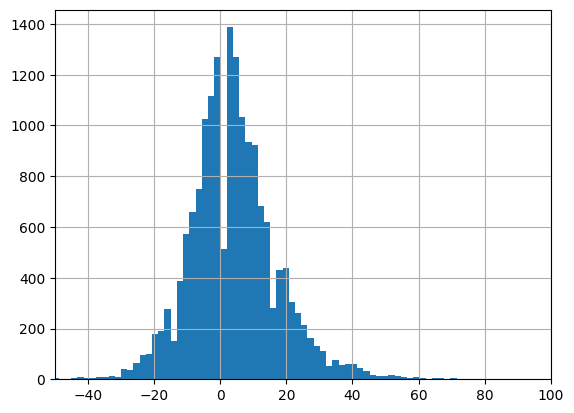

In [13]:
df["delta_sbp"].hist(bins=100)
plt.xlim(-50, 100)

In [14]:
df_pd = df[df["COHORT"] == 1].copy()

In [15]:
bl_pd = df_pd[df_pd["YEAR"] == 0].copy()

In [16]:
# boolean series
mask = (
    (bl_pd["ageonset"] >= 50) &
    (bl_pd["duration_yrs"] <=2) &
    (bl_pd["LEDD"] == 0) &
    (bl_pd["hy"] != 3)
)

ids = bl_pd.loc[mask, "PATNO"].dropna().unique()
print(len(ids))

919


In [17]:
df_pd = df_pd[df_pd["PATNO"].isin(ids)].copy()

In [18]:
visit_counts = df_pd.groupby("PATNO")["YEAR"].nunique()
ids_2plus = visit_counts[visit_counts >=2].index
df_pd_final = df_pd[df_pd["PATNO"].isin(ids_2plus)].copy()

In [19]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 4542
YEAR range: 0 15
count    855.000000
mean       5.312281
std        3.653560
min        2.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       15.000000
Name: YEAR, dtype: float64
YEAR
0     855
1     828
2     671
3     481
4     330
5     244
6     209
7     184
8     130
9     122
10    136
11    128
12    120
13     79
14     23
15      2
Name: PATNO, dtype: int64


In [20]:
df_pd_final = df_pd_final[df_pd_final["YEAR"] <= 5].copy()

In [21]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 3409
YEAR range: 0 5
count    855.000000
mean       3.987135
std        1.491921
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        6.000000
Name: YEAR, dtype: float64
YEAR
0    855
1    828
2    671
3    481
4    330
5    244
Name: PATNO, dtype: int64


In [22]:
vars_model = [
    "rem", "moca", "updrs3_score", "delta_sbp", "gds", "pigd"]

missing_model = df_pd_final[vars_model].isna().mean().sort_values(ascending=False)

print(missing_model)

updrs3_score    0.159871
pigd            0.157524
delta_sbp       0.029921
moca            0.010854
rem             0.008800
gds             0.008800
dtype: float64


In [23]:
'''

report_cross = ProfileReport(
    df_pd_final,
    title="Cross Variables Report",
    explorative=True,
    correlations={
    "pearson": {"calculate": True},
    "spearman": {"calculate": True},
    "phi_k": {"calculate": True}
}
)

report_cross.to_notebook_iframe()

'''

'\n\nreport_cross = ProfileReport(\n    df_pd_final,\n    title="Cross Variables Report",\n    explorative=True,\n    correlations={\n    "pearson": {"calculate": True},\n    "spearman": {"calculate": True},\n    "phi_k": {"calculate": True}\n}\n)\n\nreport_cross.to_notebook_iframe()\n\n'

In [24]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

# MRI Trajectories

In [25]:
# Load the FastSurfer data
fs_data = pd.read_csv('/content/drive/MyDrive/data/FastSurfer_Master_Aggregation.csv')

# Identify the base information columns (first 4)
base_cols = fs_data.columns[:4].tolist()

# Filter columns for Left structures ('Left' or '-lh-')
left_cols = [col for col in fs_data.columns if 'Left' in col or '-lh-' in col]
df_left = fs_data[base_cols + left_cols].copy()

# Filter columns for Right structures ('Right' or '-rh-')
right_cols = [col for col in fs_data.columns if 'Right' in col or '-rh-' in col]
df_right = fs_data[base_cols + right_cols].copy()

# Display the shapes to confirm
print(f"Left dataframe shape: {df_left.shape}")
print(f"Right dataframe shape: {df_right.shape}")

Left dataframe shape: (1036, 49)
Right dataframe shape: (1036, 49)


In [ ]:
display(df_left)

In [27]:
# Function to strip prefixes from column names
def clean_column_names(df, side_prefixes):
    new_cols = []
    for col in df.columns:
        new_col = col
        for pref in side_prefixes:
            if col.startswith(pref):
                new_col = col.replace(pref, "")
                break
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Define prefixes to remove
left_prefixes = ['Left-', 'ctx-lh-']
right_prefixes = ['Right-', 'ctx-rh-']

# Clean the dataframes
# First 4 columns are base_cols, so we don't clean them
df_left_clean = df_left.copy()
df_right_clean = df_right.copy()

clean_column_names(df_left_clean, left_prefixes)
clean_column_names(df_right_clean, right_prefixes)

# Identify region columns (excluding metadata)
regions = [col for col in df_left_clean.columns if col not in base_cols]

# Calculate correlations
correlation_results = []

for region in regions:
    if region in df_right_clean.columns:
        # Extract the series and drop any combined NaNs
        combined = pd.concat([df_left_clean[region], df_right_clean[region]], axis=1).dropna()

        if len(combined) > 1:
            pearson = combined.corr(method='pearson').iloc[0, 1]
            spearman = combined.corr(method='spearman').iloc[0, 1]

            correlation_results.append({
                'Region': region,
                'Pearson_R': pearson,
                'Spearman_R': spearman,
                'N': len(combined)
            })

# Create a results dataframe and display it
df_correlations = pd.DataFrame(correlation_results)
display(df_correlations)

,Region,Pearson_R,Spearman_R,N
0,Cerebral-White-Matter,0.994696,0.994260,1036
1,Lateral-Ventricle,0.920246,0.902667,1036
2,Inf-Lat-Vent,0.894844,0.786941,1036
3,Cerebellum-White-Matter,0.968630,0.968882,1036
4,Cerebellum-Cortex,0.973851,0.974143,1036
5,Thalamus,0.953680,0.947636,1036
6,Caudate,0.939073,0.938378,1036
7,Putamen,0.930030,0.947440,1036
8,Pallidum,0.919285,0.918071,1036
9,Hippocampus,0.904356,0.900105,1036


In [28]:
# Identify region columns
regions = [col for col in df_left_clean.columns if col not in base_cols]

# Create normalized dataframes by dividing structural volumes by MaskVol
# Note: MaskVol is in column index 4 of the original fs_data (or we can extract it specifically)
mask_vol = fs_data['MaskVol']

df_left_norm = df_left_clean[regions].div(mask_vol, axis=0)
df_right_norm = df_right_clean[regions].div(mask_vol, axis=0)

# Re-calculate correlations with normalized data
normalized_correlation_results = []

for region in regions:
    if region in df_right_norm.columns:
        combined = pd.concat([df_left_norm[region], df_right_norm[region]], axis=1).dropna()

        if len(combined) > 1:
            pearson = combined.corr(method='pearson').iloc[0, 1]
            spearman = combined.corr(method='spearman').iloc[0, 1]

            normalized_correlation_results.append({
                'Region': region,
                'Pearson_R_Norm': pearson,
                'Spearman_R_Norm': spearman,
                'N': len(combined)
            })

df_correlations_norm = pd.DataFrame(normalized_correlation_results)
print("Correlations after normalization by MaskVol:")
display(df_correlations_norm)

Correlations after normalization by MaskVol:


,Region,Pearson_R_Norm,Spearman_R_Norm,N
0,Cerebral-White-Matter,0.978665,0.976978,1036
1,Lateral-Ventricle,0.911955,0.891416,1036
2,Inf-Lat-Vent,0.893539,0.779661,1036
3,Cerebellum-White-Matter,0.954836,0.956528,1036
4,Cerebellum-Cortex,0.956423,0.952379,1036
5,Thalamus,0.921574,0.915108,1036
6,Caudate,0.922328,0.912965,1036
7,Putamen,0.899046,0.923623,1036
8,Pallidum,0.876316,0.856522,1036
9,Hippocampus,0.876504,0.873108,1036


In [29]:
# Regions identified with 1035 subjects
check_regions = ['rostralanteriorcingulate', 'Accumbens-area', 'medialorbitofrontal', 'Pallidum']

for region in check_regions:
    # Find subjects where either left or right is NaN or Zero
    mask_missing = (
        df_left_clean[region].isna() | (df_left_clean[region] == 0) |
        df_right_clean[region].isna() | (df_right_clean[region] == 0)
    )

    missing_info = fs_data.loc[mask_missing, ['PATNO', 'EVENT_ID']]
    print(f"\nMissing/Zero data for {region}:")
    if len(missing_info) > 0:
        display(missing_info)
    else:
        print("No explicit NaNs or Zeros found in cleaning; likely dropped during previous concatenation step.")


Missing/Zero data for rostralanteriorcingulate:


,PATNO,EVENT_ID
496,182427,BL



Missing/Zero data for Accumbens-area:


,PATNO,EVENT_ID
496,182427,BL



Missing/Zero data for medialorbitofrontal:


,PATNO,EVENT_ID
496,182427,BL



Missing/Zero data for Pallidum:


,PATNO,EVENT_ID
496,182427,BL


In [30]:
import pandas as pd
import numpy as np

# Initialize a list to store descriptive stats for each region
pct_diff_stats = []

for region in regions:
    if region in df_right_clean.columns:
        left_vals = df_left_clean[region]
        right_vals = df_right_clean[region]

        # Calculate absolute percentage difference per subject
        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Remove NaNs and Infs resulting from division by zero if any
        pct_diff = pct_diff.replace([np.inf, -np.inf], np.nan).dropna()

        if len(pct_diff) > 0:
            pct_diff_stats.append({
                'Region': region,
                'Mean_%_Diff': pct_diff.mean(),
                'Std_%_Diff': pct_diff.std(),
                'Min_%_Diff': pct_diff.min(),
                'Max_%_Diff': pct_diff.max(),
                'N_Subjects': len(pct_diff)
            })

# Create a results dataframe
df_pct_stats = pd.DataFrame(pct_diff_stats).sort_values(by='Mean_%_Diff', ascending=False)

print("Descriptive Statistics for Percentage Differences (|L-R|/Mean * 100):")
display(df_pct_stats)

Descriptive Statistics for Percentage Differences (|L-R|/Mean * 100):


,Region,Mean_%_Diff,Std_%_Diff,Min_%_Diff,Max_%_Diff,N_Subjects
37,rostralanteriorcingulate,37.253482,15.923502,2.425605,99.737916,1035
14,caudalanteriorcingulate,33.103496,18.712059,0.047972,200.000000,1036
43,transversetemporal,29.654958,14.529852,0.152966,83.637823,1036
2,Inf-Lat-Vent,24.147207,18.146463,0.004528,104.697524,1036
19,inferiorparietal,18.810011,9.314254,0.138756,51.901975,1036
1,Lateral-Ventricle,18.661523,14.962831,0.018249,76.258258,1036
32,pericalcarine,15.370661,10.229845,0.045001,56.165169,1036
11,Accumbens-area,15.340027,10.848936,0.038184,89.536097,1035
15,caudalmiddlefrontal,13.523450,10.889787,0.013407,64.370030,1036
31,parstriangularis,13.518577,12.127455,0.025653,198.224954,1036


In [31]:
import pandas as pd
import numpy as np

extreme_cases = []

for region in regions:
    if region in df_right_clean.columns:
        left_vals = df_left_clean[region]
        right_vals = df_right_clean[region]

        # Calculate absolute percentage difference
        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > 100
        outliers = pct_diff[pct_diff > 100].index

        for idx in outliers:
            extreme_cases.append({
                'PATNO': fs_data.loc[idx, 'PATNO'],
                'EVENT_ID': fs_data.loc[idx, 'EVENT_ID'],
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_extreme = pd.DataFrame(extreme_cases)

if not df_extreme.empty:
    print("Cases with >100% asymmetry:")
    summary_sessions = df_extreme.groupby(['PATNO', 'EVENT_ID']).agg(
        Failed_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index()
    display(summary_sessions)
else:
    print("No cases found with >100% asymmetry.")

Cases with >100% asymmetry:


,PATNO,EVENT_ID,Failed_Regions_Count,Regions_List
0,3314,BL,1,lingual
1,3314,V04,1,lingual
2,102054,BL,1,Inf-Lat-Vent
3,102054,V04,1,Inf-Lat-Vent
4,182427,BL,7,"Cerebellum-White-Matter, Putamen, caudalanteri..."


In [32]:
import pandas as pd
import numpy as np

# 1. Define the exclusion criteria
exclude_mask = (fs_data['PATNO'] == 182427) & (fs_data['EVENT_ID'] == 'BL')

# 2. Filter all relevant dataframes
fs_data = fs_data[~exclude_mask].reset_index(drop=True)
df_left_clean = df_left_clean[~exclude_mask].reset_index(drop=True)
df_right_clean = df_right_clean[~exclude_mask].reset_index(drop=True)

print(f"Removed scan 182427 BL. New row count: {len(fs_data)}")

# 3. Re-run asymmetry check with 75% threshold
threshold = 75
flagged_cases = []

# 'regions' variable is defined in previous cells
for region in regions:
    if region in df_right_clean.columns:
        left_vals = df_left_clean[region]
        right_vals = df_right_clean[region]

        # Calculate absolute percentage difference
        # |L - R| / Mean(L, R) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > threshold
        outliers = pct_diff[pct_diff > threshold].index

        for idx in outliers:
            flagged_cases.append({
                'PATNO': fs_data.loc[idx, 'PATNO'],
                'EVENT_ID': fs_data.loc[idx, 'EVENT_ID'],
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_flagged = pd.DataFrame(flagged_cases)

if not df_flagged.empty:
    print(f"\nSessions with at least one region exceeding {threshold}% asymmetry:")
    summary_flagged = df_flagged.groupby(['PATNO', 'EVENT_ID']).agg(
        Flagged_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index().sort_values(by='Flagged_Regions_Count', ascending=False)
    display(summary_flagged)
else:
    print(f"\nNo cases found exceeding {threshold}% asymmetry threshold.")

Removed scan 182427 BL. New row count: 1035

Sessions with at least one region exceeding 75% asymmetry:


,PATNO,EVENT_ID,Flagged_Regions_Count,Regions_List
4,3314,BL,2,"lingual, transversetemporal"
5,3314,V04,2,"lingual, transversetemporal"
0,3118,V04,1,rostralanteriorcingulate
2,3131,BL,1,rostralanteriorcingulate
1,3118,V06,1,rostralanteriorcingulate
3,3131,V04,1,rostralanteriorcingulate
6,3323,V08,1,Accumbens-area
7,3592,V04,1,Inf-Lat-Vent
8,3780,BL,1,caudalanteriorcingulate
9,3780,V04,1,caudalanteriorcingulate


# MRI Preparation

In [33]:
path_vol = "/content/drive/MyDrive/data/Volume values summarized over ASEG parcellation_17Aug2025.csv"
path_SA = "/content/drive/MyDrive/data/Surface area (SA) values summarized over aparc parcellation_17Aug2025.csv"
path_CTh = "/content/drive/MyDrive/data/Cortical thickness (CTh) values summarized over aparc parcellation_17Aug2025.csv"
path_mriqc = "/content/drive/MyDrive/data/MRIQC metrics for T1-weighted images_17Aug2025.csv"

## Volumes

In [34]:
volumes_to_norm = [
    "Optic_Chiasm",
    "Right_Lateral_Ventricle",
    "CC_Central",
    "5th_Ventricle",
    "Right_choroid_plexus",
    "Left_vessel",
    "Left_Cerebellum_Cortex",
    "TotalGrayVol",
    "Left_choroid_plexus",
    "Right_Inf_Lat_Vent",
    "Left_Pallidum",
    "Left_Thalamus",
    "Right_VentralDC",
    "rhCortexVol",
    "Right_Amygdala",
    "Left_Amygdala",
    "4th_Ventricle",
    "Left_Inf_Lat_Vent",
    "Right_Pallidum",
    "lhCortexVol",
    "CC_Anterior",
    "CC_Posterior",
    "Left_Accumbens_area",
    "Right_vessel",
    "Right_Cerebellum_Cortex",
    "Left_Putamen",
    "3rd_Ventricle",
    "non_WM_hypointensities",
    "Right_Caudate",
    "CC_Mid_Posterior",
    "Left_Hippocampus",
    "Right_Hippocampus",
    "Left_Caudate",
    "Right_Putamen",
    "WM_hypointensities",
    "Right_Accumbens_area",
    "Left_VentralDC",
    "CC_Mid_Anterior",
    "SubCortGrayVol",
    "Right_Thalamus",
    "Left_Lateral_Ventricle",
    "SurfaceHoles",
    "CerebralWhiteMatterVol"
]

In [ ]:
cols_vol = ["PATNO"] + volumes_to_norm + ["EstimatedTotalIntraCranialVol"]
df_vol = pd.read_csv(path_vol, usecols=cols_vol)

display(df_vol.head())

In [36]:
df_vol[volumes_to_norm] = df_vol[volumes_to_norm].div(df_vol["EstimatedTotalIntraCranialVol"], axis=0)
df_vol.drop(columns=["EstimatedTotalIntraCranialVol"], inplace=True)

In [ ]:
display(df_vol.head())

Averaging or considering only one side of the brain is common in analysis of MRI data, for example: https://pmc.ncbi.nlm.nih.gov/articles/PMC3316476/.

In [ ]:
df_vol_rh = df_vol.loc[:, df_vol.columns.str.contains("PATNO|Right|rh")]
df_vol_lh = df_vol.loc[:, df_vol.columns.str.contains("PATNO|Left|lh")]
df_vol_both = df_vol.loc[:, ~df_vol.columns.str.contains("Right|Left|lh|rh")]

display(df_vol_both)

In [ ]:
display(df_vol_lh.head())

In [ ]:
display(df_vol_rh.head())

In [ ]:
df_vol_rh.columns = df_vol_rh.columns.str.replace("Right_", "")
df_vol_rh.columns = df_vol_rh.columns.str.replace("rh", "")
df_vol_lh.columns = df_vol_lh.columns.str.replace("Left_", "")
df_vol_lh.columns = df_vol_lh.columns.str.replace("lh", "")
lh_indexing = df_vol_lh.columns
df_vol_rh = df_vol_rh[lh_indexing]
# rearrange columns so that the left and right regions are at the same column index in their respective dataframes

display(df_vol_rh)
print(lh_indexing)

In [42]:
df_corr1 = pd.DataFrame({'Pearson': df_vol_rh.corrwith(df_vol_lh, axis=0, method="pearson"),
                        'Spearman': df_vol_rh.corrwith(df_vol_lh, axis=0, method="spearman")})
display(df_corr1)

,Pearson,Spearman
PATNO,1.000000,1.000000
vessel,0.286563,0.412508
Cerebellum_Cortex,0.957744,0.948929
choroid_plexus,0.788381,0.786011
Pallidum,0.756496,0.748152
Thalamus,0.850576,0.840325
Amygdala,0.807755,0.803125
Inf_Lat_Vent,0.794894,0.713040
CortexVol,0.986438,0.982719
Accumbens_area,0.768464,0.757798


In [ ]:
from functools import reduce

df_vol_avg = reduce(lambda x, y: x.add(y), [df_vol_lh, df_vol_rh]) / 2    # add up all elements and divide by 2
df_vol_both = df_vol_both.merge(df_vol_avg.drop(columns=["PATNO", "vessel"]), left_index=True, right_index=True)
display(df_vol_both)

In [44]:
import pandas as pd
import numpy as np

# Initialize a list to store descriptive stats for each FreeSurfer volume region
fs_vol_pct_diff_stats = []

# Identify region columns (excluding PATNO)
# We use the cleaned column names from df_vol_lh and df_vol_rh which already align
regions_fs = [col for col in df_vol_lh.columns if col not in ['PATNO', 'vessel']]

for region in regions_fs:
    if region in df_vol_rh.columns:
        left_vals = df_vol_lh[region]
        right_vals = df_vol_rh[region]

        # Calculate absolute percentage difference per subject
        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Remove NaNs and Infs resulting from division by zero if any
        pct_diff = pct_diff.replace([np.inf, -np.inf], np.nan).dropna()

        if len(pct_diff) > 0:
            fs_vol_pct_diff_stats.append({
                'Region': region,
                'Mean_%_Diff': pct_diff.mean(),
                'Std_%_Diff': pct_diff.std(),
                'Min_%_Diff': pct_diff.min(),
                'Max_%_Diff': pct_diff.max(),
                'N_Subjects': len(pct_diff)
            })

# Create a results dataframe
df_fs_vol_pct_stats = pd.DataFrame(fs_vol_pct_diff_stats).sort_values(by='Mean_%_Diff', ascending=False)

print("Descriptive Statistics for FreeSurfer Volume Percentage Differences (|L-R|/Mean * 100):")
display(df_fs_vol_pct_stats)

Descriptive Statistics for FreeSurfer Volume Percentage Differences (|L-R|/Mean * 100):


,Region,Mean_%_Diff,Std_%_Diff,Min_%_Diff,Max_%_Diff,N_Subjects
5,Inf_Lat_Vent,34.537522,27.096550,0.099817,195.623632,1713
7,Accumbens_area,24.355760,17.755629,0.042830,92.614770,1713
12,Lateral_Ventricle,17.409840,14.259661,0.006101,89.136700,1713
1,choroid_plexus,17.020110,13.555319,0.031521,102.992407,1713
4,Amygdala,11.446956,8.836274,0.000000,125.999908,1713
2,Pallidum,6.826658,5.849995,0.000000,72.171685,1713
10,Caudate,5.489942,5.654802,0.011348,92.025005,1713
9,Hippocampus,5.240451,5.057877,0.008744,83.810376,1713
3,Thalamus,4.955755,4.351874,0.010079,33.150508,1713
8,Putamen,4.546109,5.805103,0.000000,115.444962,1713


In [45]:
import pandas as pd
import numpy as np

fs_vol_extreme_cases = []

# Using regions_fs defined in the previous analysis
for region in regions_fs:
    if region in df_vol_rh.columns:
        left_vals = df_vol_lh[region]
        right_vals = df_vol_rh[region]

        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > 100
        outliers = pct_diff[pct_diff > 100].index

        for idx in outliers:
            # We use the original df_vol or a lookup to get the PATNO
            patno = df_vol_lh.loc[idx, 'PATNO']
            fs_vol_extreme_cases.append({
                'PATNO': patno,
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_fs_vol_extreme = pd.DataFrame(fs_vol_extreme_cases)

# Filter df_fs_vol_extreme to include only PATNOs present in df_pd_final
patnos_in_pd_final = df_pd_final['PATNO'].unique()
df_fs_vol_extreme_filtered = df_fs_vol_extreme[df_fs_vol_extreme['PATNO'].isin(patnos_in_pd_final)].copy()

if not df_fs_vol_extreme_filtered.empty:
    print("FreeSurfer cases with >100% asymmetry (filtered to df_pd_final subjects):")
    summary_fs_extreme = df_fs_vol_extreme_filtered.groupby(['PATNO']).agg(
        Failed_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index().sort_values(by='Failed_Regions_Count', ascending=False)
    display(summary_fs_extreme)
else:
    print("No FreeSurfer volume cases found with >100% asymmetry within df_pd_final subjects.")

FreeSurfer cases with >100% asymmetry (filtered to df_pd_final subjects):


,PATNO,Failed_Regions_Count,Regions_List
0,3076,1,Inf_Lat_Vent
1,3409,1,Inf_Lat_Vent
2,3417,1,Inf_Lat_Vent
3,3763,1,Inf_Lat_Vent
4,3957,1,Putamen
5,3972,1,Inf_Lat_Vent
6,101799,1,Inf_Lat_Vent
7,111278,1,Inf_Lat_Vent


In [46]:
import pandas as pd
import numpy as np

fs_vol_extreme_cases = []

# Using regions_fs defined in the previous analysis
for region in regions_fs:
    if region in df_vol_rh.columns:
        left_vals = df_vol_lh[region]
        right_vals = df_vol_rh[region]

        # Formula: |L - R| / ((L + R) / 2) * 100
        diff = np.abs(left_vals - right_vals)
        mean_lr = (left_vals + right_vals) / 2
        pct_diff = (diff / mean_lr) * 100

        # Identify indices where pct_diff > 75
        outliers = pct_diff[pct_diff > 75].index

        for idx in outliers:
            # We use the original df_vol or a lookup to get the PATNO
            patno = df_vol_lh.loc[idx, 'PATNO']
            fs_vol_extreme_cases.append({
                'PATNO': patno,
                'Region': region,
                'Pct_Diff': pct_diff[idx],
                'Left_Vol': left_vals[idx],
                'Right_Vol': right_vals[idx]
            })

df_fs_vol_extreme = pd.DataFrame(fs_vol_extreme_cases)

# Filter df_fs_vol_extreme to include only PATNOs present in df_pd_final
patnos_in_pd_final = df_pd_final['PATNO'].unique()
df_fs_vol_extreme_filtered = df_fs_vol_extreme[df_fs_vol_extreme['PATNO'].isin(patnos_in_pd_final)].copy()

if not df_fs_vol_extreme_filtered.empty:
    print("FreeSurfer cases with >75% asymmetry (filtered to df_pd_final subjects):")
    summary_fs_extreme = df_fs_vol_extreme_filtered.groupby(['PATNO']).agg(
        Failed_Regions_Count=('Region', 'count'),
        Regions_List=('Region', lambda x: ', '.join(x))
    ).reset_index().sort_values(by='Failed_Regions_Count', ascending=False)
    display(summary_fs_extreme)
else:
    print("No FreeSurfer volume cases found with >75% asymmetry within df_pd_final subjects.")

FreeSurfer cases with >75% asymmetry (filtered to df_pd_final subjects):


,PATNO,Failed_Regions_Count,Regions_List
14,3630,2,"Inf_Lat_Vent, Accumbens_area"
1,3076,1,Inf_Lat_Vent
0,3056,1,Inf_Lat_Vent
3,3269,1,Caudate
4,3275,1,Caudate
5,3285,1,choroid_plexus
2,3251,1,Accumbens_area
6,3307,1,Accumbens_area
7,3325,1,Inf_Lat_Vent
9,3409,1,Inf_Lat_Vent


## Surface Areas and Cortical Thicknesses

In [ ]:
df_SA = pd.read_csv(path_SA)
df_CTh = pd.read_csv(path_CTh)

df_SA_rh = df_SA.loc[:, df_SA.columns.str.contains("PATNO|rh_")]
df_SA_lh = df_SA.loc[:, df_SA.columns.str.contains("PATNO|lh_")]

df_CTh_rh = df_CTh.loc[:, df_CTh.columns.str.contains("PATNO|rh_")]
df_CTh_lh = df_CTh.loc[:, df_CTh.columns.str.contains("PATNO|lh_")]

display(df_SA_rh.head())

In [ ]:
display(df_SA_lh)

In [49]:
# Explicitly create copies and cast to float to ensure correct dtypes and avoid FutureWarning
df_SA_rh = df_SA_rh.copy()
df_SA_lh = df_SA_lh.copy()

for df in [df_SA_rh, df_SA_lh]:
    cols_to_convert = df.columns[~df.columns.str.contains("PATNO")]
    df[cols_to_convert] = df[cols_to_convert].astype(float)

In [50]:
# --- Calculate Percentage Differences for Surface Area (SA) ---
# Ensure PATNO is the index for cleaner operations
sa_rh_indexed = df_SA_rh.set_index("PATNO")
sa_lh_indexed = df_SA_lh.set_index("PATNO")

# FIX: Rename columns to remove hemisphere prefixes so they align for arithmetic
sa_rh_indexed.columns = sa_rh_indexed.columns.str.replace("rh_", "")
sa_lh_indexed.columns = sa_lh_indexed.columns.str.replace("lh_", "")

# Calculate percentage difference: (Right - Left) / (Mean(Right, Left)) * 100
df_sa_pct_diff = ((sa_rh_indexed - sa_lh_indexed) / ((sa_rh_indexed + sa_lh_indexed) / 2)) * 100
df_sa_pct_diff.columns = [f"{col}_pct_diff" for col in df_sa_pct_diff.columns]

print("Descriptive statistics for Surface Area Percentage Differences (RH vs LH) - Before Normalization:")
display(df_sa_pct_diff.describe().T)

# --- Calculate Percentage Differences for Cortical Thickness (CTh) ---
cth_rh_indexed = df_CTh_rh.set_index("PATNO")
cth_lh_indexed = df_CTh_lh.set_index("PATNO")

# FIX: Rename columns to remove hemisphere prefixes
cth_rh_indexed.columns = cth_rh_indexed.columns.str.replace("rh_", "")
cth_lh_indexed.columns = cth_lh_indexed.columns.str.replace("lh_", "")

df_cth_pct_diff = ((cth_rh_indexed - cth_lh_indexed) / ((cth_rh_indexed + cth_lh_indexed) / 2)) * 100
df_cth_pct_diff.columns = [f"{col}_pct_diff" for col in df_cth_pct_diff.columns]

print("\nDescriptive statistics for Cortical Thickness Percentage Differences (RH vs LH) - Before Normalization:")
display(df_cth_pct_diff.describe().T)

Descriptive statistics for Surface Area Percentage Differences (RH vs LH) - Before Normalization:


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,-9.608411,16.419244,-89.708310,-19.649327,-8.842314,0.924980,61.883408
caudalanteriorcingulate_pct_diff,1716.0,15.468900,25.873589,-87.348735,-2.237972,14.871085,33.045483,98.039216
caudalmiddlefrontal_pct_diff,1716.0,-6.272417,14.423156,-65.850673,-15.390562,-6.489628,2.315638,66.977746
cuneus_pct_diff,1716.0,5.917541,12.184037,-88.613303,-0.814706,6.115340,12.841492,81.328751
entorhinal_pct_diff,1716.0,-8.664826,18.342674,-70.879121,-20.514050,-9.041991,3.004928,67.684478
fusiform_pct_diff,1716.0,-2.517366,9.104114,-39.059929,-8.273792,-2.302229,3.616583,25.153282
inferiorparietal_pct_diff,1716.0,18.482408,12.116813,-46.503011,11.134509,18.506404,26.332677,63.439453
inferiortemporal_pct_diff,1716.0,-4.349854,10.599828,-46.457990,-11.420925,-4.314972,2.497717,31.613372
isthmuscingulate_pct_diff,1716.0,-11.442570,17.776628,-200.000000,-19.562323,-11.059570,-2.235326,194.630872
lateraloccipital_pct_diff,1716.0,0.271286,9.743321,-43.350338,-6.100989,-0.177397,6.662555,40.664052



Descriptive statistics for Cortical Thickness Percentage Differences (RH vs LH) - Before Normalization:


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,3.226211,8.166934,-59.804878,-1.499783,3.473992,7.927745,50.819217
caudalanteriorcingulate_pct_diff,1716.0,-4.621733,9.865744,-38.583786,-10.975575,-4.782915,1.268093,32.670700
caudalmiddlefrontal_pct_diff,1716.0,-1.547249,5.621144,-28.654124,-4.873698,-1.547363,1.961392,19.688155
cuneus_pct_diff,1716.0,2.292347,6.548111,-33.015873,-1.966242,2.339856,6.723455,45.720637
entorhinal_pct_diff,1716.0,1.532567,9.401615,-46.777514,-3.693218,1.812645,6.869375,62.382499
fusiform_pct_diff,1716.0,0.568973,4.593840,-32.248521,-1.848887,0.676778,3.130187,28.383627
inferiorparietal_pct_diff,1716.0,1.665735,4.592993,-41.787440,-0.948866,1.632304,4.504198,17.136659
inferiortemporal_pct_diff,1716.0,0.680563,4.690067,-22.894905,-2.189415,0.636185,3.492326,23.481467
isthmuscingulate_pct_diff,1716.0,0.099078,8.795370,-200.000000,-4.626550,0.311281,4.437332,45.536723
lateraloccipital_pct_diff,1716.0,2.792601,4.525933,-26.590374,-0.090939,2.943697,5.786097,18.978102


In [ ]:
# Normalization by total surface area of each hemisphere

df_SA_rh.loc[:, ~df_SA_rh.columns.str.contains("PATNO|SurfArea")] = df_SA_rh.loc[:, ~df_SA_rh.columns.str.contains("PATNO|SurfArea")].div(df_SA_rh["rh_WhiteSurfArea"], axis=0)
df_SA_lh.loc[:, ~df_SA_lh.columns.str.contains("PATNO|SurfArea")] = df_SA_lh.loc[:, ~df_SA_lh.columns.str.contains("PATNO|SurfArea")].div(df_SA_lh["lh_WhiteSurfArea"], axis=0)

display(df_SA_rh.head())

In [ ]:
# Normalization by mean thickness of each hemisphere

df_CTh_rh.loc[:, ~df_CTh_rh.columns.str.contains("PATNO|MeanThickness")] = df_CTh_rh.loc[:, ~df_CTh_rh.columns.str.contains("PATNO|MeanThickness")].div(df_CTh_rh["rh_MeanThickness"], axis=0)
df_CTh_lh.loc[:, ~df_CTh_lh.columns.str.contains("PATNO|MeanThickness")] = df_CTh_lh.loc[:, ~df_CTh_lh.columns.str.contains("PATNO|MeanThickness")].div(df_CTh_lh["lh_MeanThickness"], axis=0)

display(df_CTh_rh.head())

In [53]:
df_SA_rh.columns = df_SA_rh.columns.str.replace("rh_", "")
df_SA_lh.columns = df_SA_lh.columns.str.replace("lh_", "")

# Left and Right columns are already aligned with each other, correlations can be calculated without further manipulation

df_corr2 = pd.DataFrame({'Pearson': df_SA_rh.corrwith(df_SA_lh, axis=0, method="pearson"),
                        'Spearman': df_SA_rh.corrwith(df_SA_lh, axis=0, method="spearman")})
display(df_corr2)


,Pearson,Spearman
PATNO,1.000000,1.000000
bankssts,0.286559,0.283577
caudalanteriorcingulate,0.212535,0.061991
caudalmiddlefrontal,0.358390,0.397868
cuneus,0.619637,0.628073
entorhinal,0.590094,0.518638
fusiform,0.444647,0.415227
inferiorparietal,0.390231,0.377892
inferiortemporal,0.413338,0.391804
isthmuscingulate,0.466525,0.452945


In [54]:
df_CTh_rh.columns = df_CTh_rh.columns.str.replace("rh_", "")
df_CTh_lh.columns = df_CTh_lh.columns.str.replace("lh_", "")

df_corr3 = pd.DataFrame({'Pearson': df_CTh_rh.corrwith(df_CTh_lh, axis=0, method="pearson"),
                        'Spearman': df_CTh_rh.corrwith(df_CTh_lh, axis=0, method="spearman")})
display(df_corr3)

,Pearson,Spearman
PATNO,1.000000,1.000000
bankssts,0.429109,0.300581
caudalanteriorcingulate,0.510250,0.467603
caudalmiddlefrontal,0.543211,0.478111
cuneus,0.578647,0.553155
entorhinal,0.545980,0.550526
fusiform,0.641451,0.594450
inferiorparietal,0.546354,0.492220
inferiortemporal,0.678141,0.622768
isthmuscingulate,0.557845,0.592439


In [55]:
# --- Calculate Percentage Differences for Surface Area (SA) ---
# Ensure PATNO is the index for cleaner operations and align dataframes
sa_rh_indexed = df_SA_rh.set_index("PATNO")
sa_lh_indexed = df_SA_lh.set_index("PATNO")

# Calculate percentage difference: (Right - Left) / (Mean(Right, Left)) * 100
df_sa_pct_diff = ((sa_rh_indexed - sa_lh_indexed) / ((sa_rh_indexed + sa_lh_indexed) / 2)) * 100
df_sa_pct_diff.columns = [f"{col}_pct_diff" for col in df_sa_pct_diff.columns]

print("Descriptive statistics for Surface Area Percentage Differences (RH vs LH):")
display(df_sa_pct_diff.describe().T) # Transpose to make regions rows

# --- Calculate Percentage Differences for Cortical Thickness (CTh) ---
cth_rh_indexed = df_CTh_rh.set_index("PATNO")
cth_lh_indexed = df_CTh_lh.set_index("PATNO")

df_cth_pct_diff = ((cth_rh_indexed - cth_lh_indexed) / ((cth_rh_indexed + cth_lh_indexed) / 2)) * 100
df_cth_pct_diff.columns = [f"{col}_pct_diff" for col in df_cth_pct_diff.columns]

print("\nDescriptive statistics for Cortical Thickness Percentage Differences (RH vs LH):")
display(df_cth_pct_diff.describe().T)

Descriptive statistics for Surface Area Percentage Differences (RH vs LH):


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,-9.652214,16.308301,-86.407463,-19.575308,-9.001630,0.850332,57.117143
caudalanteriorcingulate_pct_diff,1716.0,15.427190,25.849151,-74.464650,-2.297171,14.972455,33.112627,97.046798
caudalmiddlefrontal_pct_diff,1716.0,-6.314023,14.346969,-65.700381,-15.415756,-6.409588,2.578714,66.354127
cuneus_pct_diff,1716.0,5.874678,12.125240,-88.289495,-0.893057,6.089291,12.827973,89.946309
entorhinal_pct_diff,1716.0,-8.707355,18.329431,-70.492097,-20.730781,-8.929393,2.740739,66.877802
fusiform_pct_diff,1716.0,-2.559244,8.998585,-36.703372,-8.299832,-2.350846,3.456449,25.553767
inferiorparietal_pct_diff,1716.0,18.441978,11.967362,-45.546595,11.005743,18.431999,26.049894,63.690043
inferiortemporal_pct_diff,1716.0,-4.391836,10.512870,-45.307410,-11.403938,-4.506895,2.246096,33.491119
isthmuscingulate_pct_diff,1716.0,-11.489188,17.746490,-200.000000,-19.561348,-11.079223,-2.519891,194.638331
lateraloccipital_pct_diff,1716.0,0.229693,9.637724,-44.232596,-6.107407,-0.156681,6.407837,40.878726



Descriptive statistics for Cortical Thickness Percentage Differences (RH vs LH):


,count,mean,std,min,25%,50%,75%,max
bankssts_pct_diff,1716.0,3.481217,7.788680,-35.038732,-1.174293,3.541198,8.257670,48.807455
caudalanteriorcingulate_pct_diff,1716.0,-4.366794,9.729206,-38.852944,-10.469338,-4.695502,1.475403,33.420952
caudalmiddlefrontal_pct_diff,1716.0,-1.291522,5.267431,-27.076662,-4.354543,-1.241582,1.922063,20.760718
cuneus_pct_diff,1716.0,2.548204,6.530214,-29.959270,-1.806820,2.639552,6.951975,45.723449
entorhinal_pct_diff,1716.0,1.788119,9.311362,-45.145238,-3.644456,1.924776,7.178559,57.852561
fusiform_pct_diff,1716.0,0.825015,4.272805,-32.227618,-1.644731,0.933370,3.285517,24.617280
inferiorparietal_pct_diff,1716.0,1.921422,4.156768,-16.091488,-0.624032,1.817958,4.481674,27.060612
inferiortemporal_pct_diff,1716.0,0.936663,4.319268,-20.427747,-1.724440,0.899349,3.445353,18.400904
isthmuscingulate_pct_diff,1716.0,0.357954,8.780490,-200.000000,-4.013021,0.441603,4.753931,43.696887
lateraloccipital_pct_diff,1716.0,3.048534,4.362297,-16.095855,0.313946,3.194154,5.976240,25.309272


# Outlier Detection using MRIQC and Gapstatistics

## MRIQC

In [56]:
qc_metrics = ["PATNO",
              "cjv",
              "cnr",
              "efc"]

In [ ]:
df_mriqc = pd.read_csv(path_mriqc, usecols=qc_metrics)

display(df_mriqc)

In [58]:
df_mriqc.describe()

,PATNO,cjv,cnr,efc
count,1740.000000,1740.000000,1740.000000,1740.000000
mean,70298.694253,0.818699,1.249495,0.549825
std,64436.514405,2.310759,0.305536,0.074178
min,3000.000000,0.429414,0.011224,0.371809
25%,3823.750000,0.645180,1.037725,0.501683
50%,56576.500000,0.724835,1.230715,0.537063
75%,118445.500000,0.811145,1.436253,0.580438
max,224562.000000,89.602400,2.340770,0.796868


## Gapstatistics

In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# 1. Prepare Asymmetry Data for FreeSurfer Volumes using direct values to avoid indexing issues
asym_data = {}
for region in regions_fs:
    left = df_vol_lh[region].values
    right = df_vol_rh[region].values
    asym_data[region] = ((right - left) / ((right + left) / 2)) * 100

df_asym_matrix = pd.DataFrame(asym_data, index=df_vol_lh['PATNO'])

# 2. Outlier Detection via Silhouette Scores with k=2
# Using the matrix directly as debug showed it has 1713 valid rows
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_asym_matrix)
silhouette_vals = silhouette_samples(df_asym_matrix, cluster_labels)

df_asym_matrix['cluster'] = cluster_labels
df_asym_matrix['silhouette'] = silhouette_vals

# Identify potential outliers (the smaller cluster)
cluster_counts = df_asym_matrix['cluster'].value_counts()
noise_cluster = cluster_counts.idxmin()

print(f"Cluster sizes: {cluster_counts.to_dict()}")
outliers_gap = df_asym_matrix[df_asym_matrix['cluster'] == noise_cluster]

print(f"\nIdentified {len(outliers_gap)} potential outliers via clustering logic:")
# display(outliers_gap.sort_values(by='silhouette').head(10))

Cluster sizes: {0: 944, 1: 769}

Identified 769 potential outliers via clustering logic:


In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# 1. Prepare Asymmetry Data (already calculated in previous cells)
# We'll re-run it here just to be certain of the matrix state
asym_data = {}
for region in regions_fs:
    left = df_vol_lh[region].values
    right = df_vol_rh[region].values
    asym_data[region] = ((right - left) / ((right + left) / 2)) * 100

df_asym_matrix = pd.DataFrame(asym_data, index=df_vol_lh['PATNO'])

# 2. Run KMeans with a higher k (e.g., k=10)
k_val = 10
kmeans = KMeans(n_clusters=k_val, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(df_asym_matrix)
silhouette_vals = silhouette_samples(df_asym_matrix, cluster_labels)

df_asym_matrix['cluster'] = cluster_labels
df_asym_matrix['silhouette'] = silhouette_vals

# 3. Analyze results
cluster_counts = df_asym_matrix['cluster'].value_counts().sort_values()
print(f"Cluster sizes (sorted smallest to largest):\n{cluster_counts}")

# Identify the smallest clusters (potential outliers)
small_clusters = cluster_counts[cluster_counts < 10].index

if len(small_clusters) > 0:
    print(f"\nSubjects in small clusters (<10 members):")
    # display(df_asym_matrix[df_asym_matrix['cluster'].isin(small_clusters)].sort_values(by='cluster'))
else:
    print(f"\nNo tiny clusters found. Showing members of the smallest cluster (Cluster {cluster_counts.index[0]}):")
    # display(df_asym_matrix[df_asym_matrix['cluster'] == cluster_counts.index[0]].head(10))

Cluster sizes (sorted smallest to largest):
cluster
9    101
4    115
2    148
1    160
7    176
5    180
3    180
8    197
6    204
0    252
Name: count, dtype: int64

No tiny clusters found. Showing members of the smallest cluster (Cluster 9):


In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# 1. Prepare MRIQC Data
# Using the metrics defined earlier: cjv (Coefficient of Joint Variation),
# cnr (Contrast-to-Noise Ratio), and efc (Entropy Focus Criterion)
qc_features = ["cjv", "cnr", "efc"]
df_qc_matrix = df_mriqc.set_index("PATNO")[qc_features].dropna()

# 2. Run KMeans with k=10 to find small quality-outlier groups
k_val = 10
kmeans_qc = KMeans(n_clusters=k_val, n_init=10, random_state=42)
qc_clusters = kmeans_qc.fit_predict(df_qc_matrix)
qc_silhouette = silhouette_samples(df_qc_matrix, qc_clusters)

df_qc_matrix['cluster'] = qc_clusters
df_qc_matrix['silhouette'] = qc_silhouette

# 3. Analyze Cluster Distribution
qc_cluster_counts = df_qc_matrix['cluster'].value_counts().sort_values()
print(f"MRIQC Cluster sizes (k={k_val}):\n{qc_cluster_counts}")

# Identify the smallest clusters as potential technical outliers
small_qc_clusters = qc_cluster_counts[qc_cluster_counts < 10].index

if len(small_qc_clusters) > 0:
    print(f"\nSubjects in small QC clusters (<10 members):")
    display(df_qc_matrix[df_qc_matrix['cluster'].isin(small_qc_clusters)].sort_values(by='cluster'))
else:
    print(f"\nNo tiny QC clusters found. Showing the 10 most 'unusual' subjects in the smallest cluster (Cluster {qc_cluster_counts.index[0]}):")
    display(df_qc_matrix[df_qc_matrix['cluster'] == qc_cluster_counts.index[0]].sort_values(by='silhouette').head(10))

MRIQC Cluster sizes (k=10):
cluster
1      1
2      1
7      1
5     61
6    101
8    199
0    285
3    327
9    372
4    392
Name: count, dtype: int64

Subjects in small QC clusters (<10 members):


,cjv,cnr,efc,cluster,silhouette
PATNO,,,,,
3403,89.60240,0.011224,0.602938,1,0.0
58327,37.39130,0.035584,0.505602,2,0.0
157589,4.68458,0.230859,0.714857,7,0.0


In [62]:
import pandas as pd

# 1. Identify PATNOs in the 4 smallest MRIQC clusters
# Based on previous output: Cluster 1 (1), Cluster 2 (1), Cluster 7 (1), Cluster 5 (61)
# Total of 64 technical outlier candidates
smallest_qc_clusters = qc_cluster_counts.head(4).index
qc_outlier_ids = df_qc_matrix[df_qc_matrix['cluster'].isin(smallest_qc_clusters)].index

# 2. Identify PATNOs in the smallest Asymmetry cluster
# Based on previous output: Cluster 9 (101 members)
asym_cluster_counts = df_asym_matrix['cluster'].value_counts().sort_values()
smallest_asym_cluster = asym_cluster_counts.index[0]
asym_outlier_ids = df_asym_matrix[df_asym_matrix['cluster'] == smallest_asym_cluster].index

# 3. Find Overlap
overlap_ids = set(qc_outlier_ids).intersection(set(asym_outlier_ids))

print(f"Subjects in 4 smallest MRIQC clusters: {len(qc_outlier_ids)}")
print(f"Subjects in smallest Asymmetry cluster: {len(asym_outlier_ids)}")
print(f"\nNumber of subjects in both: {len(overlap_ids)}")

if len(overlap_ids) > 0:
    print("Overlap PATNOs:", sorted(list(overlap_ids)))
    # Show their metrics
    display(df_qc_matrix.loc[list(overlap_ids)])
else:
    print("No direct overlap found between the most extreme technical outliers and the high-asymmetry cluster.")

Subjects in 4 smallest MRIQC clusters: 64
Subjects in smallest Asymmetry cluster: 101

Number of subjects in both: 3
Overlap PATNOs: [3290, 135121, 140041]


,cjv,cnr,efc,cluster,silhouette
PATNO,,,,,
140041,1.13094,0.799809,0.480082,5,0.096771
3290,1.17478,0.782482,0.678406,5,0.385332
135121,1.17519,0.784986,0.562643,5,0.379707


In [63]:
# The three subjects with the worst MRIQC metrics (Clusters 1, 2, and 7)
worst_mriqc_ids = [3403, 58327, 157589]

# Check if they exist in the final PD cohort dataframe
pd_final_patnos = df_pd_final['PATNO'].unique()

present_in_pd = [pid for pid in worst_mriqc_ids if pid in pd_final_patnos]

print(f"Subjects with worst MRIQC: {worst_mriqc_ids}")
print(f"Are they in df_pd_final? {len(present_in_pd) > 0}")
if len(present_in_pd) > 0:
    print(f"Which ones are present: {present_in_pd}")
else:
    print("None of the 3 extreme technical outliers are in the final PD cohort.")

Subjects with worst MRIQC: [3403, 58327, 157589]
Are they in df_pd_final? True
Which ones are present: [3403, 157589]


Investigating 9 patients with Freesurfer volume data who only have Image Descriptions NM-MT or 2D GRE-MT in the database

In [64]:
target_ids = [102249, 105854, 112721, 122645, 139347, 142848, 148982, 152616, 154582]

# 1. Check against the 4 smallest MRIQC clusters (qc_outlier_ids contains technical outliers)
mriqc_outlier_overlap = set(target_ids).intersection(set(qc_outlier_ids))

# 2. Check against the smallest Asymmetry cluster (asym_outlier_ids contains structural outliers)
asym_outlier_overlap = set(target_ids).intersection(set(asym_outlier_ids))

print(f"Target patients: {target_ids}")
print(f"\n(1) Found in the worst 4 MRIQC clusters: {sorted(list(mriqc_outlier_overlap)) if mriqc_outlier_overlap else 'None'}")
print(f"(2) Found in the worst Asymmetry cluster: {sorted(list(asym_outlier_overlap)) if asym_outlier_overlap else 'None'}")

Target patients: [102249, 105854, 112721, 122645, 139347, 142848, 148982, 152616, 154582]

(1) Found in the worst 4 MRIQC clusters: None
(2) Found in the worst Asymmetry cluster: None


# Biomarkers from Curated Cut

In [ ]:
# List of requested biomarker and imaging columns (updated with correct capitalization)
biomarker_cols = [
    "asyn", "ptau", "tau", "abeta", "urate", "hemohi", "APOE_e4",
    "upsit", "upsit_pctl", "upsit_pctl15", "nfl_serum", "NFL_CSF",
    "MIA_STRIATUM_BILAT", "MIA_CAUDATE_BILAT", "MIA_PUTAMEN_BILAT",
    "MIA_LOWPUT_EXPECTED", "CSFSAA"
]

# 1. Extract columns and merge into a NEW dedicated biomarker dataframe
ids_final = df_pd_final['PATNO'].unique()

# Filtering df_curated for our cohort and the available biomarker columns
df_biomarkers = df_curated[df_curated['PATNO'].isin(ids_final)][["PATNO", "EVENT_ID", "YEAR"] + biomarker_cols].copy()

# 2. Check baseline (YEAR == 0) counts
baseline_counts = df_biomarkers[df_biomarkers["YEAR"] == 0][biomarker_cols].notna().sum()

# 3. Check second visit counts
# Sorting to ensure we find the correct second record per subject
second_visit_df = df_biomarkers.sort_values(["PATNO", "YEAR"]).groupby("PATNO").nth(1)
second_visit_counts = second_visit_df[biomarker_cols].notna().sum()

# Display summary
summary_stats = pd.DataFrame({
    "Baseline_Count": baseline_counts,
    "Second_Visit_Count": second_visit_counts
})

print(f"Created 'df_biomarkers' for {df_biomarkers['PATNO'].nunique()} subjects.")
print("\nNon-missing counts for requested variables within your cohort criteria:")
display(summary_stats)

Created 'df_biomarkers' for 855 subjects.

Non-missing counts for requested variables within your cohort criteria:


,Baseline_Count,Second_Visit_Count
asyn,305,263
ptau,289,240
tau,305,262
abeta,283,243
urate,791,301
hemohi,306,263
APOE_e4,805,805
upsit,834,0
upsit_pctl,834,0
upsit_pctl15,842,0


In [ ]:
# 1. Identify PATNOs in the final PD cohort
pd_final_ids = df_pd_final['PATNO'].unique()

# 2. Filter biomarkers for those IDs AND non-null asyn AT BASELINE (YEAR 0)
df_asyn_criteria_bl = df_biomarkers[
    (df_biomarkers['PATNO'].isin(pd_final_ids)) &
    (df_biomarkers['asyn'].notna()) &
    (df_biomarkers['YEAR'] == 0)
].copy()

# 3. Show counts per subject for hemohi
print(f"Counts for hemohi at baseline in criteria cohort with asyn measurements (N={df_asyn_criteria_bl['PATNO'].nunique()} subjects):")
display(df_asyn_criteria_bl['hemohi'].value_counts(dropna=False))

# 4. List PATNOs with missing hemohi values
missing_hemohi = df_asyn_criteria_bl[df_asyn_criteria_bl['hemohi'].isna()]['PATNO'].unique()
if len(missing_hemohi) > 0:
    print(f"\nSubjects missing hemohi values ({len(missing_hemohi)}):")
    print(sorted(list(missing_hemohi)))
else:
    print("\nNo subjects in this subgroup are missing baseline hemohi values.")

Counts for hemohi at baseline in criteria cohort with asyn measurements (N=305 subjects):


,count
hemohi,
0.0,245
1.0,60



No subjects in this subgroup are missing baseline hemohi values.


In [ ]:
# Calculate statistics for asyn grouped by hemohi at baseline
asyn_stats = df_asyn_criteria_bl.groupby('hemohi')['asyn'].describe()

print("Descriptive statistics for baseline alpha-synuclein (asyn) by hemohi status:")
display(asyn_stats)

Descriptive statistics for baseline alpha-synuclein (asyn) by hemohi status:


,count,mean,std,min,25%,50%,75%,max
hemohi,,,,,,,,
0.0,245.0,1524.023673,666.910113,472.0,1101.500,1422.20,1759.20,5256.9
1.0,60.0,1560.873333,652.015068,558.1,1063.625,1411.05,1989.05,3760.0


In [ ]:
from scipy.stats import shapiro, ks_2samp, mannwhitneyu

# Split data into groups
asyn_0 = df_asyn_criteria_bl[df_asyn_criteria_bl['hemohi'] == 0]['asyn']
asyn_1 = df_asyn_criteria_bl[df_asyn_criteria_bl['hemohi'] == 1]['asyn']

# 1. Normality Check (Shapiro-Wilk)
stat_sh_0, p_sh_0 = shapiro(asyn_0)
stat_sh_1, p_sh_1 = shapiro(asyn_1)

print("--- Normality Tests (Shapiro-Wilk) ---")
print(f"hemohi=0: W={stat_sh_0:.4f}, p-value={p_sh_0:.4e}")
print(f"hemohi=1: W={stat_sh_1:.4f}, p-value={p_sh_1:.4e}")

# 2. Distribution Comparison (Kolmogorov-Smirnov)
stat_ks, p_ks = ks_2samp(asyn_0, asyn_1)

# 3. Median Comparison (Mann-Whitney U)
stat_mw, p_mw = mannwhitneyu(asyn_0, asyn_1, alternative='two-sided')

print("\n--- Group Comparisons ---")
print(f"Kolmogorov-Smirnov: stat={stat_ks:.4f}, p-value={p_ks:.4f}")
print(f"Mann-Whitney U:     stat={stat_mw:.4f}, p-value={p_mw:.4f}")

--- Normality Tests (Shapiro-Wilk) ---
hemohi=0: W=0.8745, p-value=2.5648e-13
hemohi=1: W=0.9382, p-value=4.4884e-03

--- Group Comparisons ---
Kolmogorov-Smirnov: stat=0.1160, p-value=0.4945
Mann-Whitney U:     stat=7052.0000, p-value=0.6270


In [ ]:
# 1. Define the columns to keep for the overlap analysis
exclude_list = ["hemohi", "urate", "NFL_CSF", "upsit", "upsit_pctl", "CSFSAA"]
overlap_cols = [c for c in biomarker_cols if c not in exclude_list]

# 2. Filter for baseline (YEAR 0)
df_bl = df_biomarkers[df_biomarkers["YEAR"] == 0].copy()

# 3. Identify patients with complete data for all 'overlap_cols'
# We drop rows where any of these columns are NaN
df_overlap = df_bl.dropna(subset=overlap_cols)

num_patients = df_overlap["PATNO"].nunique()

print(f"Measures included in overlap: {overlap_cols}")
print(f"Number of patients with complete baseline data for these measures: {num_patients}")

Measures included in overlap: ['asyn', 'ptau', 'tau', 'abeta', 'APOE_e4', 'upsit_pctl15', 'nfl_serum', 'MIA_STRIATUM_BILAT', 'MIA_CAUDATE_BILAT', 'MIA_PUTAMEN_BILAT', 'MIA_LOWPUT_EXPECTED']
Number of patients with complete baseline data for these measures: 240


In [ ]:
fs_bl = fs_data[fs_data["EVENT_ID"] == "BL"]["PATNO"].unique()

pd_final_ids = df_pd_final['PATNO'].unique()
pd_final_with_mri = len(set(fs_bl) & set(pd_final_ids))

# 1. Identify subjects with FreeSurfer Volumes
# Assuming all entries in df_vol represent baseline scans for the purpose of this overlap analysis
fs_vol_patnos = df_vol["PATNO"].unique()
pd_final_with_fs_vol = len(set(fs_vol_patnos) & set(pd_final_ids))

# 2. Subjects with complete biomarkers (already calculated as `df_overlap`)
biomarker_complete_patnos = df_overlap["PATNO"].unique()

# Overlap 1: Complete biomarkers + FastSurfer MRI
overlap_biomarker_fastsurfer = set(biomarker_complete_patnos) & set(fs_bl)
num_biomarker_fastsurfer = len(overlap_biomarker_fastsurfer)

# Overlap 2: Complete biomarkers + FreeSurfer Volumes
overlap_biomarker_freesurfer_vol = set(biomarker_complete_patnos) & set(fs_vol_patnos)
num_biomarker_freesurfer_vol = len(overlap_biomarker_freesurfer_vol)

# Overlap 3: Complete biomarkers AND (FastSurfer MRI OR FreeSurfer Volumes)
# This means subjects must have complete biomarkers AND at least one type of MRI (FastSurfer or FreeSurfer)
overlap_any_mri = set(fs_bl) | set(fs_vol_patnos)
overlap_all_three = set(biomarker_complete_patnos) & overlap_any_mri
num_all_three = len(overlap_all_three)

# 3. Report results
print(f"Total subjects in df_pd_final: {len(pd_final_ids)}")
print(f"Subjects in df_pd_final with baseline MRI (FastSurfer): {pd_final_with_mri}")
print(f"Subjects in df_pd_final with FreeSurfer MRI: {pd_final_with_fs_vol}")
print(f"--- Overlap Details ---")
print(f"Initial subjects with complete biomarkers: {len(biomarker_complete_patnos)}")
print(f"Subjects with complete biomarkers + baseline FastSurfer MRI: {num_biomarker_fastsurfer}")
print(f"Subjects with complete biomarkers + FreeSurfer Volumes: {num_biomarker_freesurfer_vol}")
print(f"Subjects with complete biomarkers AND (FastSurfer MRI OR FreeSurfer Volumes): {num_all_three}")

# Optional: Create the final integrated dataframe for these subjects (only biomarker + fastsurfer for now)
# Note: This df_integrated_bl will now only contain subjects that had FastSurfer, not the broader 'any MRI' group.
# If you wish to integrate data from *any* MRI source, further logic would be needed.
df_integrated_bl = df_overlap[df_overlap["PATNO"].isin(overlap_biomarker_fastsurfer)].copy()

Total subjects in df_pd_final: 855
Subjects in df_pd_final with baseline MRI (FastSurfer): 375
Subjects in df_pd_final with FreeSurfer MRI: 475
--- Overlap Details ---
Initial subjects with complete biomarkers: 240
Subjects with complete biomarkers + baseline FastSurfer MRI: 80
Subjects with complete biomarkers + FreeSurfer Volumes: 202
Subjects with complete biomarkers AND (FastSurfer MRI OR FreeSurfer Volumes): 202


In [ ]:
fs_only = set(fs_bl) - set(fs_vol_patnos)

if len(fs_only) > 0:
    print(f"Subjects with FastSurfer baseline data but NO FreeSurfer volume data: {len(fs_only)} subjects")
    print("PATNOs:", sorted(list(fs_only)))
else:
    print("No subjects found with FastSurfer baseline data but without FreeSurfer volume data.")

pd_final_patnos = set(df_pd_final['PATNO'].unique())
fs_vol_only = set(fs_vol_patnos) - set(fs_bl)
fs_vol_only_in_pd_final = fs_vol_only & pd_final_patnos

if len(fs_vol_only_in_pd_final) > 0:
    print(f"\nSubjects in df_pd_final with FreeSurfer volume data but NO FastSurfer baseline data: {len(fs_vol_only_in_pd_final)} subjects")
    print("PATNOs:", sorted(list(fs_vol_only_in_pd_final)))
else:
    print("No subjects in df_pd_final found with FreeSurfer volume data but without FastSurfer baseline data.")

Subjects with FastSurfer baseline data but NO FreeSurfer volume data: 104 subjects
PATNOs: [np.int64(100005), np.int64(100878), np.int64(100889), np.int64(101038), np.int64(101124), np.int64(101175), np.int64(101680), np.int64(102054), np.int64(102068), np.int64(102293), np.int64(102484), np.int64(103914), np.int64(107648), np.int64(112926), np.int64(113355), np.int64(114272), np.int64(114615), np.int64(115448), np.int64(120544), np.int64(121619), np.int64(121854), np.int64(129515), np.int64(135579), np.int64(137426), np.int64(140568), np.int64(142957), np.int64(143757), np.int64(148093), np.int64(148699), np.int64(149516), np.int64(150505), np.int64(152369), np.int64(156676), np.int64(160822), np.int64(162793), np.int64(163478), np.int64(166740), np.int64(167580), np.int64(168299), np.int64(170179), np.int64(170481), np.int64(172354), np.int64(174151), np.int64(174735), np.int64(181822), np.int64(184432), np.int64(188666), np.int64(190603), np.int64(194971), np.int64(198746), np.int64

In [ ]:
import pandas as pd

# 1. Display FastSurfer columns from the baseline dataframe
print("--- FastSurfer Baseline Columns ---")
fs_base = fs_data[fs_data['EVENT_ID'] == 'BL'].copy()
print(fs_base.columns.tolist())

# 2. Display FreeSurfer columns (raw volumes)
# We'll check the full file columns to find global measures like MaskVol or SubCortGrayVol
path_vol = '/content/drive/MyDrive/data/Volume values summarized over ASEG parcellation_17Aug2025.csv'
df_vol_full_cols = pd.read_csv(path_vol, nrows=0).columns.tolist()

print("\n--- FreeSurfer (ASEG) Full Columns ---")
print(df_vol_full_cols)

# 3. Quick check for specific keywords requested by the user
keywords = ['White', 'Gray', 'Cerebellum', 'Mask', 'IntraCranial']
print("\n--- Potential FreeSurfer matches for global measures ---")
matches = [c for c in df_vol_full_cols if any(k.lower() in c.lower() for k in keywords)]
print(matches)

--- FastSurfer Baseline Columns ---
['PATNO', 'EVENT_ID', 'Study_Date', 'Image_Description', 'MaskVol', 'BrainSegVol', 'BrainSegVolNotVent', 'SupraTentorialVol', 'SupraTentorialVolNotVent', 'SubCortGrayVol', 'rhCerebralWhiteMatterVol', 'lhCerebralWhiteMatterVol', 'CerebralWhiteMatterVol', 'Left-Cerebral-White-Matter', 'Left-Lateral-Ventricle', 'Left-Inf-Lat-Vent', 'Left-Cerebellum-White-Matter', 'Left-Cerebellum-Cortex', 'Left-Thalamus', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum', '3rd-Ventricle', '4th-Ventricle', 'Brain-Stem', 'Left-Hippocampus', 'Left-Amygdala', 'CSF', 'Left-Accumbens-area', 'Left-VentralDC', 'Left-choroid-plexus', 'Right-Cerebral-White-Matter', 'Right-Lateral-Ventricle', 'Right-Inf-Lat-Vent', 'Right-Cerebellum-White-Matter', 'Right-Cerebellum-Cortex', 'Right-Thalamus', 'Right-Caudate', 'Right-Putamen', 'Right-Pallidum', 'Right-Hippocampus', 'Right-Amygdala', 'Right-Accumbens-area', 'Right-VentralDC', 'Right-choroid-plexus', 'WM-hypointensities', 'CC_Posterior',

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Align shared dataframes at baseline (using RAW volumes for both)
# Get baseline for FastSurfer (Raw volumes)
fs_base = fs_data[fs_data['EVENT_ID'] == 'BL'].copy()

# Get baseline for FreeSurfer directly from CSV to ensure we use RAW, un-normalized volumes
path_vol = '/content/drive/MyDrive/data/Volume values summarized over ASEG parcellation_17Aug2025.csv'
df_vol_raw = pd.read_csv(path_vol)
df_vol_raw_bl = df_vol_raw[df_vol_raw['EVENT_ID'] == 'BL'].copy()

# Find common PATNOs
common_patnos = set(fs_base['PATNO']).intersection(set(df_vol_raw_bl['PATNO']))

fs_shared = fs_base[fs_base['PATNO'].isin(common_patnos)].set_index('PATNO').sort_index()
free_shared = df_vol_raw_bl[df_vol_raw_bl['PATNO'].isin(common_patnos)].set_index('PATNO').sort_index()

print(f"Aligned {len(fs_shared)} subjects for RAW volume comparison.")

# 2. Define the mapping of all overlapping volume columns
mapping_all = {
    'MaskVol': 'MaskVol',
    'BrainSegVol': 'BrainSegVol',
    'SubCortGrayVol': 'SubCortGrayVol',
    'TotalGrayVol': 'TotalGrayVol',
    'CerebralWhiteMatterVol': 'CerebralWhiteMatterVol',
    'CSF': 'CSF',
    'WM-hypointensities': 'WM_hypointensities',
    'Left-Lateral-Ventricle': 'Left_Lateral_Ventricle',
    'Right-Lateral-Ventricle': 'Right_Lateral_Ventricle',
    'Left-Inf-Lat-Vent': 'Left_Inf_Lat_Vent',
    'Right-Inf-Lat-Vent': 'Right_Inf_Lat_Vent',
    '3rd-Ventricle': '3rd_Ventricle',
    '4th-Ventricle': '4th_Ventricle',
    'Left-choroid-plexus': 'Left_choroid_plexus',
    'Right-choroid-plexus': 'Right_choroid_plexus',
    'Left-Thalamus': 'Left_Thalamus',
    'Right-Thalamus': 'Right_Thalamus',
    'Left-Caudate': 'Left_Caudate',
    'Right-Caudate': 'Right_Caudate',
    'Left-Putamen': 'Left_Putamen',
    'Right-Putamen': 'Right_Putamen',
    'Left-Pallidum': 'Left_Pallidum',
    'Right-Pallidum': 'Right_Pallidum',
    'Left-Hippocampus': 'Left_Hippocampus',
    'Right-Hippocampus': 'Right_Hippocampus',
    'Left-Amygdala': 'Left_Amygdala',
    'Right-Amygdala': 'Right_Amygdala',
    'Left-Accumbens-area': 'Left_Accumbens_area',
    'Right-Accumbens-area': 'Right_Accumbens_area',
    'Left-VentralDC': 'Left_VentralDC',
    'Right-VentralDC': 'Right_VentralDC',
    'Left-Cerebellum-Cortex': 'Left_Cerebellum_Cortex',
    'Right-Cerebellum-Cortex': 'Right_Cerebellum_Cortex',
    'Left-Cerebellum-White-Matter': 'Left_Cerebellum_White_Matter',
    'Right-Cerebellum-White-Matter': 'Right_Cerebellum_White_Matter'
}

all_results = []

for fast_col, free_col in mapping_all.items():
    if fast_col in fs_shared.columns and free_col in free_shared.columns:
        temp_df = pd.concat([fs_shared[fast_col], free_shared[free_col]], axis=1).dropna()

        if len(temp_df) > 1:
            y_fast = temp_df.iloc[:, 0]
            y_free = temp_df.iloc[:, 1]

            pearson = temp_df.corr(method='pearson').iloc[0, 1]
            spearman = temp_df.corr(method='spearman').iloc[0, 1]
            mae = mean_absolute_error(y_fast, y_free)
            # Adding a small epsilon to avoid division by zero
            mpe = (np.abs(y_fast - y_free) / (y_free.replace(0, np.nan))).mean() * 100

            all_results.append({
                'Structure': fast_col,
                'Pearson_R': pearson,
                'Spearman_R': spearman,
                'MAE': mae,
                'Mean_%_Error': mpe,
                'N': len(temp_df)
            })

df_comp_comprehensive = pd.DataFrame(all_results).sort_values(by='Pearson_R', ascending=False)
display(df_comp_comprehensive)

Aligned 271 subjects for RAW volume comparison.


,Structure,Pearson_R,Spearman_R,MAE,Mean_%_Error,N
10,3rd-Ventricle,0.991400,0.989353,86.039048,5.739571,271
9,Right-Inf-Lat-Vent,0.989057,0.972843,79.162125,19.684169,271
8,Left-Inf-Lat-Vent,0.988130,0.959315,95.783554,26.288246,271
7,Right-Lateral-Ventricle,0.977993,0.997917,314.429380,2.271713,271
6,Left-Lateral-Ventricle,0.971336,0.998760,394.919221,2.483377,271
1,BrainSegVol,0.970993,0.990153,29644.826889,2.485542,271
2,SubCortGrayVol,0.960672,0.959626,1034.137383,1.851437,271
11,4th-Ventricle,0.960508,0.960527,131.677129,8.874059,271
22,Left-Hippocampus,0.955651,0.954791,115.353181,2.861495,271
23,Right-Hippocampus,0.954660,0.955862,108.520775,2.612575,271


Subjects in comparison: 271


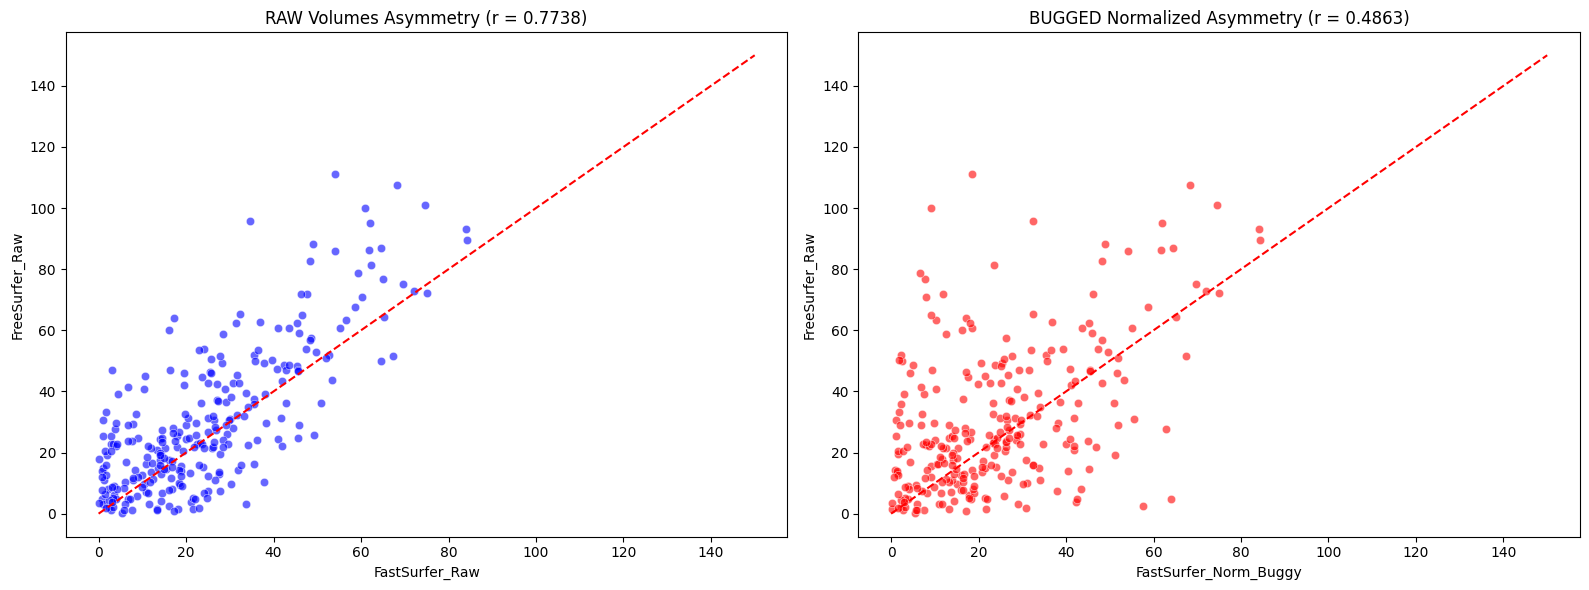

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Raw Asymmetry (from fs_shared and free_shared)
fs_asym_raw = (np.abs(fs_shared['Left-Inf-Lat-Vent'] - fs_shared['Right-Inf-Lat-Vent']) /
               ((fs_shared['Left-Inf-Lat-Vent'] + fs_shared['Right-Inf-Lat-Vent']) / 2)) * 100

free_asym_raw = (np.abs(free_shared['Left_Inf_Lat_Vent'] - free_shared['Right_Inf_Lat_Vent']) /
                 ((free_shared['Left_Inf_Lat_Vent'] + free_shared['Right_Inf_Lat_Vent']) / 2)) * 100

# 2. Reconstruct the "bugged" FastSurfer Normalized Asymmetry
# Note: This is bugged because the index on df_left_norm was not reset when row 182427 was dropped
bl_indices = fs_data[fs_data['EVENT_ID'] == 'BL'].index
fs_asym_norm_buggy = (np.abs(df_left_norm.loc[bl_indices, 'Inf-Lat-Vent'] -
                            df_right_norm.loc[bl_indices, 'Inf-Lat-Vent']) /
                     ((df_left_norm.loc[bl_indices, 'Inf-Lat-Vent'] +
                       df_right_norm.loc[bl_indices, 'Inf-Lat-Vent']) / 2)) * 100

# Align with PATNOs for comparison
fs_asym_norm_buggy.index = fs_data.loc[bl_indices, 'PATNO']

# 3. Create comparison dataframe
df_compare = pd.DataFrame({
    'FastSurfer_Raw': fs_asym_raw,
    'FastSurfer_Norm_Buggy': fs_asym_norm_buggy,
    'FreeSurfer_Raw': free_asym_raw
}).dropna()

print(f"Subjects in comparison: {len(df_compare)}")

# Plotting the paradox
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_compare, x='FastSurfer_Raw', y='FreeSurfer_Raw', ax=axes[0], color='blue', alpha=0.6)
axes[0].plot([0, 150], [0, 150], 'r--')
axes[0].set_title(f"RAW Volumes Asymmetry (r = {df_compare['FastSurfer_Raw'].corr(df_compare['FreeSurfer_Raw']):.4f})")

sns.scatterplot(data=df_compare, x='FastSurfer_Norm_Buggy', y='FreeSurfer_Raw', ax=axes[1], color='red', alpha=0.6)
axes[1].plot([0, 150], [0, 150], 'r--')
axes[1].set_title(f"BUGGED Normalized Asymmetry (r = {df_compare['FastSurfer_Norm_Buggy'].corr(df_compare['FreeSurfer_Raw']):.4f})")

plt.tight_layout()
plt.show()

Correlation between Fixed Norm and Raw: 1.000000


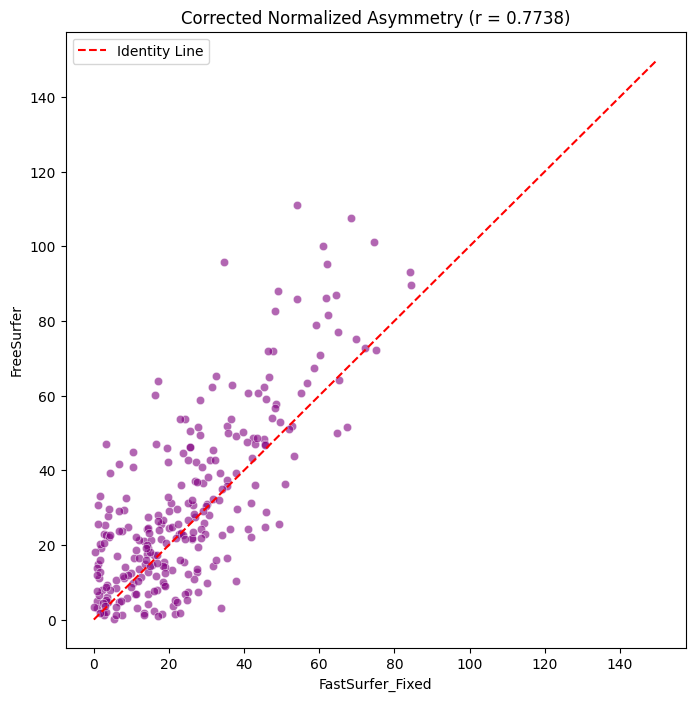

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-normalize properly using the updated dataframes (which now have aligned indices)
regions = [col for col in df_left_clean.columns if col not in base_cols]
df_left_norm = df_left_clean[regions].div(fs_data['MaskVol'], axis=0)
df_right_norm = df_right_clean[regions].div(fs_data['MaskVol'], axis=0)

# Calculate Fixed Asymmetry
bl_mask = fs_data['EVENT_ID'] == 'BL'
fs_asym_fixed = (np.abs(df_left_norm.loc[bl_mask, 'Inf-Lat-Vent'] -
                       df_right_norm.loc[bl_mask, 'Inf-Lat-Vent']) /
                ((df_left_norm.loc[bl_mask, 'Inf-Lat-Vent'] +
                  df_right_norm.loc[bl_mask, 'Inf-Lat-Vent']) / 2)) * 100

# Map back to PATNOs
fs_asym_fixed.index = fs_data.loc[bl_mask, 'PATNO']

# Sanity Check
print(f"Correlation between Fixed Norm and Raw: {fs_asym_fixed.corr(fs_asym_raw):.6f}")

# Comparison with FreeSurfer
df_plot = pd.DataFrame({
    'FastSurfer_Fixed': fs_asym_fixed,
    'FreeSurfer': free_asym_raw
}).dropna()

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_plot, x='FastSurfer_Fixed', y='FreeSurfer', color='purple', alpha=0.6)
plt.plot([0, 150], [0, 150], 'r--', label='Identity Line')
plt.title(f"Corrected Normalized Asymmetry (r = {df_plot['FastSurfer_Fixed'].corr(df_plot['FreeSurfer']):.4f})")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

print("--- 1. Loading and Filtering Data ---")
# 1. Get FreeSurfer Raw Baseline Data
fs_vol_raw = df_vol_raw_bl.copy().set_index('PATNO')

# 2. Get FastSurfer Raw Baseline Data
fast_base = fs_base.copy().set_index('PATNO')

# Filter to only include patients in df_pd_final
pd_final_patnos = df_pd_final['PATNO'].unique()
print(f"Initial FreeSurfer scans in PD cohort: {fs_vol_raw.index.isin(pd_final_patnos).sum()}")
print(f"Initial FastSurfer scans in PD cohort: {fast_base.index.isin(pd_final_patnos).sum()}")

fs_vol_raw = fs_vol_raw[fs_vol_raw.index.isin(pd_final_patnos)]
fast_base = fast_base[fast_base.index.isin(pd_final_patnos)]

# Exclude MRIQC Outliers
mriqc_outliers = [3403, 157589]
print(f"\nExcluding MRIQC Outliers: {mriqc_outliers}")
fs_outliers_found = [x for x in mriqc_outliers if x in fs_vol_raw.index]
fast_outliers_found = [x for x in mriqc_outliers if x in fast_base.index]

if fs_outliers_found:
    print(f"  -> Dropping {fs_outliers_found} from FreeSurfer")
    fs_vol_raw = fs_vol_raw.drop(index=fs_outliers_found)
if fast_outliers_found:
    print(f"  -> Dropping {fast_outliers_found} from FastSurfer")
    fast_base = fast_base.drop(index=fast_outliers_found)

# 4. Define Exclusion Rules
def is_excluded(col_name):
    col_lower = col_name.lower()
    if 'ctx-' in col_lower or 'cortex' in col_lower or 'cortical' in col_lower: return True
    if 'cc_' in col_lower: return True

    # Exclude hemispheric white matter to avoid duplicates/NaNs with global CerebralWhiteMatterVol
    if col_lower in ['left-cerebral-white-matter', 'right-cerebral-white-matter',
                     'lhcerebralwhitemattervol', 'rhcerebralwhitemattervol']:
        return True

    # Exclude additional globals requested by user
    if col_lower in ['brainsegvolnotvent', 'supratentorialvol', 'supratentorialvolnotvent', 'brainsegvol', 'optic_chiasm', 'optic-chiasm', 'totalgrayvol']:
        return True

    # Exclude lateralized hypointensities (use global), non_WM_hypointensities, 5th_Ventricle, and vessel
    if col_lower in ['left_wm_hypointensities', 'right_wm_hypointensities',
                     'left-wm-hypointensities', 'right-wm-hypointensities',
                     'left_non_wm_hypointensities', 'right_non_wm_hypointensities',
                     'left-non-wm-hypointensities', 'right-non-wm-hypointensities',
                     'non_wm_hypointensities', 'non-wm-hypointensities',
                     '5th_ventricle', '5th-ventricle',
                     'left_vessel', 'right_vessel', 'vessel',
                     'left-vessel', 'right-vessel']:
        return True

    # MaskVol removed from exclusion list so it's kept as a raw predictor column
    if col_name in ['EVENT_ID', 'Study_Date', 'Image_Description', 'MaskVol_to_eTIV', 'EstimatedTotalIntraCranialVol', 'BrainSegVol_to_eTIV', 'lhSurfaceHoles', 'rhSurfaceHoles', 'SurfaceHoles']:
        return True
    return False

print("\n--- 2. Extracting and Mapping Columns ---")
# 5. Extract FreeSurfer Columns
free_cols = [c for c in fs_vol_raw.columns if not is_excluded(c)]
df_free = fs_vol_raw[free_cols].copy()

# 6. Extract and Map FastSurfer Columns
fast_cols = [c for c in fast_base.columns if not is_excluded(c)]
df_fast = fast_base[fast_cols].copy()
# FastSurfer uses '-' instead of '_'. Rename to match FreeSurfer columns.
df_fast.columns = [c.replace('-', '_') for c in df_fast.columns]

print(f"FreeSurfer columns retained: {len(df_free.columns)}")
print(f"FastSurfer columns retained: {len(df_fast.columns)}")

# 7. Combine them
# combine_first uses df_free values where available, and fills missing rows/cols with df_fast
df_combined = df_free.combine_first(df_fast)
print(f"Combined dataframe shape: {df_combined.shape}")

# Keeping values un-normalized as requested
df_combined_unnorm = df_combined.copy()

# Keep track of source method before averaging
method_series = pd.Series('FastSurfer', index=df_combined_unnorm.index)
method_series[method_series.index.isin(df_free.index)] = 'FreeSurfer'

# --- SAVE UNAVERAGED DATAFRAME ---
output_path_unaveraged = '/content/raw_unaveraged_volumes.csv'
df_combined_unnorm.to_csv(output_path_unaveraged)
print(f"\nUnaveraged raw dataframe successfully exported to: {output_path_unaveraged}")


print("\n--- 3. Left-Right Averaging ---")
# 9. Left-Right Averaging
final_cols = {}
col_names = df_combined_unnorm.columns

# Standardize names to find Left/Right pairs
mapped_to_orig = {}
for c in col_names:
    std_name = c.replace('-', '_').replace('lh', 'Left_').replace('rh', 'Right_')
    mapped_to_orig[std_name] = c

std_names = list(mapped_to_orig.keys())
left_regions = [c.replace('Left_', '') for c in std_names if c.startswith('Left_')]
right_regions = [c.replace('Right_', '') for c in std_names if c.startswith('Right_')]

paired_regions = set(left_regions).intersection(set(right_regions))

df_final = pd.DataFrame(index=df_combined_unnorm.index)

for region in paired_regions:
    left_col = mapped_to_orig.get(f'Left_{region}')
    right_col = mapped_to_orig.get(f'Right_{region}')

    if left_col and right_col:
        df_final[region] = (df_combined_unnorm[left_col] + df_combined_unnorm[right_col]) / 2

# Add unpaired regions (globals, central structures, and MaskVol)
unpaired = [c for c in std_names if not c.startswith('Left_') and not c.startswith('Right_') and c.replace('Left_', '') not in paired_regions and c.replace('Right_', '') not in paired_regions]
for region in unpaired:
    orig_col = mapped_to_orig.get(region)
    if orig_col:
        df_final[region] = df_combined_unnorm[orig_col]

print(f"Paired regions averaged: {len(paired_regions)}")
print(f"Unpaired regions kept: {len(unpaired)} (Includes: {', '.join(unpaired)})")

# Determine source method (prioritizing FreeSurfer for overlapping patients)
df_final['Method'] = method_series

print("\n--- Scans Brought Into Final Dataset ---")
print(df_final['Method'].value_counts())
df_final = df_final.drop(columns=['Method'])

# 10. Export Averaged CSV
output_path_averaged = '/content/raw_averaged_volumes.csv'
df_final.to_csv(output_path_averaged)
print(f"\nAveraged raw dataframe successfully exported to: {output_path_averaged}")
display(df_final.head())


In [ ]:
print(df_pd_final.groupby('subgroup')['PATNO'].nunique())

subgroup
GBA             17
LRRK2           15
PRKN            13
SNCA             2
Sporadic PD    808
Name: PATNO, dtype: int64


Descriptive statistics for UPSIT (N = 834 subjects at baseline):


,upsit
count,834.000000
mean,22.011990
std,7.883902
min,1.000000
25%,16.000000
50%,22.000000
75%,28.000000
max,40.000000


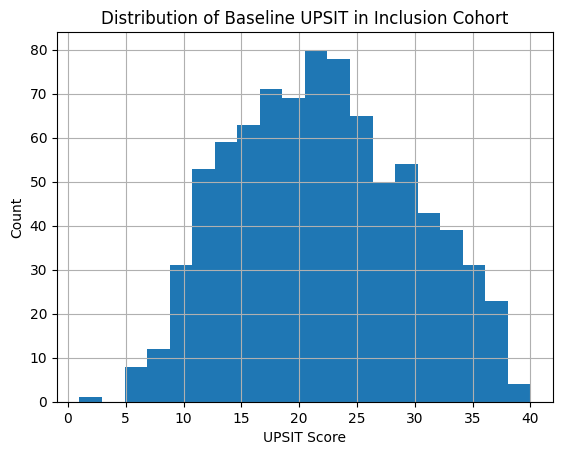

In [ ]:
# 1. Identify baseline data for the inclusion cohort (df_pd_final)
# 2. Extract 'upsit' from df_biomarkers (which contains the biomarker columns)

pd_final_ids = df_pd_final['PATNO'].unique()

df_upsit_stats = df_biomarkers[
    (df_biomarkers['PATNO'].isin(pd_final_ids)) &
    (df_biomarkers['YEAR'] == 0) &
    (df_biomarkers['upsit'].notna())
].copy()

print(f"Descriptive statistics for UPSIT (N = {df_upsit_stats['PATNO'].nunique()} subjects at baseline):")
display(df_upsit_stats['upsit'].describe())

# Optional: Histogram to see the distribution
import matplotlib.pyplot as plt
df_upsit_stats['upsit'].hist(bins=20)
plt.title("Distribution of Baseline UPSIT in Inclusion Cohort")
plt.xlabel("UPSIT Score")
plt.ylabel("Count")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Define Filter Criteria
# Combining gap outliers and the user-specified technical outliers
technical_outliers = [3403, 58327, 157589]
gap_outliers = [3290, 135121, 140041]
all_exclude_patnos = list(set(technical_outliers + gap_outliers))
inclusion_patnos = df_pd_final['PATNO'].unique()

# 2. Process Volumes using existing df_vol_both
# Filtering for inclusion cohort and excluding all identified outliers
df_vol_integrated = df_vol_both[
    (df_vol_both['PATNO'].isin(inclusion_patnos)) &
    (~df_vol_both['PATNO'].isin(all_exclude_patnos))
].copy()

# Remove sparse/unreliable columns as requested
sparse_vol_cols = ['5th_Ventricle', 'non_WM_hypointensities']
df_vol_integrated = df_vol_integrated.drop(columns=[c for c in sparse_vol_cols if c in df_vol_integrated.columns])

# Rename remaining columns to signify they are volumes
vol_regions = [c for c in df_vol_integrated.columns if c not in ['PATNO']]
rename_vols = {c: f'{c}_vol' for c in vol_regions}
df_vol_integrated = df_vol_integrated.rename(columns=rename_vols)

# 3. Process Thicknesses by averaging the already-normalized LH and RH dataframes
cth_regions = [c for c in df_CTh_lh.columns if c not in ['PATNO', 'MeanThickness']]

# Calculate average and add suffix
df_cth_avg = pd.DataFrame({'PATNO': df_CTh_lh['PATNO']})
for region in cth_regions:
    df_cth_avg[f'{region}_cth'] = (df_CTh_lh[region] + df_CTh_rh[region]) / 2

# Filter for inclusion cohort and outliers
df_cth_integrated = df_cth_avg[
    (df_cth_avg['PATNO'].isin(inclusion_patnos)) &
    (~df_cth_avg['PATNO'].isin(all_exclude_patnos))
].copy()

# 4. Merge and Export
df_mri_integrated = df_vol_integrated.merge(df_cth_integrated, on='PATNO', how='inner')

output_file = 'mri_vol_and_cth_norm_averaged.csv'
df_mri_integrated.to_csv(output_file, index=False)

print(f"Refined integrated dataframe created with {len(df_mri_integrated)} subjects.")
print(f"Outliers excluded: {all_exclude_patnos}")
print(f"Total regional measures: {len(df_mri_integrated.columns) - 1}")
display(df_mri_integrated.head())

In [ ]:
import pandas as pd
import rpy2.robjects as ro

# 1. Load the baseline 3-class linear model directly (no permutation)
model_path = '/content/drive/MyDrive/data/m3_rmus_intercept_z_bl_trans_linear.rds'
ro.r(f'm3_orig <- readRDS("{model_path}")')

# 2. Get posterior probabilities/class assignments
with (ro.default_converter + ro.pandas2ri.converter).context():
    pprob_df = ro.conversion.get_conversion().rpy2py(ro.r("m3_orig$pprob"))

# 3. Extract CSFSAA (baseline YEAR 0) from curated data
df_saa = df_curated[df_curated['YEAR'] == 0][['PATNO', 'CSFSAA']].drop_duplicates('PATNO').copy()
df_saa['PATNO'] = df_saa['PATNO'].astype(int)
pprob_df['PATNO'] = pprob_df['PATNO'].astype(int)

# 4. Merge assignments with biomarker data
df_class_saa_orig = pprob_df.merge(df_saa, on='PATNO', how='left')

# 5. Generate frequency table
# Raw numeric codes: 0 (Negative), 1 (Positive), 2 (Indeterminate), 3 (Unknown/Missing)
print("--- CSF-SAA Distribution per Original Latent Class (No Permutation) ---")
saa_freq_table_orig = pd.crosstab(
    df_class_saa_orig['class'],
    df_class_saa_orig['CSFSAA'],
    margins=True,
    dropna=False
)

display(saa_freq_table_orig)

# Linear Link Model with z-scored class indicator variables (early version)

In [ ]:
model_path = "/content/drive/MyDrive/data/m3_rmus_intercept_z_bl_trans_linear.rds"

ro.r(f'm3_rmus_intercept_z_bl_trans_linear <- readRDS("{model_path}")')

m3_rmus_intercept_z_bl_trans_linear = ro.globalenv['m3_rmus_intercept_z_bl_trans_linear']

In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
vars_to_z = ["rem", "trans_moca", "updrs3_score", "delta_sbp"]

base = df_pd_final[df_pd_final["YEAR"] == 0]

mu_base = base[vars_to_z].mean()
sd_base = base[vars_to_z].std()

df_pd_final[["z_bl_" + v for v in vars_to_z]] = (df_pd_final[vars_to_z] - mu_base) / sd_base

In [ ]:
df_pd_final.filter(like="z_bl_").describe()

,z_bl_rem,z_bl_trans_moca,z_bl_updrs3_score,z_bl_delta_sbp
count,3379.000000,3372.000000,2864.000000,3307.000000
mean,0.103496,0.055209,0.411544,0.057693
std,1.050013,1.141820,1.186819,1.073331
min,-1.390360,-1.688101,-2.077751,-4.249612
25%,-0.712310,-0.982341,-0.442863,-0.566941
50%,-0.034261,0.015755,0.272401,-0.018458
75%,0.982813,0.781621,1.192026,0.608380
max,3.016961,5.783589,4.666165,8.365496


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r('''
library(lcmm)
m3_rmus_intercept_z_bl_trans_linear_ref2 = permut(m3_rmus_intercept_z_bl_trans_linear, c(1, 3, 2))
postprob(m3_rmus_intercept_z_bl_trans_linear_ref2)
''')

 
Posterior classification: 
  class1 class2 class3
N 173.00 114.00 568.00
%  20.23  13.33  66.43
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2  prob3
class1 0.8684 0.0917 0.0400
class2 0.0894 0.7868 0.1238
class3 0.0080 0.0699 0.9221
 
Posterior probaBIlities above a threshold (%): 
         class1 class2 class3
prob>0.7  83.24  69.30  92.25
prob>0.8  75.72  54.39  85.92
prob>0.9  61.27  39.47  74.82
 


In [ ]:
import rpy2.robjects as ro

# 1. Define Predictors
ni_preds = ["SEX", "EDUCYRS", "age", "asyn_bl", "ptau_bl", "abeta_bl", "upsit_bl", "nfl_serum_bl", "MIA_CAUDATE_BILAT_bl", "MIA_PUTAMEN_BILAT_bl", "APOE_e4_bl"]
img_preds = ["SEX", "EDUCYRS", "age", "Thalamus_fs_bl", "Caudate_fs_bl", "Putamen_fs_bl", "Hippocampus_fs_bl", "choroid_plexus_fs_bl", "Pallidum_fs_bl", "Lateral_Ventricle_fs_bl", "Inf_Lat_Vent_fs_bl", "WM_hypointensities_fs_bl", "CerebralWhiteMatterVol_fs_bl"]

# 2. Prepare Shared Components
df_bl_bio = df_overlap.rename(columns={c: f'{c}_bl' for c in df_overlap.columns if c not in ['PATNO', 'EVENT_ID', 'YEAR']})[['PATNO'] + [f'{c}_bl' for c in biomarker_cols]].drop_duplicates('PATNO')
df_ext = df_pd_final.merge(df_bl_bio, on='PATNO', how='left')

# 2.1 Reconstruct MRI features (df_fs_combined)
fs_regions = ["Thalamus", "Caudate", "Putamen", "Hippocampus", "choroid_plexus", "Pallidum", "Lateral_Ventricle", "Inf_Lat_Vent"]
fs_globals = ["WM_hypointensities", "non_WM_hypointensities", "CerebralWhiteMatterVol", "SubCortGrayVol"]
df_fs_baseline = df_vol_both[["PATNO"] + fs_regions].copy()
df_globals = df_vol[["PATNO"] + fs_globals].copy()
df_fs_combined = df_fs_baseline.merge(df_globals, on="PATNO", how="left")
rename_dict = {col: f"{col}_fs_bl" for col in (fs_regions + fs_globals)}
df_fs_combined = df_fs_combined.rename(columns=rename_dict)

# 3. Non-Imaging Raw Dataframe (N=240)
df_ni_full_raw = df_ext.dropna(subset=ni_preds).copy()

# Apply targeted scaling to Non-Imaging predictors to stabilize the Hessian
df_ni_full_raw['asyn_bl'] = df_ni_full_raw['asyn_bl'] / 100.0
df_ni_full_raw['abeta_bl'] = df_ni_full_raw['abeta_bl'] / 100.0
df_ni_full_raw['MIA_CAUDATE_BILAT_bl'] = df_ni_full_raw['MIA_CAUDATE_BILAT_bl'] * 10.0
df_ni_full_raw['MIA_PUTAMEN_BILAT_bl'] = df_ni_full_raw['MIA_PUTAMEN_BILAT_bl'] * 10.0

# 4. Imaging Raw Dataframe (N=474)
mri_ids = set(df_pd_final['PATNO']) & set(df_vol['PATNO']) - {3403, 157589}
df_img_full_raw = df_pd_final[df_pd_final['PATNO'].isin(mri_ids)].merge(df_fs_combined, on='PATNO', how='left').dropna(subset=img_preds).copy()

# Targeted scaling for Imaging to balance SDs
df_img_full_raw['CerebralWhiteMatterVol_fs_bl'] *= 100.0
df_img_full_raw['WM_hypointensities_fs_bl'] *= 1000.0
df_img_full_raw['Lateral_Ventricle_fs_bl'] *= 1000.0

# Everything else by 10,000
other_fs_cols = [c for c in img_preds if '_fs_bl' in c and c not in ['CerebralWhiteMatterVol_fs_bl', 'WM_hypointensities_fs_bl', 'Lateral_Ventricle_fs_bl']]
df_img_full_raw[other_fs_cols] *= 10000.0

# 5. Push to R and Configure Factors
ro.globalenv['df_ni_full_raw'] = df_ni_full_raw
ro.globalenv['df_img_full_raw'] = df_img_full_raw
ro.r("""
library(lcmm)
setup_df <- function(d) {
  d$TP <- factor(d$YEAR)
  d$SEX <- factor(d$SEX)
  if('APOE_e4_bl' %in% names(d)) d$APOE_e4_bl <- factor(d$APOE_e4_bl)
  return(d)
}
df_ni_full_raw <- setup_df(df_ni_full_raw)
df_img_full_raw <- setup_df(df_img_full_raw)
""")

print(f"Data Prepared: Non-Imaging (N={df_ni_full_raw['PATNO'].nunique()}), Imaging (N={df_img_full_raw['PATNO'].nunique()})")

Data Prepared: Non-Imaging (N=240), Imaging (N=474)


In [ ]:
# 1. Consolidate APOE: 0 = non-carrier, 1 or 2 = carrier (mapped to 1)
df_ni_full_raw['APOE_e4_bl'] = df_ni_full_raw['APOE_e4_bl'].replace({2.0: 1.0})

# 2. Re-push the updated dataframe to R
ro.globalenv['df_ni_full_raw'] = df_ni_full_raw

# 3. Re-configure factors in R
ro.r("""
df_ni_full_raw$TP <- factor(df_ni_full_raw$YEAR)
df_ni_full_raw$SEX <- factor(df_ni_full_raw$SEX)
df_ni_full_raw$APOE_e4_bl <- factor(df_ni_full_raw$APOE_e4_bl)
""")

print("APOE consolidated in df_ni_full_raw (0 = Non-Carrier, 1 = Carrier):")
print(df_ni_full_raw['APOE_e4_bl'].value_counts().sort_index())

APOE consolidated in df_ni_full_raw (0 = Non-Carrier, 1 = Carrier):
APOE_e4_bl
0.0    982
1.0    318
Name: count, dtype: int64


In [ ]:
cols_to_add = ["PATNO", "EVENT_ID"] + ["z_bl_" + v for v in vars_to_z]
z_cols = ["z_bl_" + v for v in vars_to_z]

# Drop columns if they already exist to avoid MergeError on re-run
df_img_full_raw = df_img_full_raw.drop(columns=[c for c in z_cols if c in df_img_full_raw.columns])
df_ni_full_raw = df_ni_full_raw.drop(columns=[c for c in z_cols if c in df_ni_full_raw.columns])
df_upsit_full = df_upsit_full.drop(columns=[c for c in z_cols if c in df_upsit_full.columns])
df_dat_final = df_dat_final.drop(columns=[c for c in z_cols if c in df_dat_final.columns])

# Add to dataframes
df_img_full_raw = df_img_full_raw.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")
df_ni_full_raw = df_ni_full_raw.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")
df_upsit_full = df_upsit_full.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")
df_dat_final = df_dat_final.merge(df_pd_final[cols_to_add], on=["PATNO", "EVENT_ID"], how="left")

# Push all back to R
ro.globalenv['df_img_full_raw'] = df_img_full_raw
ro.globalenv['df_ni_full_raw'] = df_ni_full_raw
ro.globalenv['df_upsit_full'] = df_upsit_full
ro.globalenv['df_dat_final'] = df_dat_final

ro.r("""
setup_df_z <- function(d) {
  d$TP <- factor(d$YEAR)
  d$SEX <- factor(d$SEX)
  if('APOE_e4_bl' %in% names(d)) d$APOE_e4_bl <- factor(d$APOE_e4_bl)
  return(d)
}
df_img_full_raw <- setup_df_z(df_img_full_raw)
df_ni_full_raw <- setup_df_z(df_ni_full_raw)
df_upsit_full <- setup_df_z(df_upsit_full)
df_dat_final <- setup_df_z(df_dat_final)
""")

print(f"Successfully added/updated z-scored baseline variables in all cohorts.")

Successfully added/updated z-scored baseline variables in all cohorts.


In [ ]:
formula_img = " ~ " + " + ".join(img_preds)

print(f"--- Running Imaging externVar (Z-scored BL Linear Model, N={df_img_full_raw['PATNO'].nunique()}) ---")

ro.r(f"""
m3_img_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                         classmb = {formula_img},
                         subject = 'PATNO',
                         data = df_img_full_raw,
                         method = 'twoStageJoint',
                         maxiter = 100)

print(summary(m3_img_z_bl))
""")

--- Running Imaging externVar (Z-scored BL Linear Model, N=474) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + Thalamus_fs_bl + Caudate_fs_bl + 
        Putamen_fs_bl + Hippocampus_fs_bl + choroid_plexus_fs_bl + 
        Pallidum_fs_bl + Lateral_Ventricle_fs_bl + Inf_Lat_Vent_fs_bl + 
        WM_hypointensities_fs_bl + CerebralWhiteMatterVol_fs_bl, 
    data = df_img_full_raw, method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_img_full_raw 
     Number of subjects: 474 
     Number of latent classes: 3 
     Number of parameters: 28  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  29 
     Convergence criteria: parameters= 2.1e-06 
                         : l

In [ ]:
formula_ni = " ~ " + " + ".join(ni_preds)

print(f"--- Running Non-Imaging externVar (Z-scored BL Linear Model, N={df_ni_full_raw['PATNO'].nunique()}) ---")
ro.r(f"""
m3_ni_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                       classmb = {formula_ni},
                       subject = 'PATNO',
                       data = df_ni_full_raw,
                       method = 'twoStageJoint',
                       maxiter = 100)

print(summary(m3_ni_z_bl))
""")

--- Running Non-Imaging externVar (Z-scored BL Linear Model, N=474) ---


Exception ignored from cffi callback <function _processevents at 0x7f240e1c9620>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 


Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + asyn_bl + ptau_bl + abeta_bl + 
        upsit_bl + nfl_serum_bl + MIA_CAUDATE_BILAT_bl + MIA_PUTAMEN_BILAT_bl + 
        APOE_e4_bl, data = df_ni_full_raw, method = "twoStageJoint", 
    maxiter = 100)
 
Statistical Model: 
     Dataset: df_ni_full_raw 
     Number of subjects: 240 
     Number of latent classes: 3 
     Number of parameters: 24  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  20 
     Convergence criteria: parameters= 4.2e-08 
                         : likelihood= 4.1e-07 
                         : second derivatives= 5.5e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7039.43  
     AIC: 14126.87  
     BIC:

In [ ]:
upsit_preds = ["SEX", "EDUCYRS", "age", "upsit_bl"]
formula_upsit = " ~ " + " + ".join(upsit_preds)

print(f"--- Running UPSIT externVar (Z-scored BL Linear Model, N={df_upsit_full['PATNO'].nunique()}) ---")

ro.r(f"""

# Run the secondary regression using the permuted z-scored linear model
m3_upsit_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                          classmb = {formula_upsit},
                          subject = 'PATNO',
                          data = df_upsit_full,
                          method = 'twoStageJoint',
                          maxiter = 100)

print(summary(m3_upsit_z_bl))
""")

--- Running UPSIT externVar (Z-scored BL Linear Model, N=834) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + upsit_bl, data = df_upsit_full, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_upsit_full 
     Number of subjects: 834 
     Number of latent classes: 3 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 7.7e-05 
                         : likelihood= 2.3e-05 
                         : second derivatives= 1.2e-08 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -17876.73  
     AIC: 35773.45  
     BIC: 35820.72  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed ef

In [ ]:
formula_dat = " ~ SEX + EDUCYRS + age + MIA_CAUDATE_bl + MIA_PUTAMEN_bl"

print(f"--- Running DATscan externVar (Z-scored BL Linear Model, N={df_dat_final['PATNO'].nunique()}) ---")

ro.r(f"""
m3_dat_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                         classmb = {formula_dat},
                         subject = 'PATNO',
                         data = df_dat_final,
                         method = 'twoStageJoint',
                         maxiter = 100)

print(summary(m3_dat_z_bl))
""")

--- Running DATscan externVar (Z-scored BL Linear Model, N=846) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + MIA_CAUDATE_bl + MIA_PUTAMEN_bl, 
    data = df_dat_final, method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_dat_final 
     Number of subjects: 846 
     Number of latent classes: 3 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  24 
     Convergence criteria: parameters= 1.2e-08 
                         : likelihood= 6.4e-06 
                         : second derivatives= 1.7e-05 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18050.48  
     AIC: 36124.97  
     BIC: 36181.85  
 
 
 
Maximum Likelihoo

In [ ]:
# 1. Identify PATNOs with available asyn at baseline
asyn_patnos = df_biomarkers[(df_biomarkers['YEAR'] == 0) & (df_biomarkers['asyn'].notna())]['PATNO'].unique()

# 2. Filter the longitudinal PD cohort for these subjects
df_asyn_full = df_pd_final[df_pd_final['PATNO'].isin(asyn_patnos)].copy()

# 3. Merge baseline asyn values back in for use as a predictor
df_asyn_bl_values = df_biomarkers[df_biomarkers['YEAR'] == 0][['PATNO', 'asyn']].rename(columns={'asyn': 'asyn_bl'})
df_asyn_full = df_asyn_full.merge(df_asyn_bl_values, on='PATNO', how='left')

# 4. Filter for records where asyn_bl is available and add basic demo predictors
# (Mirroring the logic of your other dedicated dataframes)
demo_cols = ['SEX', 'EDUCYRS', 'age']
df_asyn_full = df_asyn_full.dropna(subset=['asyn_bl'] + demo_cols).copy()

# 5. Push to R environment
ro.globalenv['df_asyn_full'] = df_asyn_full
ro.r("""
library(lcmm)
df_asyn_full$TP <- factor(df_asyn_full$YEAR)
df_asyn_full$SEX <- factor(df_asyn_full$SEX)
""")

print(f"Created 'df_asyn_full' with {df_asyn_full['PATNO'].nunique()} subjects and {len(df_asyn_full)} total rows.")
display(df_asyn_full[['PATNO', 'YEAR', 'asyn_bl']].head())

In [ ]:
asyn_preds = ["SEX", "EDUCYRS", "age", "asyn_bl"]
formula_asyn = " ~ " + " + ".join(asyn_preds)

print(f"--- Running asyn externVar (Z-scored BL Linear Model, N={df_asyn_full['PATNO'].nunique()}) ---")

ro.r(f"""

df_asyn_full$SEX <- factor(df_asyn_full$SEX)

m3_asyn_z_bl = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                             classmb = {formula_asyn},
                             subject = 'PATNO',
                             data = df_asyn_full,
                             method = 'twoStageJoint',
                             maxiter = 100)

print(summary(m3_asyn_z_bl))
""")

--- Running asyn externVar (Z-scored BL Linear Model, N=305) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + asyn_bl, data = df_asyn_full, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_asyn_full 
     Number of subjects: 305 
     Number of latent classes: 3 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  8 
     Convergence criteria: parameters= 4.8e-05 
                         : likelihood= 7.2e-06 
                         : second derivatives= 3.8e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -8930.42  
     AIC: 17880.84  
     BIC: 17918.04  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed effects

# Linear Mixed Model for MRI Trajectories

## Plots

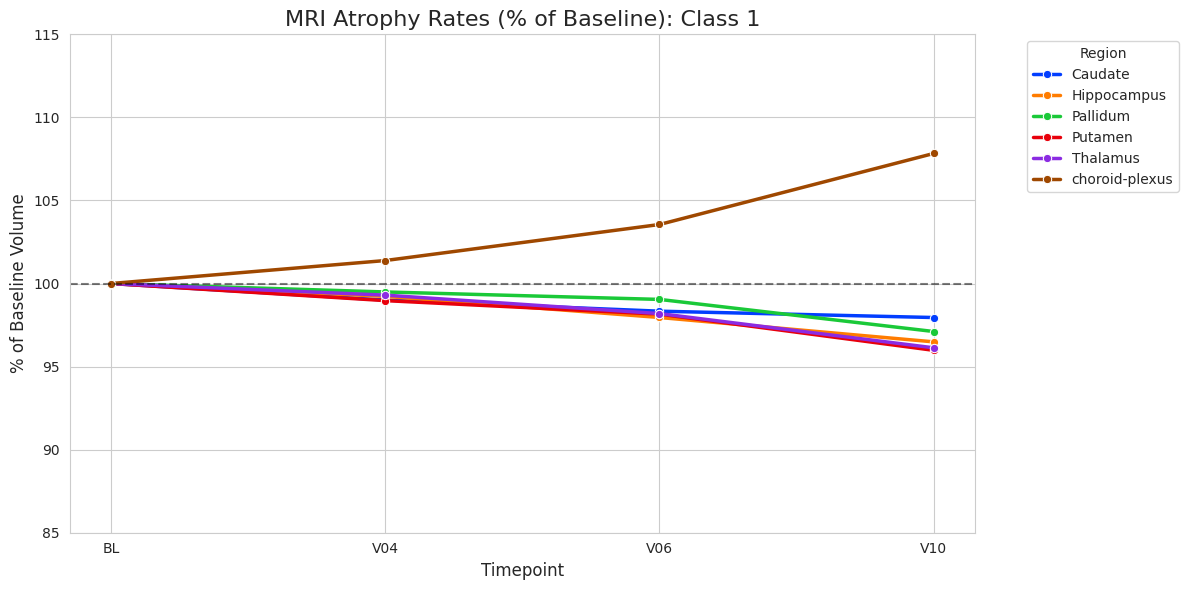

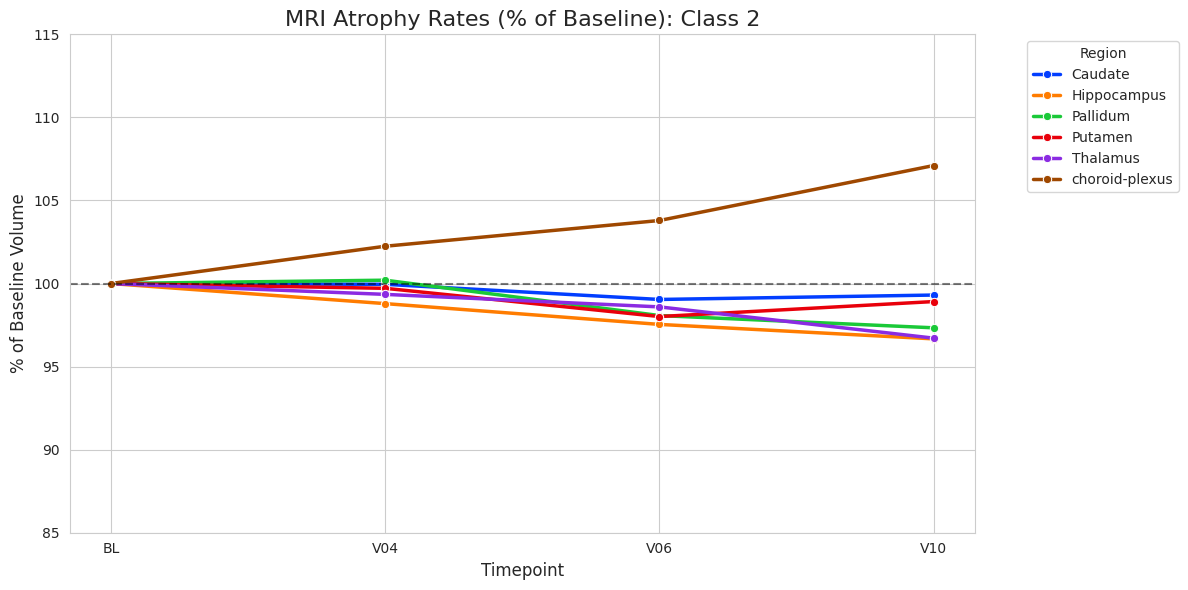

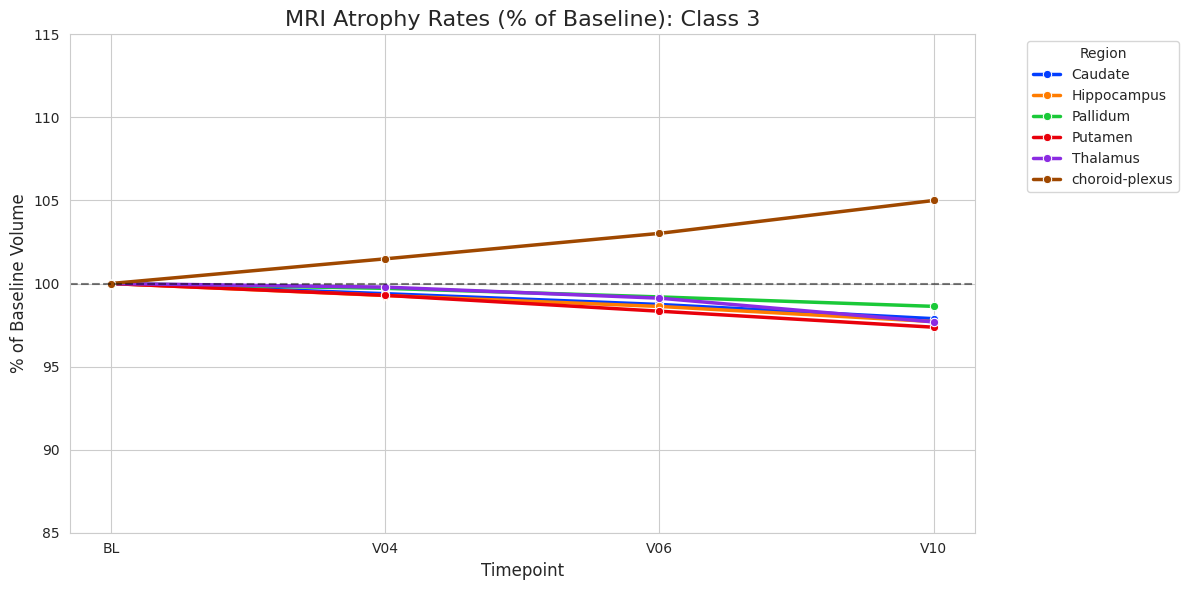

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load class assignments from the 3-class linear model (already in memory as pprob_df)
pp_m3 = pprob_df[['PATNO', 'class']].copy()
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

# 1.5 Create df_averaged for FastSurfer regions
target_regions = ['Thalamus', 'Caudate', 'Pallidum', 'Putamen', 'Hippocampus', 'choroid-plexus']
df_averaged = fs_data[['PATNO', 'EVENT_ID']].copy()
for r in target_regions:
    df_averaged[r] = (fs_data[f'Left-{r}'] + fs_data[f'Right-{r}']) / 2

# 2. Merge with averaged regional data
df_mri = df_averaged.merge(pp_m3, on='PATNO', how='inner')

# 3. Filter visits
timepoint_map = {'BL': 0, 'V04': 1, 'V06': 2, 'V10': 3}
df_mri = df_mri[df_mri['EVENT_ID'].isin(timepoint_map.keys())].copy()
df_mri['Visit_Order'] = df_mri['EVENT_ID'].map(timepoint_map)

# 4. Calculate % of Baseline Volume per subject
def calculate_pct_baseline(group):
    # Sort by visit order to ensure BL is identified correctly
    group = group.sort_values('Visit_Order')
    bl_row = group[group['EVENT_ID'] == 'BL']

    if not bl_row.empty:
        for region in target_regions:
            bl_vol = bl_row[region].values[0]
            if bl_vol > 0:
                group[f'{region}_pct'] = (group[region] / bl_vol) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in target_regions:
            group[f'{region}_pct'] = np.nan
    return group

df_pct = df_mri.groupby('PATNO', group_keys=False).apply(calculate_pct_baseline, include_groups=False)

# 5. Reshape for plotting
pct_vars = [f'{r}_pct' for r in target_regions]
df_long = df_pct.melt(id_vars=['class', 'Visit_Order', 'EVENT_ID'],
                           value_vars=pct_vars,
                           var_name='Region', value_name='Pct_Baseline')

# Clean region names for legend
df_long['Region'] = df_long['Region'].str.replace('_pct', '')

# 6. Calculate Class Averages
df_grouped = df_long.groupby(['class', 'Visit_Order', 'EVENT_ID', 'Region'])['Pct_Baseline'].mean().reset_index()

# 7. Plotting
sns.set_style("whitegrid")
classes = sorted(df_grouped['class'].unique())

for cls in classes:
    plt.figure(figsize=(12, 6))
    data_cls = df_grouped[df_grouped['class'] == cls]

    sns.lineplot(data=data_cls, x='Visit_Order', y='Pct_Baseline', hue='Region',
                 marker='o', palette='bright', linewidth=2.5)

    plt.title(f"MRI Atrophy Rates (% of Baseline): Class {int(cls)}", fontsize=16)
    plt.xticks(range(4), ['BL', 'V04', 'V06', 'V10'])
    plt.xlabel("Timepoint", fontsize=12)
    plt.ylabel("% of Baseline Volume", fontsize=12)
    plt.ylim(85, 115) # Centered around 100% to see gain/loss clearly
    plt.axhline(100, ls='--', color='black', alpha=0.5)
    plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


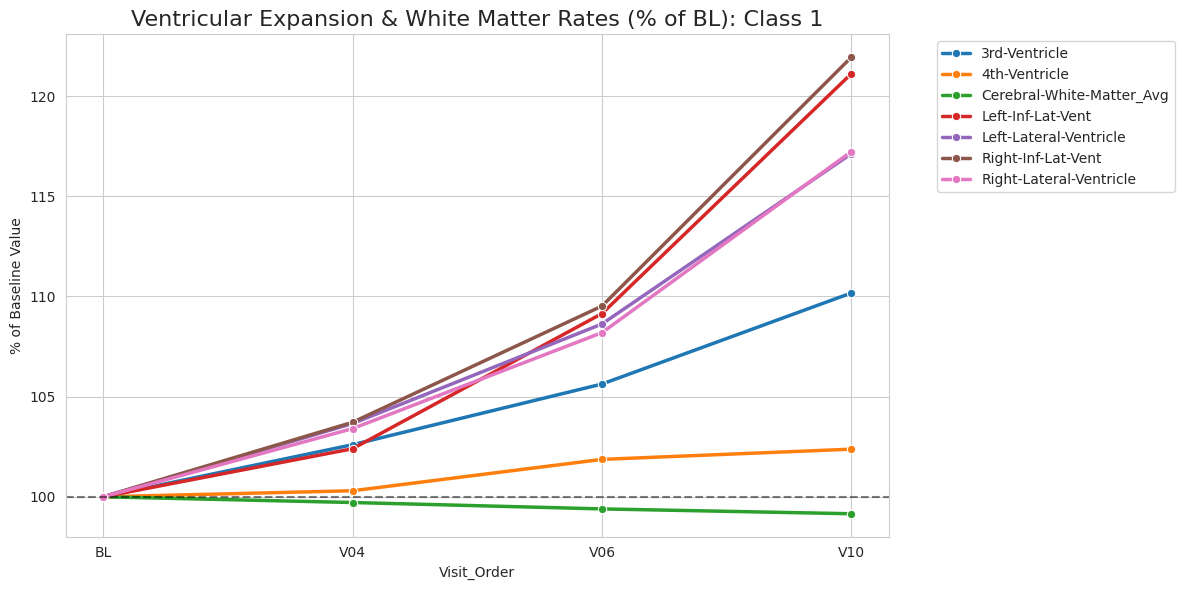

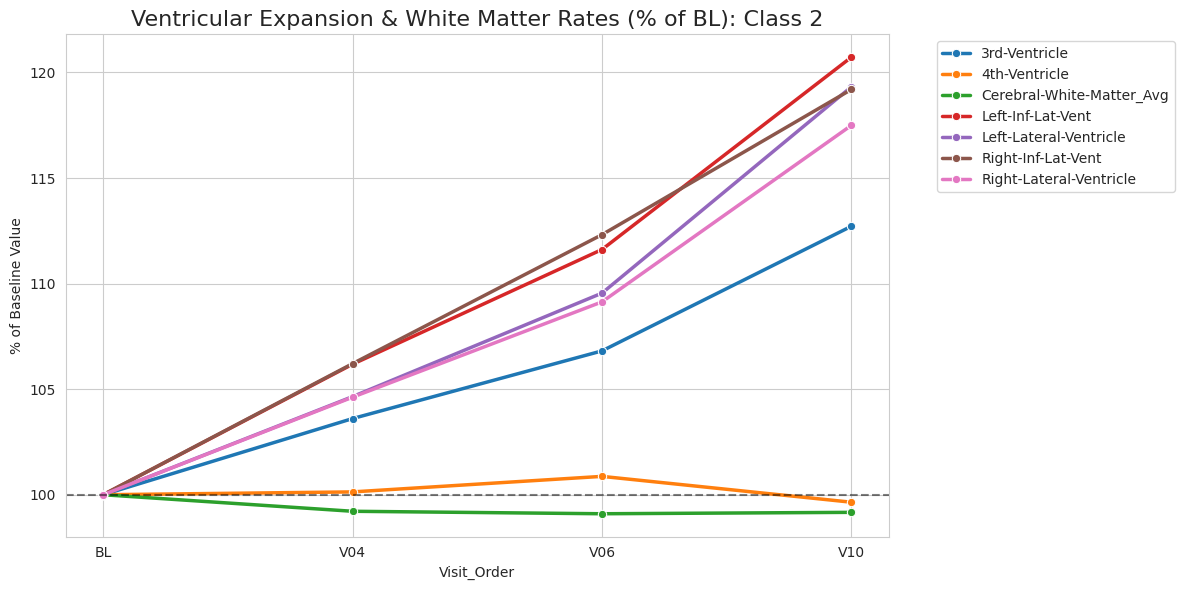

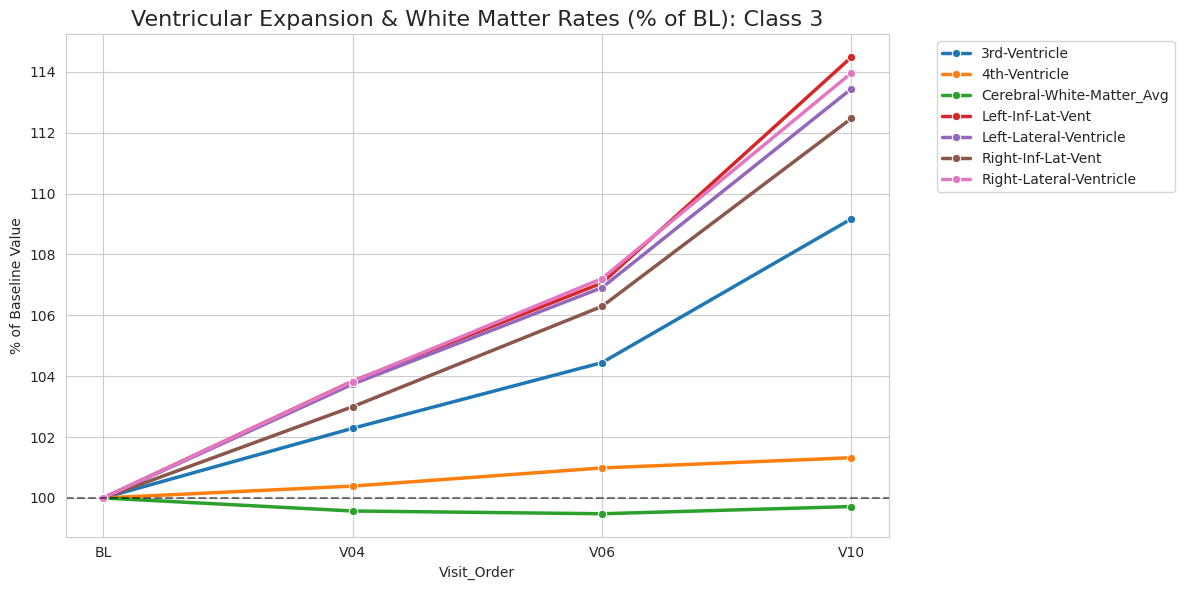

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the structure data (7 structures)
# Note: MaskVol is used for normalization as before
mask_vol = fs_data['MaskVol']

# Initialize dataframe with metadata
df_ventricles = fs_data[['PATNO', 'EVENT_ID', 'Study_Date', 'MaskVol']].copy()

# Add lateralized ventricles (Left and Right separately, not averaged)
df_ventricles['Left-Lateral-Ventricle'] = fs_data['Left-Lateral-Ventricle']
df_ventricles['Right-Lateral-Ventricle'] = fs_data['Right-Lateral-Ventricle']
df_ventricles['Left-Inf-Lat-Vent'] = fs_data['Left-Inf-Lat-Vent']
df_ventricles['Right-Inf-Lat-Vent'] = fs_data['Right-Inf-Lat-Vent']

# Add unlateralized ventricles (3rd and 4th)
df_ventricles['3rd-Ventricle'] = fs_data['3rd-Ventricle']
df_ventricles['4th-Ventricle'] = fs_data['4th-Ventricle']

# Add averaged Cerebral-White-Matter
df_ventricles['Cerebral-White-Matter_Avg'] = (fs_data['Left-Cerebral-White-Matter'] + fs_data['Right-Cerebral-White-Matter']) / 2

# 2. Normalize all structures by MaskVol
ventricle_structs = ['Left-Lateral-Ventricle', 'Right-Lateral-Ventricle', 'Left-Inf-Lat-Vent', 'Right-Inf-Lat-Vent', '3rd-Ventricle', '4th-Ventricle', 'Cerebral-White-Matter_Avg']
for col in ventricle_structs:
    df_ventricles[col] = df_ventricles[col] / df_ventricles['MaskVol']

# 3. Merge with class assignments
pp_m3 = pprob_df[['PATNO', 'class']].copy()
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)
df_vent_plot = df_ventricles.merge(pp_m3, on='PATNO', how='inner')

# 4. Filter visits and map order
timepoint_map = {'BL': 0, 'V04': 1, 'V06': 2, 'V10': 3}
df_vent_plot = df_vent_plot[df_vent_plot['EVENT_ID'].isin(timepoint_map.keys())].copy()
df_vent_plot['Visit_Order'] = df_vent_plot['EVENT_ID'].map(timepoint_map)

# 5. Calculate % of Baseline per subject
def calculate_pct_baseline_vent(group):
    group = group.sort_values('Visit_Order')
    bl_row = group[group['EVENT_ID'] == 'BL']
    if not bl_row.empty:
        for region in ventricle_structs:
            bl_val = bl_row[region].values[0]
            if bl_val > 0:
                group[f'{region}_pct'] = (group[region] / bl_val) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in ventricle_structs:
            group[f'{region}_pct'] = np.nan
    return group

df_vent_pct = df_vent_plot.groupby('PATNO', group_keys=False).apply(calculate_pct_baseline_vent, include_groups=False)

# 6. Reshape and Plot averages
pct_cols = [f'{r}_pct' for r in ventricle_structs]
df_long_vent = df_vent_pct.melt(id_vars=['class', 'Visit_Order', 'EVENT_ID'],
                               value_vars=pct_cols,
                               var_name='Structure', value_name='Pct_Baseline')

# Clean names for legend
df_long_vent['Structure'] = df_long_vent['Structure'].str.replace('_pct', '')

df_grouped_vent = df_long_vent.groupby(['class', 'Visit_Order', 'EVENT_ID', 'Structure'])['Pct_Baseline'].mean().reset_index()

sns.set_style("whitegrid")
classes = sorted(df_grouped_vent['class'].unique())

for cls in classes:
    plt.figure(figsize=(12, 6))
    data_cls = df_grouped_vent[df_grouped_vent['class'] == cls]
    sns.lineplot(data=data_cls, x='Visit_Order', y='Pct_Baseline', hue='Structure',
                 marker='o', palette='tab10', linewidth=2.5)
    plt.title(f"Ventricular Expansion & White Matter Rates (% of BL): Class {int(cls)}", fontsize=16)
    plt.xticks(range(4), ['BL', 'V04', 'V06', 'V10'])
    plt.axhline(100, ls='--', color='black', alpha=0.5)
    plt.ylabel("% of Baseline Value")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
# Calculate attrition: Number of unique patients per class at each timepoint
attrition_table = df_mri.groupby(['class', 'EVENT_ID'])['PATNO'].nunique().unstack()

# Reorder columns to match the timeline
attrition_table = attrition_table[['BL', 'V04', 'V06', 'V10']]

print("Number of patients with FastSurfer data at each timepoint, by class:")
display(attrition_table)


Number of patients with FastSurfer data at each timepoint, by class:


EVENT_ID,BL,V04,V06,V10
class,,,,
1,78,76,39,15
2,52,48,39,9
3,245,235,143,51


## Final LMMs

In [ ]:
import rpy2.robjects as ro
import pandas as pd
import numpy as np

# 1. Get class assignments from the permuted z-scored linear model
# (Using the _ref2 version so Class 3, the largest, is our reference)
with (ro.default_converter + ro.pandas2ri.converter).context():
    pprob_df = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

df_classes = pprob_df[['PATNO', 'class']].copy()
df_classes['PATNO'] = df_classes['PATNO'].astype(int)

# 2. Extract RAW longitudinal volumes from fs_data and NORMALIZE by MaskVol
lateralized_regions = [
    ('Thalamus', 'Thalamus'),
    ('Caudate', 'Caudate'),
    ('Putamen', 'Putamen'),
    ('Hippocampus', 'Hippocampus'),
    ('choroid-plexus', 'choroid_plexus'),
    ('Pallidum', 'Pallidum'),
    ('Lateral-Ventricle', 'Lateral_Ventricle'),
    ('Inf-Lat-Vent', 'Inf_Lat_Vent'),
    ('Cerebral-White-Matter', 'Cerebral_White_Matter')
]

df_mri_norm = fs_data[['PATNO', 'EVENT_ID']].copy()

for fs_name, clean_name in lateralized_regions:
    avg_vol = (fs_data[f'Left-{fs_name}'] + fs_data[f'Right-{fs_name}']) / 2
    df_mri_norm[clean_name] = avg_vol / fs_data['MaskVol']

if 'WM-hypointensities' in fs_data.columns:
    df_mri_norm['WM_hypointensities'] = fs_data['WM-hypointensities'] / fs_data['MaskVol']

# 3. Add YEAR and baseline age/sex
df_years = df_pd_final[['PATNO', 'EVENT_ID', 'YEAR']].drop_duplicates()

# ---- MANUAL ADDITION OF MISSING SCANS ----
missing_years = pd.DataFrame([
    {'PATNO': 101070, 'EVENT_ID': 'V06', 'YEAR': 2.0},
    {'PATNO': 140671, 'EVENT_ID': 'V02', 'YEAR': 0.5},
    {'PATNO': 182927, 'EVENT_ID': 'V02', 'YEAR': 0.5},
    {'PATNO': 184507, 'EVENT_ID': 'V02', 'YEAR': 0.5}
])
df_years = pd.concat([df_years, missing_years], ignore_index=True)
# ------------------------------------------

df_bl_demo = df_pd_final[df_pd_final['YEAR'] == 0][['PATNO', 'age', 'SEX']].drop_duplicates()
df_bl_demo = df_bl_demo.rename(columns={'age': 'age_bl', 'SEX': 'sex'})

df_mri_norm = df_mri_norm.merge(df_classes, on='PATNO', how='inner')
df_mri_norm = df_mri_norm.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')
df_mri_norm = df_mri_norm.merge(df_bl_demo, on='PATNO', how='left')

# Drop rows missing necessary covariates
df_mri_norm = df_mri_norm.dropna(subset=['YEAR', 'age_bl', 'sex'])

# Scale volumes by 10,000 for LMM numerical stability
mri_cols = [clean_name for _, clean_name in lateralized_regions]
if 'WM_hypointensities' in df_mri_norm.columns:
    mri_cols.append('WM_hypointensities')
df_mri_norm[mri_cols] = df_mri_norm[mri_cols] * 10000

# Push to R (Keeping the name df_lmm_raw in R to avoid changing all the hlme cells)
ro.globalenv['df_lmm_raw'] = df_mri_norm

# 4. Debug Checks
print("--- Data Preparation Summary ---")
print(f"Total scans available for LMM: {len(df_mri_norm)}")
print(f"Unique patients: {df_mri_norm['PATNO'].nunique()}")

is_182427_bl_excluded = not ((df_mri_norm['PATNO'] == 182427) & (df_mri_norm['EVENT_ID'] == 'BL')).any()
print(f"Is PATNO 182427 BL excluded? {is_182427_bl_excluded}")

print("\nFirst rows of normalized MRI data:")
display(df_mri_norm.head())


In [ ]:
print("--- Running LMM for Thalamus ---")
ro.r("""
library(lcmm)

# Initial setup for all models
df_lmm_raw$class <- relevel(as.factor(df_lmm_raw$class), ref = "3")
df_lmm_raw$YEAR <- as.numeric(df_lmm_raw$YEAR)
df_lmm_raw$sex <- as.factor(df_lmm_raw$sex)

p_vals_c1 <- list()
p_vals_c2 <- list()

# Run Thalamus
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Thalamus), ]
model_Thalamus <- hlme(Thalamus ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Thalamus))

# Calculate p-values manually from the model's coefficients and variance-covariance matrix
b <- model_Thalamus$best
se <- sqrt(abs(diag(model_Thalamus$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Thalamus <- p_val["class1:YEAR"]
    p_vals_c2$Thalamus <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Thalamus <- NA
    p_vals_c2$Thalamus <- NA
}
""")

--- Running LMM for Thalamus ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Thalamus ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  16 
     Convergence criteria: parameters= 1.5e-06 
                         : likelihood= 3.3e-07 
                         : second derivatives= 5.5e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -2019.48  
     AIC: 4062.96  
     BIC: 4110.31  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   66.98469 1.60040  41.855 0.00000
class1      -0.15267 0.44513  -0.343 0.73162
class2       0.39456 0.5250

In [ ]:
print("--- Running LMM for Caudate ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Caudate), ]
model_Caudate <- hlme(Caudate ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Caudate))

b <- model_Caudate$best
se <- sqrt(abs(diag(model_Caudate$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Caudate <- p_val["class1:YEAR"]
    p_vals_c2$Caudate <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Caudate <- NA
    p_vals_c2$Caudate <- NA
}
""")

--- Running LMM for Caudate ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Caudate ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 1.4e-07 
                         : likelihood= 5.3e-08 
                         : second derivatives= 4e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1335.65  
     AIC: 2695.31  
     BIC: 2742.65  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   25.78363 1.28944  19.996 0.00000
class1       0.18346 0.34679   0.529 0.59680
class2       0.60065 0.40929   

In [ ]:
print("--- Running LMM for Putamen ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Putamen), ]
model_Putamen <- hlme(Putamen ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Putamen))

b <- model_Putamen$best
se <- sqrt(abs(diag(model_Putamen$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Putamen <- p_val["class1:YEAR"]
    p_vals_c2$Putamen <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Putamen <- NA
    p_vals_c2$Putamen <- NA
}
""")

--- Running LMM for Putamen ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Putamen ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 4.1e-10 
                         : likelihood= 1.4e-08 
                         : second derivatives= 1.2e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1802.59  
     AIC: 3629.18  
     BIC: 3676.53  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   38.00205 1.42283 26.709 0.00000
class1      -0.64914 0.39363 -1.649 0.09913
class2       0.74317 0.46468  1.5

In [ ]:
print("--- Running LMM for Hippocampus ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Hippocampus), ]
model_Hippocampus <- hlme(Hippocampus ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Hippocampus))

b <- model_Hippocampus$best
se <- sqrt(abs(diag(model_Hippocampus$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Hippocampus <- p_val["class1:YEAR"]
    p_vals_c2$Hippocampus <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Hippocampus <- NA
    p_vals_c2$Hippocampus <- NA
}
""")

--- Running LMM for Hippocampus ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Hippocampus ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  13 
     Convergence criteria: parameters= 1.4e-09 
                         : likelihood= 2.5e-08 
                         : second derivatives= 3.1e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1312.26  
     AIC: 2648.52  
     BIC: 2695.87  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   38.05890 1.15581 32.928 0.00000
class1       0.24753 0.30336  0.816 0.41452
class2       0.40370 0.3

In [ ]:
print("--- Running LMM for choroid_plexus ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$choroid_plexus), ]
model_choroid_plexus <- hlme(choroid_plexus ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_choroid_plexus))

b <- model_choroid_plexus$best
se <- sqrt(abs(diag(model_choroid_plexus$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$choroid_plexus <- p_val["class1:YEAR"]
    p_vals_c2$choroid_plexus <- p_val["class2:YEAR"]
} else {
    p_vals_c1$choroid_plexus <- NA
    p_vals_c2$choroid_plexus <- NA
}
""")

--- Running LMM for choroid_plexus ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = choroid_plexus ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 1.4e-06 
                         : likelihood= 5.5e-06 
                         : second derivatives= 7.5e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -902.32  
     AIC: 1828.63  
     BIC: 1875.98  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   -0.71167 0.60848  -1.170 0.24217
class1       0.07960 0.16558   0.481 0.63068
class2       0.1

In [ ]:
print("--- Running LMM for Pallidum ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Pallidum), ]
model_Pallidum <- hlme(Pallidum ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Pallidum))

b <- model_Pallidum$best
se <- sqrt(abs(diag(model_Pallidum$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Pallidum <- p_val["class1:YEAR"]
    p_vals_c2$Pallidum <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Pallidum <- NA
    p_vals_c2$Pallidum <- NA
}
""")

--- Running LMM for Pallidum ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Pallidum ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 1.8e-06 
                         : likelihood= 2.4e-06 
                         : second derivatives= 3.4e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1093.16  
     AIC: 2210.33  
     BIC: 2257.67  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   16.52606 0.60599 27.271 0.00000
class1      -0.03687 0.16895 -0.218 0.82726
class2       0.33115 0.19880  

In [ ]:
print("--- Running LMM for Lateral_Ventricle ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Lateral_Ventricle), ]
model_Lateral_Ventricle <- hlme(Lateral_Ventricle ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Lateral_Ventricle))

b <- model_Lateral_Ventricle$best
se <- sqrt(abs(diag(model_Lateral_Ventricle$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Lateral_Ventricle <- p_val["class1:YEAR"]
    p_vals_c2$Lateral_Ventricle <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Lateral_Ventricle <- NA
    p_vals_c2$Lateral_Ventricle <- NA
}
""")

--- Running LMM for Lateral_Ventricle ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Lateral_Ventricle ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  23 
     Convergence criteria: parameters= 2.2e-07 
                         : likelihood= 3.7e-10 
                         : second derivatives= 2e-16 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -4118.32  
     AIC: 8260.65  
     BIC: 8307.99  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept    -70.09088 23.19851   -3.021 0.00252
class1         0.74228  6.29477    0.118 0.90613

In [ ]:
print("--- Running LMM for Inf_Lat_Vent ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Inf_Lat_Vent), ]
model_Inf_Lat_Vent <- hlme(Inf_Lat_Vent ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Inf_Lat_Vent))

b <- model_Inf_Lat_Vent$best
se <- sqrt(abs(diag(model_Inf_Lat_Vent$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Inf_Lat_Vent <- p_val["class1:YEAR"]
    p_vals_c2$Inf_Lat_Vent <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Inf_Lat_Vent <- NA
    p_vals_c2$Inf_Lat_Vent <- NA
}
""")

--- Running LMM for Inf_Lat_Vent ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Inf_Lat_Vent ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  14 
     Convergence criteria: parameters= 1.9e-08 
                         : likelihood= 9.5e-09 
                         : second derivatives= 2.1e-15 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1326.44  
     AIC: 2676.87  
     BIC: 2724.22  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   -4.56578 1.07528 -4.246 0.00002
class1       0.48121 0.30316  1.587 0.11245
class2       0.48647 0

In [ ]:
print("--- Running LMM for Cerebral_White_Matter ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$Cerebral_White_Matter), ]
model_Cerebral_White_Matter <- hlme(Cerebral_White_Matter ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Cerebral_White_Matter))

b <- model_Cerebral_White_Matter$best
se <- sqrt(abs(diag(model_Cerebral_White_Matter$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$Cerebral_White_Matter <- p_val["class1:YEAR"]
    p_vals_c2$Cerebral_White_Matter <- p_val["class2:YEAR"]
} else {
    p_vals_c1$Cerebral_White_Matter <- NA
    p_vals_c2$Cerebral_White_Matter <- NA
}
""")

--- Running LMM for Cerebral_White_Matter ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Cerebral_White_Matter ~ class * YEAR + age_bl + 
    sex, random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 7.2e-08 
                         : likelihood= 2.6e-09 
                         : second derivatives= 4.2e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -5337.7  
     AIC: 10699.4  
     BIC: 10746.75  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept   1957.20797 43.78802   44.697 0.00000
class1        -7.28163 11.84695   -0.6

In [ ]:
print("--- Running LMM for WM_hypointensities ---")
ro.r("""
df_clean <- df_lmm_raw[!is.na(df_lmm_raw$WM_hypointensities), ]
model_WM_hypointensities <- hlme(WM_hypointensities ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_WM_hypointensities))

b <- model_WM_hypointensities$best
se <- sqrt(abs(diag(model_WM_hypointensities$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_c1$WM_hypointensities <- p_val["class1:YEAR"]
    p_vals_c2$WM_hypointensities <- p_val["class2:YEAR"]
} else {
    p_vals_c1$WM_hypointensities <- NA
    p_vals_c2$WM_hypointensities <- NA
}
""")

--- Running LMM for WM_hypointensities ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = WM_hypointensities ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  18 
     Convergence criteria: parameters= 7.8e-06 
                         : likelihood= 3.4e-06 
                         : second derivatives= 1.7e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -3573.58  
     AIC: 7171.16  
     BIC: 7218.51  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                 coef      Se    Wald p-value
intercept   -11.77822 7.99349  -1.473 0.14062
class1        2.40630 2.66502   0.903 0.36657
clas

In [ ]:
import rpy2.robjects as ro

ro.r("""
print("--- Names of the model object ---")
print(names(model_Putamen))

print("\n--- Structure of the model object (max.level=1) ---")
str(model_Putamen, max.level=1)

print("\n--- Names of the best coefficients ---")
print(names(model_Putamen$best))
""")


[1] "--- Names of the model object ---"
 [1] "ns"          "ng"          "idea0"       "idprob0"     "idg0"       
 [6] "idcor0"      "loglik"      "best"        "V"           "gconv"      
[11] "conv"        "call"        "niter"       "N"           "idiag"      
[16] "pred"        "pprob"       "predRE"      "classpredRE" "varRE"      
[21] "Xnames"      "Xnames2"     "cholesky"    "na.action"   "AIC"        
[26] "BIC"         "data"        "wRandom"     "b0Random"    "levels"     
[31] "var.time"    "runtime"    
[1] "\n--- Structure of the model object (max.level=1) ---"
List of 32
 $ ns         : int 382
 $ ng         : num 1
 $ idea0      : num [1:8] 1 0 0 1 0 0 0 0
 $ idprob0    : num [1:8] 0 0 0 0 0 0 0 0
 $ idg0       : num [1:8] 1 1 1 1 1 1 1 1
 $ idcor0     : num [1:8] 0 0 0 0 0 0 0 0
 $ loglik     : num -1803
 $ best       : Named num [1:12] 38.002 -0.6491 0.7432 -0.201 -0.0856 ...
  ..- attr(*, "names")= chr [1:12] "intercept" "class1" "class2" "YEAR" ...
 $ V          : 

In [ ]:
import pandas as pd

# Manually extracted p-values from the previous LMM summaries
data = {
    'Region': [
        'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
        'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
        'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
    ],
    'P_Class1_vs_3_YEAR': [
        0.94989, 0.68395, 0.43270, 0.56099,
        0.99015, 0.27110, 0.39287, 0.05395,
        0.79898, 0.06723
    ],
    'P_Class2_vs_3_YEAR': [
        0.83530, 0.03572, 0.30584, 0.09017,
        0.04356, 0.98973, 0.02019, 0.00886,
        0.43032, 0.37777
    ]
}

df_pvals = pd.DataFrame(data)

print("--- P-values for class-time interactions (Reference: Class 3) ---")
display(df_pvals)


--- P-values for class-time interactions (Reference: Class 3) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR
0,Thalamus,0.94989,0.83530
1,Caudate,0.68395,0.03572
2,Putamen,0.43270,0.30584
3,Hippocampus,0.56099,0.09017
4,choroid_plexus,0.99015,0.04356
5,Pallidum,0.27110,0.98973
6,Lateral_Ventricle,0.39287,0.02019
7,Inf_Lat_Vent,0.05395,0.00886
8,Cerebral_White_Matter,0.79898,0.43032
9,WM_hypointensities,0.06723,0.37777


In [ ]:
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# Create a copy of the p-values dataframe
df_pvals_fdr = df_pvals.copy()

# Apply FDR correction (Benjamini-Hochberg) with q < 0.10
reject_c1, pval_corr_c1 = fdrcorrection(df_pvals_fdr['P_Class1_vs_3_YEAR'], alpha=0.10, method='indep')
reject_c2, pval_corr_c2 = fdrcorrection(df_pvals_fdr['P_Class2_vs_3_YEAR'], alpha=0.10, method='indep')

# Add corrected p-values and significance flags to the dataframe
df_pvals_fdr['FDR_P_Class1'] = pval_corr_c1
df_pvals_fdr['Sig_Class1 (q<0.10)'] = reject_c1

df_pvals_fdr['FDR_P_Class2'] = pval_corr_c2
df_pvals_fdr['Sig_Class2 (q<0.10)'] = reject_c2

print("--- FDR Corrected P-values (q < 0.10) ---")
display(df_pvals_fdr)


--- FDR Corrected P-values (q < 0.10) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR,FDR_P_Class1,Sig_Class1 (q<0.10),FDR_P_Class2,Sig_Class2 (q<0.10)
0,Thalamus,0.94989,0.83530,0.990150,False,0.928111,False
1,Caudate,0.68395,0.03572,0.977071,False,0.108900,False
2,Putamen,0.43270,0.30584,0.865400,False,0.509733,False
3,Hippocampus,0.56099,0.09017,0.934983,False,0.180340,False
4,choroid_plexus,0.99015,0.04356,0.990150,False,0.108900,False
5,Pallidum,0.27110,0.98973,0.865400,False,0.989730,False
6,Lateral_Ventricle,0.39287,0.02019,0.865400,False,0.100950,False
7,Inf_Lat_Vent,0.05395,0.00886,0.336150,False,0.088600,True
8,Cerebral_White_Matter,0.79898,0.43032,0.990150,False,0.537900,False
9,WM_hypointensities,0.06723,0.37777,0.336150,False,0.537900,False


In [ ]:
import pandas as pd
import numpy as np

# Technical Mapping Logic for LMM Trajectories:
# The model was run with Original Class 2 as the reference (permut index 3).
# Permuted Class 1 -> Original Class 1
# Permuted Class 2 -> Original Class 3

# 1. Use the FDR-corrected p-value table from the Random Slopes model
df_lmm_unpermuted = df_pvals_fdr.copy()

# 2. Rename columns to reflect the original class identities for publication
# Removing 'vs 2' as requested and focusing on Class 1 and Class 3 labels
df_lmm_final = df_lmm_unpermuted.rename(columns={
    'P_Class1_vs_3_YEAR': 'p-value (Class 1)',
    'FDR_P_Class1': 'FDR q (Class 1)',
    'P_Class2_vs_3_YEAR': 'p-value (Class 3)',
    'FDR_P_Class2': 'FDR q (Class 3)'
})

# 3. Organize columns for the final table
output_cols = [
    'Region',
    'p-value (Class 1)', 'FDR q (Class 1)',
    'p-value (Class 3)', 'FDR q (Class 3)'
]
df_lmm_final = df_lmm_final[output_cols]

# 4. Export the unpermuted LMM results
output_path_lmm = '/content/m3_lmm_trajectories_unpermuted.csv'
df_lmm_final.to_csv(output_path_lmm, index=False)

print(f'Unpermuted LMM Results Table exported to: {output_path_lmm}')

# Display with left-aligned Region column
display(df_lmm_final.style.set_properties(subset=['Region'], **{'text-align': 'left'}).set_caption('LMM Slope Comparisons (Reference: Class 2)'))

Unpermuted LMM Results Table exported to: /content/m3_lmm_trajectories_unpermuted.csv


,Region,p-value (Class 1),FDR q (Class 1),p-value (Class 3),FDR q (Class 3)
0,Thalamus,0.949890,0.990150,0.835300,0.928111
1,Caudate,0.683950,0.977071,0.035720,0.108900
2,Putamen,0.432700,0.865400,0.305840,0.509733
3,Hippocampus,0.560990,0.934983,0.090170,0.180340
4,choroid_plexus,0.990150,0.990150,0.043560,0.108900
5,Pallidum,0.271100,0.865400,0.989730,0.989730
6,Lateral_Ventricle,0.392870,0.865400,0.020190,0.100950
7,Inf_Lat_Vent,0.053950,0.336150,0.008860,0.088600
8,Cerebral_White_Matter,0.798980,0.990150,0.430320,0.537900
9,WM_hypointensities,0.067230,0.336150,0.377770,0.537900


In [ ]:
import pandas as pd
import csv

# 1. Load the unpermuted LMM results
df_lmm = pd.read_csv('/content/m3_lmm_trajectories_unpermuted.csv')

# 2. Professional Region Mapping
rename_map = {
    'Thalamus': 'Thalamus',
    'Caudate': 'Caudate',
    'Putamen': 'Putamen',
    'Hippocampus': 'Hippocampus',
    'choroid_plexus': 'Choroid Plexus',
    'Pallidum': 'Pallidum',
    'Lateral_Ventricle': 'Lateral Ventricle',
    'Inf_Lat_Vent': 'Inf. Lat. Ventricle',
    'Cerebral_White_Matter': 'Cerebral White Matter',
    'WM_hypointensities': 'WM Hypointensities'
}
df_lmm['Region'] = df_lmm['Region'].replace(rename_map)

# 3. Helper functions for conditional formatting
def format_p_value(val):
    p_float = float(val)
    if p_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(p_float)
    # Bold if unadjusted p < 0.05
    return f"**{formatted}**" if p_float < 0.05 else formatted

def format_q_value(val):
    q_float = float(val)
    if q_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(q_float)
    # Bold if FDR q < 0.10
    return f"**{formatted}**" if q_float < 0.10 else formatted

# 4. Apply formatting to Classes 1 and 3
for cls in [1, 3]:
    p_col = f'p-value (Class {cls})'
    q_col = f'FDR q (Class {cls})'

    # Apply bolding based on independent thresholds for p and q
    df_lmm[p_col] = df_lmm[p_col].apply(format_p_value)
    df_lmm[q_col] = df_lmm[q_col].apply(format_q_value)

# 5. Rename Headings for MyST layout
df_lmm = df_lmm.rename(columns={
    'p-value (Class 1)': 'p-value<br>(Class 1)',
    'FDR q (Class 1)': 'FDR q<0.10<br>(Class 1)',
    'p-value (Class 3)': 'p-value<br>(Class 3)',
    'FDR q (Class 3)': 'FDR q<0.10<br>(Class 3)'
})

# 6. Export
output_myst_lmm = '/content/m3_lmm_results_myst_formatted.csv'
df_lmm.to_csv(output_myst_lmm, index=False, quoting=csv.QUOTE_ALL)

print(f"LMM results saved to: {output_myst_lmm}")
display(df_lmm.style.set_properties(subset=['Region'], **{'text-align': 'left'}))

LMM results saved to: /content/m3_lmm_results_myst_formatted.csv


,Region,p-value(Class 1),FDR q<0.10(Class 1),p-value(Class 3),FDR q<0.10(Class 3)
0,Thalamus,0.950,0.990,0.835,0.928
1,Caudate,0.684,0.977,**0.036**,0.109
2,Putamen,0.433,0.865,0.306,0.510
3,Hippocampus,0.561,0.935,0.090,0.180
4,Choroid Plexus,0.990,0.990,**0.044**,0.109
5,Pallidum,0.271,0.865,0.990,0.990
6,Lateral Ventricle,0.393,0.865,**0.020**,0.101
7,Inf. Lat. Ventricle,0.054,0.336,**0.009**,**0.089**
8,Cerebral White Matter,0.799,0.990,0.430,0.538
9,WM Hypointensities,0.067,0.336,0.378,0.538


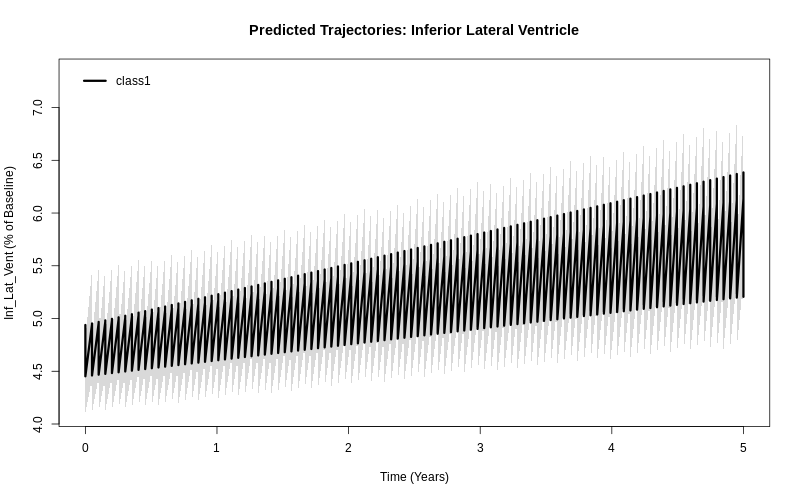

In [ ]:
%%R -w 800 -h 500 -u px
library(lcmm)

# 1. Create a simulated dataset spanning the time range (YEAR 0 to 5)
new_data <- expand.grid(
    class = factor(c("1", "2", "3")),
    YEAR = seq(0, 5, length.out = 100),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

# 2. Generate predictions
pred_Inf_Lat_Vent <- predictY(model_Inf_Lat_Vent,
                              new_data,
                              var.time = "YEAR",
                              draws = TRUE)

# 3. Explicitly plot using R's graphics device
plot(pred_Inf_Lat_Vent,
     lty = 1,
     lwd = 3,
     ylab = "Inf_Lat_Vent (% of Baseline)",
     xlab = "Time (Years)",
     main = "Predicted Trajectories: Inferior Lateral Ventricle",
     legend.loc = "topleft",
     shades = TRUE)

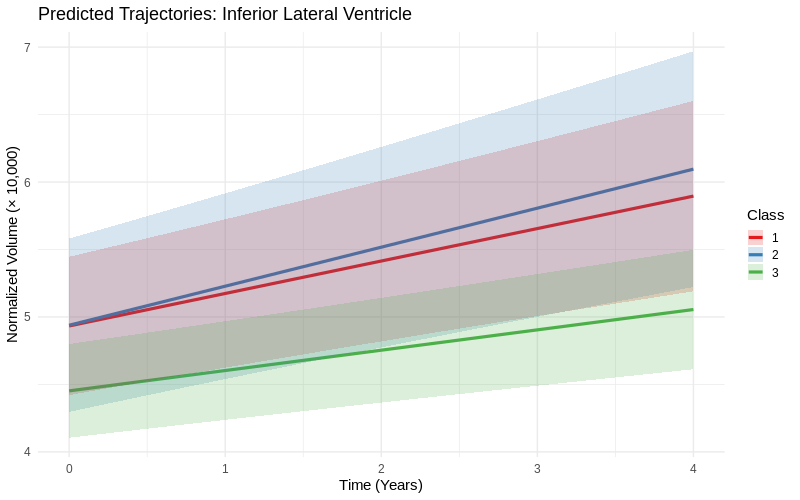

In [ ]:
%%R -w 800 -h 500 -u px
library(lcmm)
library(ggplot2)

# 1. Create a simulated dataset spanning the true time range (YEAR 0 to 4)
new_data <- expand.grid(
    YEAR = seq(0, 4, length.out = 100),
    class = factor(c("1", "2", "3")),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

# 2. Generate predictions
pred_Inf_Lat_Vent <- predictY(model_Inf_Lat_Vent,
                              new_data,
                              var.time = "YEAR",
                              draws = TRUE)

# 3. Bind predictions to our new_data to keep the 'class' grouping
plot_data <- cbind(new_data, pred_Inf_Lat_Vent$pred)

# 4. Plot using ggplot2
ggplot(plot_data, aes(x = YEAR, y = Ypred, color = class, fill = class)) +
  geom_line(linewidth = 1.5) +
  geom_ribbon(aes(ymin = lower.Ypred, ymax = upper.Ypred), alpha = 0.2, color = NA) +
  theme_minimal(base_size = 15) +
  labs(
    title = "Predicted Trajectories: Inferior Lateral Ventricle",
    x = "Time (Years)",
    y = "Normalized Volume (× 10,000)",
    color = "Class",
    fill = "Class"
  ) +
  scale_color_brewer(palette = "Set1") +
  scale_fill_brewer(palette = "Set1")

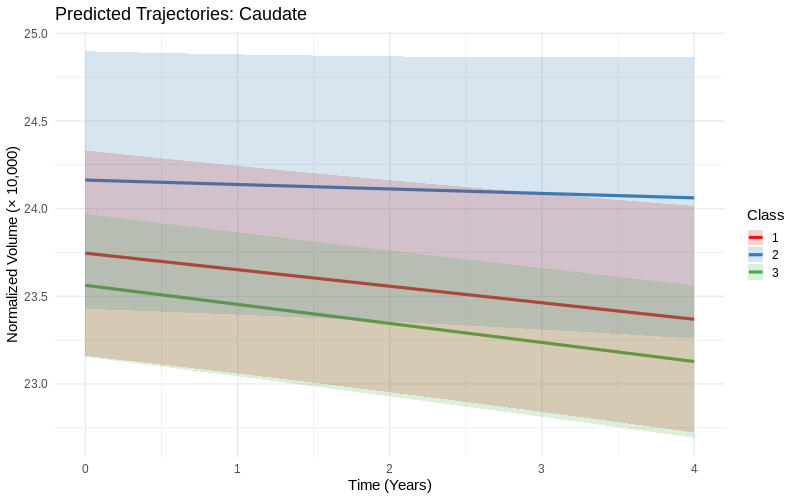

In [ ]:
%%R -w 800 -h 500 -u px
library(lcmm)
library(ggplot2)

# 1. Create a simulated dataset spanning the true time range (YEAR 0 to 4)
new_data <- expand.grid(
    YEAR = seq(0, 4, length.out = 100),
    class = factor(c("1", "2", "3")),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

# 2. Generate predictions for Caudate
pred_Caudate <- predictY(model_Caudate,
                         new_data,
                         var.time = "YEAR",
                         draws = TRUE)

# 3. Bind predictions to our new_data to keep the 'class' grouping
plot_data <- cbind(new_data, pred_Caudate$pred)

# 4. Plot using ggplot2
ggplot(plot_data, aes(x = YEAR, y = Ypred, color = class, fill = class)) +
  geom_line(linewidth = 1.5) +
  geom_ribbon(aes(ymin = lower.Ypred, ymax = upper.Ypred), alpha = 0.2, color = NA) +
  theme_minimal(base_size = 15) +
  labs(
    title = "Predicted Trajectories: Caudate",
    x = "Time (Years)",
    y = "Normalized Volume (× 10,000)",
    color = "Class",
    fill = "Class"
  ) +
  scale_color_brewer(palette = "Set1") +
  scale_fill_brewer(palette = "Set1")

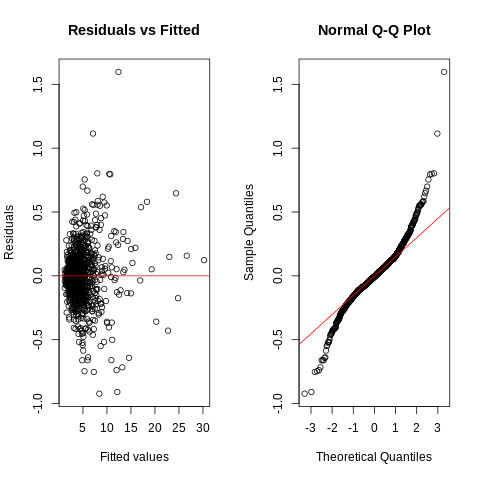

In [ ]:
%%R
res <- residuals(model_Inf_Lat_Vent)

# Diagnostic plots for the significant finding
par(mfrow = c(1,2))
plot(fitted(model_Inf_Lat_Vent), res, main = "Residuals vs Fitted",
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, col = "red")
qqnorm(res, main = "Normal Q-Q Plot"); qqline(res, col = "red")

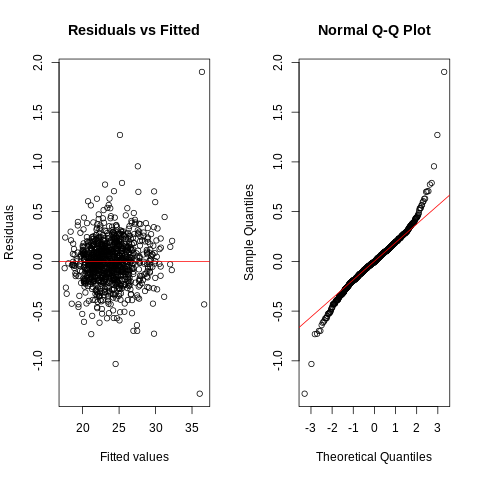

In [ ]:
%%R
res <- residuals(model_Caudate)

# Diagnostic plots for the significant finding
par(mfrow = c(1,2))
plot(fitted(model_Caudate), res, main = "Residuals vs Fitted",
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, col = "red")
qqnorm(res, main = "Normal Q-Q Plot"); qqline(res, col = "red")

## Sensitivity Analysis

In [ ]:
print("--- Sensitivity Analysis: LMM for Thalamus (Random Intercept Only) ---")
ro.r("""
model_Thalamus_ri <- hlme(Thalamus ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Thalamus_ri))
""")

--- Sensitivity Analysis: LMM for Thalamus (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Thalamus ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 1.1e-09 
                         : likelihood= 2.6e-07 
                         : second derivatives= 6.2e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -2044.27  
     AIC: 4108.54  
     BIC: 4147.99  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   67.02574 1.59628  41.989 0.00000
class1      -0.15978 0.43794  -0.3

In [ ]:
print("--- Sensitivity Analysis: LMM for Caudate (Random Intercept Only) ---")
ro.r("""
model_Caudate_ri <- hlme(Caudate ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Caudate_ri))
""")

--- Sensitivity Analysis: LMM for Caudate (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Caudate ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 2.8e-08 
                         : likelihood= 1.2e-08 
                         : second derivatives= 7.1e-14 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1356.36  
     AIC: 2732.72  
     BIC: 2772.17  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   25.17739 1.28689 19.565 0.00000
class1       0.17519 0.35122  0.499 0

In [ ]:
print("--- Sensitivity Analysis: LMM for Putamen (Random Intercept Only) ---")
ro.r("""
model_Putamen_ri <- hlme(Putamen ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Putamen_ri))
""")

--- Sensitivity Analysis: LMM for Putamen (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Putamen ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 1.2e-08 
                         : likelihood= 4.2e-09 
                         : second derivatives= 3.8e-14 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1833.95  
     AIC: 3687.9  
     BIC: 3727.35  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   37.19039 1.50442 24.721 0.00000
class1      -0.59872 0.41219 -1.453 0.

In [ ]:
print("--- Sensitivity Analysis: LMM for Hippocampus (Random Intercept Only) ---")
ro.r("""
model_Hippocampus_ri <- hlme(Hippocampus ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Hippocampus_ri))
""")

--- Sensitivity Analysis: LMM for Hippocampus (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Hippocampus ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 1.4e-05 
                         : likelihood= 1e-05 
                         : second derivatives= 1.2e-10 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1334.31  
     AIC: 2688.63  
     BIC: 2728.08  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept   38.76383 1.12165  34.560 0.00000
class1       0.26582 0.30627 

In [ ]:
print("--- Sensitivity Analysis: LMM for Choroid Plexus (Random Intercept Only) ---")
ro.r("""
model_choroid_plexus_ri <- hlme(choroid_plexus ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_choroid_plexus_ri))
""")

--- Sensitivity Analysis: LMM for Choroid Plexus (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = choroid_plexus ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  10 
     Convergence criteria: parameters= 6.6e-06 
                         : likelihood= 1.8e-05 
                         : second derivatives= 2e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -921.17  
     AIC: 1862.35  
     BIC: 1901.8  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   -0.70187 0.61486 -1.142 0.25366
class1       0.06357 0.1685

In [ ]:
print("--- Sensitivity Analysis: LMM for Pallidum (Random Intercept Only) ---")
ro.r("""
model_Pallidum_ri <- hlme(Pallidum ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Pallidum_ri))
""")

--- Sensitivity Analysis: LMM for Pallidum (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Pallidum ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  12 
     Convergence criteria: parameters= 1.1e-08 
                         : likelihood= 3.8e-08 
                         : second derivatives= 4.5e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1136.92  
     AIC: 2293.84  
     BIC: 2333.29  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   16.53250 0.60323 27.407 0.00000
class1      -0.02928 0.16632 -0.176

In [ ]:
print("--- Sensitivity Analysis: LMM for Lateral Ventricle (Random Intercept Only) ---")
ro.r("""
model_Lateral_Ventricle_ri <- hlme(Lateral_Ventricle ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Lateral_Ventricle_ri))
""")

--- Sensitivity Analysis: LMM for Lateral Ventricle (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Lateral_Ventricle ~ class * YEAR + age_bl + sex, 
    random = ~1, subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 6.5e-07 
                         : likelihood= 5.5e-10 
                         : second derivatives= 5.2e-16 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -4281.79  
     AIC: 8583.58  
     BIC: 8623.04  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept   -144.91864 24.32246   -5.958 0.00000
class1 

In [ ]:
print("--- Sensitivity Analysis: LMM for Inf Lat Vent (Random Intercept Only) ---")
ro.r("""
model_Inf_Lat_Vent_ri <- hlme(Inf_Lat_Vent ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Inf_Lat_Vent_ri))
""")

--- Sensitivity Analysis: LMM for Inf Lat Vent (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Inf_Lat_Vent ~ class * YEAR + age_bl + sex, random = ~1, 
    subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  9 
     Convergence criteria: parameters= 6e-06 
                         : likelihood= 5.7e-06 
                         : second derivatives= 8.4e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -1499.51  
     AIC: 3019.02  
     BIC: 3058.47  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept   -8.39557 1.18987 -7.056 0.00000
class1       0.35465 0.32542  

In [ ]:
print("--- Sensitivity Analysis: LMM for Cerebral White Matter (Random Intercept Only) ---")
ro.r("""
model_Cerebral_White_Matter_ri <- hlme(Cerebral_White_Matter ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_Cerebral_White_Matter_ri))
""")

--- Sensitivity Analysis: LMM for Cerebral White Matter (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Cerebral_White_Matter ~ class * YEAR + age_bl + 
    sex, random = ~1, subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  27 
     Convergence criteria: parameters= 7.4e-06 
                         : likelihood= 4.5e-09 
                         : second derivatives= 5.3e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -5356.39  
     AIC: 10732.78  
     BIC: 10772.24  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                  coef       Se     Wald p-value
intercept   1963.26840 43.30324   45.338 0.000

In [ ]:
print("--- Sensitivity Analysis: LMM for WM Hypointensities (Random Intercept Only) ---")
ro.r("""
model_WM_hypointensities_ri <- hlme(WM_hypointensities ~ class * YEAR + age_bl + sex,
              random = ~ 1,
              subject = 'PATNO',
              data = df_lmm_raw,
              ng = 1)
print(summary(model_WM_hypointensities_ri))
""")

--- Sensitivity Analysis: LMM for WM Hypointensities (Random Intercept Only) ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = WM_hypointensities ~ class * YEAR + age_bl + sex, 
    random = ~1, subject = "PATNO", ng = 1, data = df_lmm_raw)
 
Statistical Model: 
     Dataset: df_lmm_raw 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  18 
     Convergence criteria: parameters= 4.7e-10 
                         : likelihood= 3.2e-11 
                         : second derivatives= 1.1e-16 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -3808.4  
     AIC: 7636.81  
     BIC: 7676.26  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                 coef       Se    Wald p-value
intercept   -65.87499 10.63937  -6.192 0.00000
class1    

In [ ]:
import pandas as pd

# Manually extracting p-values for Class:YEAR interactions from the Sensitivity Analysis (Random Intercept Only models)
# Reference: Class 3
sensitivity_data = {
    'Region': [
        'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
        'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
        'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
    ],
    'P_Class1_vs_3_YEAR_RI': [
        0.98393, 0.41121, 0.16353, 0.17989,
        0.41129, 0.05026, 0.00199, 0.00150,
        0.95445, 0.07488
    ],
    'P_Class2_vs_3_YEAR_RI': [
        0.83040, 0.01039, 0.15645, 0.06738,
        0.00560, 0.57498, 0.00303, 0.00074,
        0.33456, 0.12148
    ]
}

df_sensitivity_pvals = pd.DataFrame(sensitivity_data)

print("--- Sensitivity Analysis Interaction P-values (Random Intercept Only) ---")
display(df_sensitivity_pvals)

--- Sensitivity Analysis Interaction P-values (Random Intercept Only) ---


,Region,P_Class1_vs_3_YEAR_RI,P_Class2_vs_3_YEAR_RI
0,Thalamus,0.98393,0.83040
1,Caudate,0.41121,0.01039
2,Putamen,0.16353,0.15645
3,Hippocampus,0.17989,0.06738
4,choroid_plexus,0.41129,0.00560
5,Pallidum,0.05026,0.57498
6,Lateral_Ventricle,0.00199,0.00303
7,Inf_Lat_Vent,0.00150,0.00074
8,Cerebral_White_Matter,0.95445,0.33456
9,WM_hypointensities,0.07488,0.12148


In [ ]:
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# Apply FDR correction to the sensitivity analysis p-values
df_sens_fdr = df_sensitivity_pvals.copy()

# Correct Class 1 vs 3 YEAR RI
reject_c1, pval_corr_c1 = fdrcorrection(df_sens_fdr['P_Class1_vs_3_YEAR_RI'], alpha=0.10, method='indep')
df_sens_fdr['FDR_P_Class1_RI'] = pval_corr_c1
df_sens_fdr['Sig_Class1_RI (q<0.10)'] = reject_c1

# Correct Class 2 vs 3 YEAR RI
reject_c2, pval_corr_c2 = fdrcorrection(df_sens_fdr['P_Class2_vs_3_YEAR_RI'], alpha=0.10, method='indep')
df_sens_fdr['FDR_P_Class2_RI'] = pval_corr_c2
df_sens_fdr['Sig_Class2_RI (q<0.10)'] = reject_c2

print("--- FDR Corrected P-values for Sensitivity Analysis (Random Intercept Models, q < 0.10) ---")
display(df_sens_fdr)

--- FDR Corrected P-values for Sensitivity Analysis (Random Intercept Models, q < 0.10) ---


,Region,P_Class1_vs_3_YEAR_RI,P_Class2_vs_3_YEAR_RI,FDR_P_Class1_RI,Sig_Class1_RI (q<0.10),FDR_P_Class2_RI,Sig_Class2_RI (q<0.10)
0,Thalamus,0.98393,0.83040,0.983930,False,0.830400,False
1,Caudate,0.41121,0.01039,0.514112,False,0.025975,True
2,Putamen,0.16353,0.15645,0.299817,False,0.223500,False
3,Hippocampus,0.17989,0.06738,0.299817,False,0.134760,False
4,choroid_plexus,0.41129,0.00560,0.514112,False,0.018667,True
5,Pallidum,0.05026,0.57498,0.167533,False,0.638867,False
6,Lateral_Ventricle,0.00199,0.00303,0.009950,True,0.015150,True
7,Inf_Lat_Vent,0.00150,0.00074,0.009950,True,0.007400,True
8,Cerebral_White_Matter,0.95445,0.33456,0.983930,False,0.418200,False
9,WM_hypointensities,0.07488,0.12148,0.187200,False,0.202467,False


In [ ]:
# 1. Prepare the Primary Analysis dataframe for merging
# df_pvals_fdr contains the Random Slope model results
df_primary = df_pvals_fdr[['Region', 'FDR_P_Class1', 'Sig_Class1 (q<0.10)', 'FDR_P_Class2', 'Sig_Class2 (q<0.10)']].copy()
df_primary.columns = ['Region', 'Primary_FDR_P_C1', 'Primary_Sig_C1', 'Primary_FDR_P_C2', 'Primary_Sig_C2']

# 2. Prepare the Sensitivity Analysis dataframe for merging
df_sensitivity = df_sens_fdr[['Region', 'FDR_P_Class1_RI', 'Sig_Class1_RI (q<0.10)', 'FDR_P_Class2_RI', 'Sig_Class2_RI (q<0.10)']].copy()
df_sensitivity.columns = ['Region', 'Sens_FDR_P_C1', 'Sens_Sig_C1', 'Sens_FDR_P_C2', 'Sens_Sig_C2']

# 3. Merge and reorganize
df_final_comparison = df_primary.merge(df_sensitivity, on='Region')

# Sort by Class 2 Primary P-value to highlight the most robust findings
df_final_comparison = df_final_comparison.sort_values('Primary_FDR_P_C2')

print("--- Final Comparison: Primary (Random Slopes) vs. Sensitivity (Random Intercepts) ---")
display(df_final_comparison)

--- Final Comparison: Primary (Random Slopes) vs. Sensitivity (Random Intercepts) ---


,Region,Primary_FDR_P_C1,Primary_Sig_C1,Primary_FDR_P_C2,Primary_Sig_C2,Sens_FDR_P_C1,Sens_Sig_C1,Sens_FDR_P_C2,Sens_Sig_C2
7,Inf_Lat_Vent,0.336150,False,0.088600,True,0.009950,True,0.007400,True
6,Lateral_Ventricle,0.865400,False,0.100950,False,0.009950,True,0.015150,True
1,Caudate,0.977071,False,0.108900,False,0.514112,False,0.025975,True
4,choroid_plexus,0.990150,False,0.108900,False,0.514112,False,0.018667,True
3,Hippocampus,0.934983,False,0.180340,False,0.299817,False,0.134760,False
2,Putamen,0.865400,False,0.509733,False,0.299817,False,0.223500,False
9,WM_hypointensities,0.336150,False,0.537900,False,0.187200,False,0.202467,False
8,Cerebral_White_Matter,0.990150,False,0.537900,False,0.983930,False,0.418200,False
0,Thalamus,0.990150,False,0.928111,False,0.983930,False,0.830400,False
5,Pallidum,0.865400,False,0.989730,False,0.167533,False,0.638867,False


In [ ]:
import pandas as pd
import rpy2.robjects as ro

# 1. Define the list of regions we modeled
regions = [
    'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
    'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
    'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
]

# 2. Extract AIC and BIC from the R objects using a small R helper script
ro.r("""
get_metrics <- function(model_name) {
  if (exists(model_name)) {
    m <- get(model_name)
    return(c(AIC = m$AIC, BIC = m$BIC))
  } else {
    return(c(AIC = NA, BIC = NA))
  }
}
""")

comparison_results = []

for region in regions:
    # Primary models were named 'model_Region'
    # Sensitivity models were named 'model_Region_ri'
    metrics_rs = ro.r(f"get_metrics('model_{region}')")
    metrics_ri = ro.r(f"get_metrics('model_{region}_ri')")

    aic_rs, bic_rs = metrics_rs[0], metrics_rs[1]
    aic_ri, bic_ri = metrics_ri[0], metrics_ri[1]

    # Determine model preference
    better_aic = "Random Slope" if aic_rs < aic_ri else "Random Intercept"
    better_bic = "Random Slope" if bic_rs < bic_ri else "Random Intercept"

    comparison_results.append({
        'Region': region,
        'AIC (Random ~ YEAR)': aic_rs,
        'BIC (Random ~ YEAR)': bic_rs,
        'AIC (Random ~ 1)': aic_ri,
        'BIC (Random ~ 1)': bic_ri,
        'Smaller AIC': better_aic,
        'Smaller BIC': better_bic
    })

# 3. Create DataFrame and Display
df_model_fit = pd.DataFrame(comparison_results)

print("--- Model Comparison Table: Random Slopes vs. Random Intercepts ---")
display(df_model_fit)

# Quick summary
win_aic = df_model_fit['Smaller AIC'].value_counts()
win_bic = df_model_fit['Smaller BIC'].value_counts()
print(f"\nSummary (AIC): {win_aic.get('Random Slope', 0)} regions favored Random Slope.")
print(f"Summary (BIC): {win_bic.get('Random Slope', 0)} regions favored Random Slope.")

--- Model Comparison Table: Random Slopes vs. Random Intercepts ---


,Region,AIC (Random ~ YEAR),BIC (Random ~ YEAR),AIC (Random ~ 1),BIC (Random ~ 1),Smaller AIC,Smaller BIC
0,Thalamus,4062.961560,4110.306607,4108.538892,4147.993098,Random Slope,Random Slope
1,Caudate,2695.307659,2742.652706,2732.715083,2772.169289,Random Slope,Random Slope
2,Putamen,3629.183211,3676.528258,3687.899522,3727.353728,Random Slope,Random Slope
3,Hippocampus,2648.523392,2695.868439,2688.627161,2728.081367,Random Slope,Random Slope
4,choroid_plexus,1828.631023,1875.976070,1862.345420,1901.799626,Random Slope,Random Slope
5,Pallidum,2210.328473,2257.673520,2293.838613,2333.292820,Random Slope,Random Slope
6,Lateral_Ventricle,8260.645456,8307.990503,8583.582956,8623.037162,Random Slope,Random Slope
7,Inf_Lat_Vent,2676.873656,2724.218703,3019.015012,3058.469218,Random Slope,Random Slope
8,Cerebral_White_Matter,10699.403205,10746.748252,10732.783897,10772.238103,Random Slope,Random Slope
9,WM_hypointensities,7171.160866,7218.505913,7636.806594,7676.260800,Random Slope,Random Slope



Summary (AIC): 10 regions favored Random Slope.
Summary (BIC): 10 regions favored Random Slope.


In [ ]:
import pandas as pd
import rpy2.robjects as ro
from scipy.stats import chi2

# 1. Define regions
regions = [
    'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
    'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
    'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
]

# 2. Extract Log-Likelihoods and Number of Parameters
ro.r("""
get_lrt_stats <- function(model_name) {
  if (exists(model_name)) {
    m <- get(model_name)
    return(c(loglik = m$loglik, npm = length(m$best)))
  } else {
    return(c(loglik = NA, npm = NA))
  }
}
""")

lrt_results = []

for region in regions:
    # Get stats for Random Slope (RS) and Random Intercept (RI)
    stats_rs = ro.r(f"get_lrt_stats('model_{region}')")
    stats_ri = ro.r(f"get_lrt_stats('model_{region}_ri')")

    loglik_rs, npm_rs = stats_rs[0], stats_rs[1]
    loglik_ri, npm_ri = stats_ri[0], stats_ri[1]

    # LRT calculation: 2 * (LogLik_complex - LogLik_simple)
    # df = difference in number of parameters
    lrt_stat = 2 * (loglik_rs - loglik_ri)
    df_diff = npm_rs - npm_ri
    p_val = chi2.sf(lrt_stat, df_diff)

    lrt_results.append({
        'Region': region,
        'LogLik (Slope)': loglik_rs,
        'LogLik (Intercept)': loglik_ri,
        'LRT Statistic': lrt_stat,
        'df Difference': df_diff,
        'LRT P-value': p_val
    })

# 3. Create DataFrame and format scientific notation
df_lrt = pd.DataFrame(lrt_results)
pd.options.display.float_format = '{:.4e}'.format

print("--- Likelihood Ratio Test: Random Slope vs. Random Intercept ---")
display(df_lrt)

# Check significance
sig_count = (df_lrt['LRT P-value'] < 0.05).sum()
print(f"\nSummary: In {sig_count} out of {len(regions)} regions, the Random Slope model is significantly better (p < 0.05).")

--- Likelihood Ratio Test: Random Slope vs. Random Intercept ---


,Region,LogLik (Slope),LogLik (Intercept),LRT Statistic,df Difference,LRT P-value
0,Thalamus,-2.0195e+03,-2.0443e+03,4.9577e+01,2.0000e+00,1.7156e-11
1,Caudate,-1.3357e+03,-1.3564e+03,4.1407e+01,2.0000e+00,1.0197e-09
2,Putamen,-1.8026e+03,-1.8339e+03,6.2716e+01,2.0000e+00,2.4062e-14
3,Hippocampus,-1.3123e+03,-1.3343e+03,4.4104e+01,2.0000e+00,2.6484e-10
4,choroid_plexus,-9.0232e+02,-9.2117e+02,3.7714e+01,2.0000e+00,6.4628e-09
5,Pallidum,-1.0932e+03,-1.1369e+03,8.7510e+01,2.0000e+00,9.9406e-20
6,Lateral_Ventricle,-4.1183e+03,-4.2818e+03,3.2694e+02,2.0000e+00,1.0149e-71
7,Inf_Lat_Vent,-1.3264e+03,-1.4995e+03,3.4614e+02,2.0000e+00,6.8606e-76
8,Cerebral_White_Matter,-5.3377e+03,-5.3564e+03,3.7381e+01,2.0000e+00,7.6364e-09
9,WM_hypointensities,-3.5736e+03,-3.8084e+03,4.6965e+02,2.0000e+00,1.0417e-102



Summary: In 10 out of 10 regions, the Random Slope model is significantly better (p < 0.05).


## Main Figure (early version)

In [ ]:
import pandas as pd

# Define the expected core years (plus the V02 = 0.5 exception you noted)
expected_years = [0.0, 0.5, 1.0, 2.0, 4.0]

# Find all scans that don't fall into the expected years
anomalous_scans = df_mri_norm[~df_mri_norm['YEAR'].isin(expected_years)].copy()

print(f"Found {len(anomalous_scans)} anomalous scans.")
print("\n--- Breakdown by YEAR and EVENT_ID ---")
display(anomalous_scans.groupby(['YEAR', 'EVENT_ID'])['PATNO'].count().reset_index(name='Count'))

print("\n--- Detailed List of Anomalous Scans ---")
display(anomalous_scans[['PATNO', 'EVENT_ID', 'YEAR', 'age_bl', 'sex']].sort_values(by=['YEAR', 'PATNO']))


Found 2 anomalous scans.

--- Breakdown by YEAR and EVENT_ID ---


,YEAR,EVENT_ID,Count
0,3.0000e+00,V08,2



--- Detailed List of Anomalous Scans ---


,PATNO,EVENT_ID,YEAR,age_bl,sex
749,3309,V08,3.0000e+00,5.4038e+01,0
757,3323,V08,3.0000e+00,6.9282e+01,1


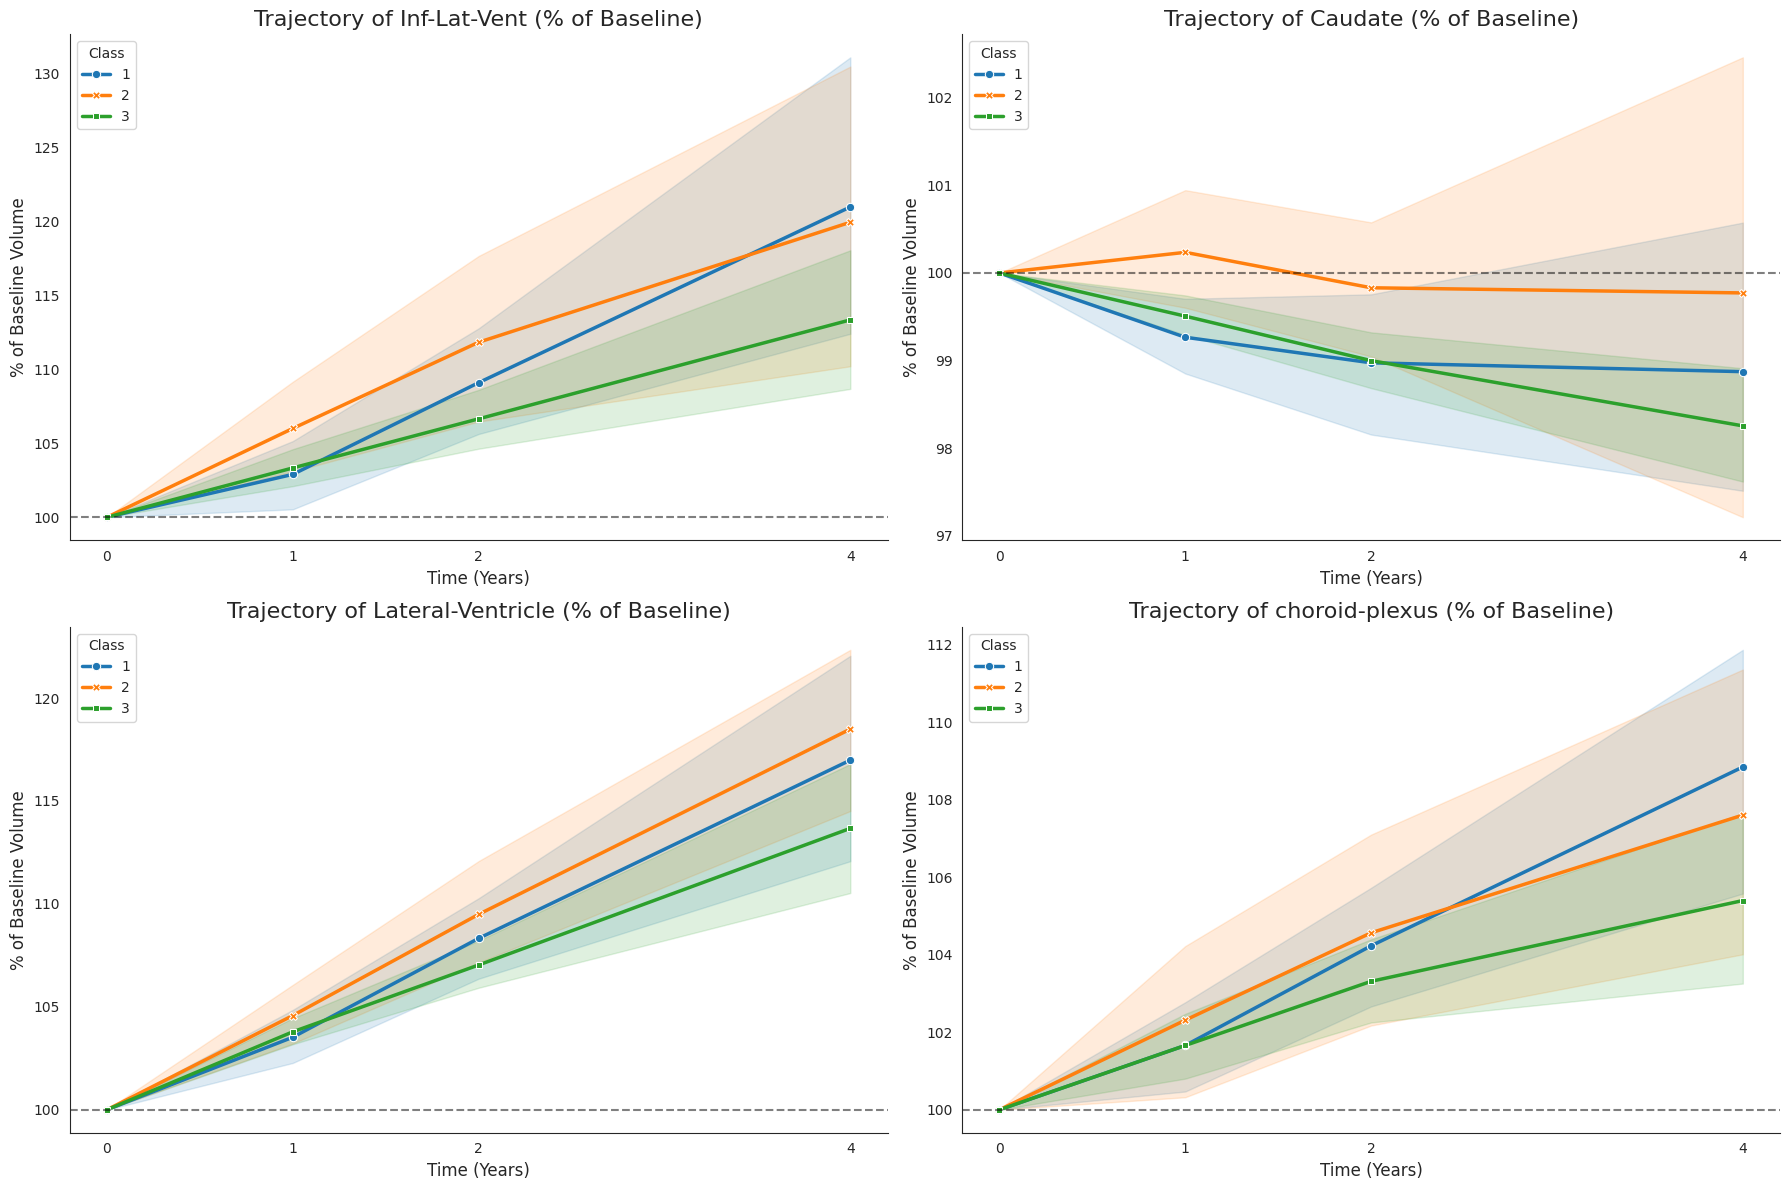

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Extract class assignments from the R model into Python
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

# 2. Define the 4 target regions
target_regions = ['Inf-Lat-Vent', 'Caudate', 'Lateral-Ventricle', 'choroid-plexus']

# 3. Prepare the plotting data (Normalize by MaskVol and then % of baseline)
df_plot_data = fs_data[['PATNO', 'EVENT_ID', 'MaskVol']].copy()
for region in target_regions:
    avg_vol = (fs_data[f'Left-{region}'] + fs_data[f'Right-{region}']) / 2
    df_plot_data[region] = avg_vol / fs_data['MaskVol']

# Merge with class and YEAR
df_plot_data = df_plot_data.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')
df_plot_data = df_plot_data.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')

# Calculate % of baseline per subject
def get_pct_of_bl(group):
    group = group.sort_values('YEAR')
    bl_row = group[group['YEAR'] == 0]
    if not bl_row.empty:
        for region in target_regions:
            bl_val = bl_row[region].values[0]
            if bl_val > 0:
                group[f'{region}_pct'] = (group[region] / bl_val) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in target_regions:
            group[f'{region}_pct'] = np.nan
    return group

# Updated to silence DeprecationWarning and handle grouping columns explicitly
df_plot_data = df_plot_data.groupby('PATNO', group_keys=False).apply(get_pct_of_bl, include_groups=False).reset_index()

# 4. Filter for robust timepoints
robust_years = [0.0, 1.0, 2.0, 4.0]
df_plot_clean = df_plot_data[df_plot_data['YEAR'].isin(robust_years)].copy()

# 5. Plotting
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, region in enumerate(target_regions):
    sns.lineplot(data=df_plot_clean, x='YEAR', y=f'{region}_pct', hue='class',
                 style='class', markers=True, dashes=False, palette='tab10',
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[i])

    axes[i].set_title(f"Trajectory of {region} (% of Baseline)", fontsize=16)
    axes[i].set_xlabel("Time (Years)", fontsize=12)
    axes[i].set_ylabel("% of Baseline Volume", fontsize=12)
    axes[i].set_xticks(robust_years)
    axes[i].axhline(100, ls='--', color='black', alpha=0.5)
    axes[i].legend(title='Class')
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Learn more about the underlying theory at https://ggplot2-book.org/

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



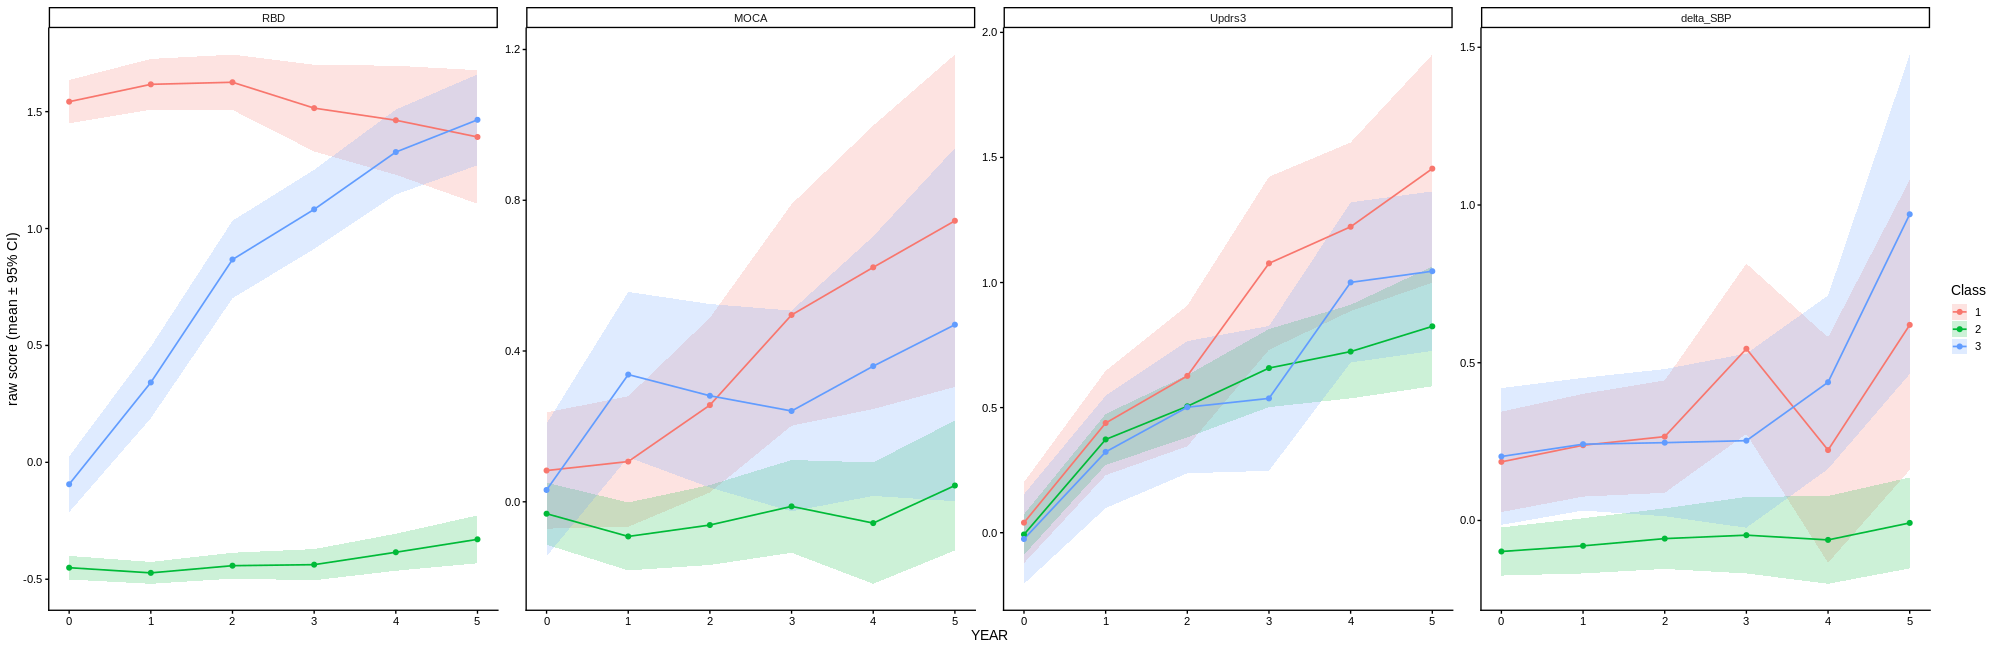

In [ ]:
%%R -w 2000 -h 650

library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

d <- df %>%
  select(PATNO, YEAR, z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO")

table(is.na(d$class))

long <- d %>%
  pivot_longer(
    cols = c(z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp),
    names_to = "domain",
    values_to = "value"
  ) %>%
  mutate(
    domain = recode(
      domain,
      z_bl_rem = "RBD",
      z_bl_trans_moca = "MOCA",
      z_bl_updrs3_score = "Updrs3",
      z_bl_delta_sbp = "delta_SBP"
    ),
    domain = factor(domain, levels = c("RBD", "MOCA", "Updrs3", "delta_SBP"))
  )

plot_df <- long %>%
  group_by(class, YEAR, domain) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    n    = sum(!is.na(value)),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~domain, nrow = 1, scales = "free_y") +
  labs(
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) + theme_classic(base_size = 14)

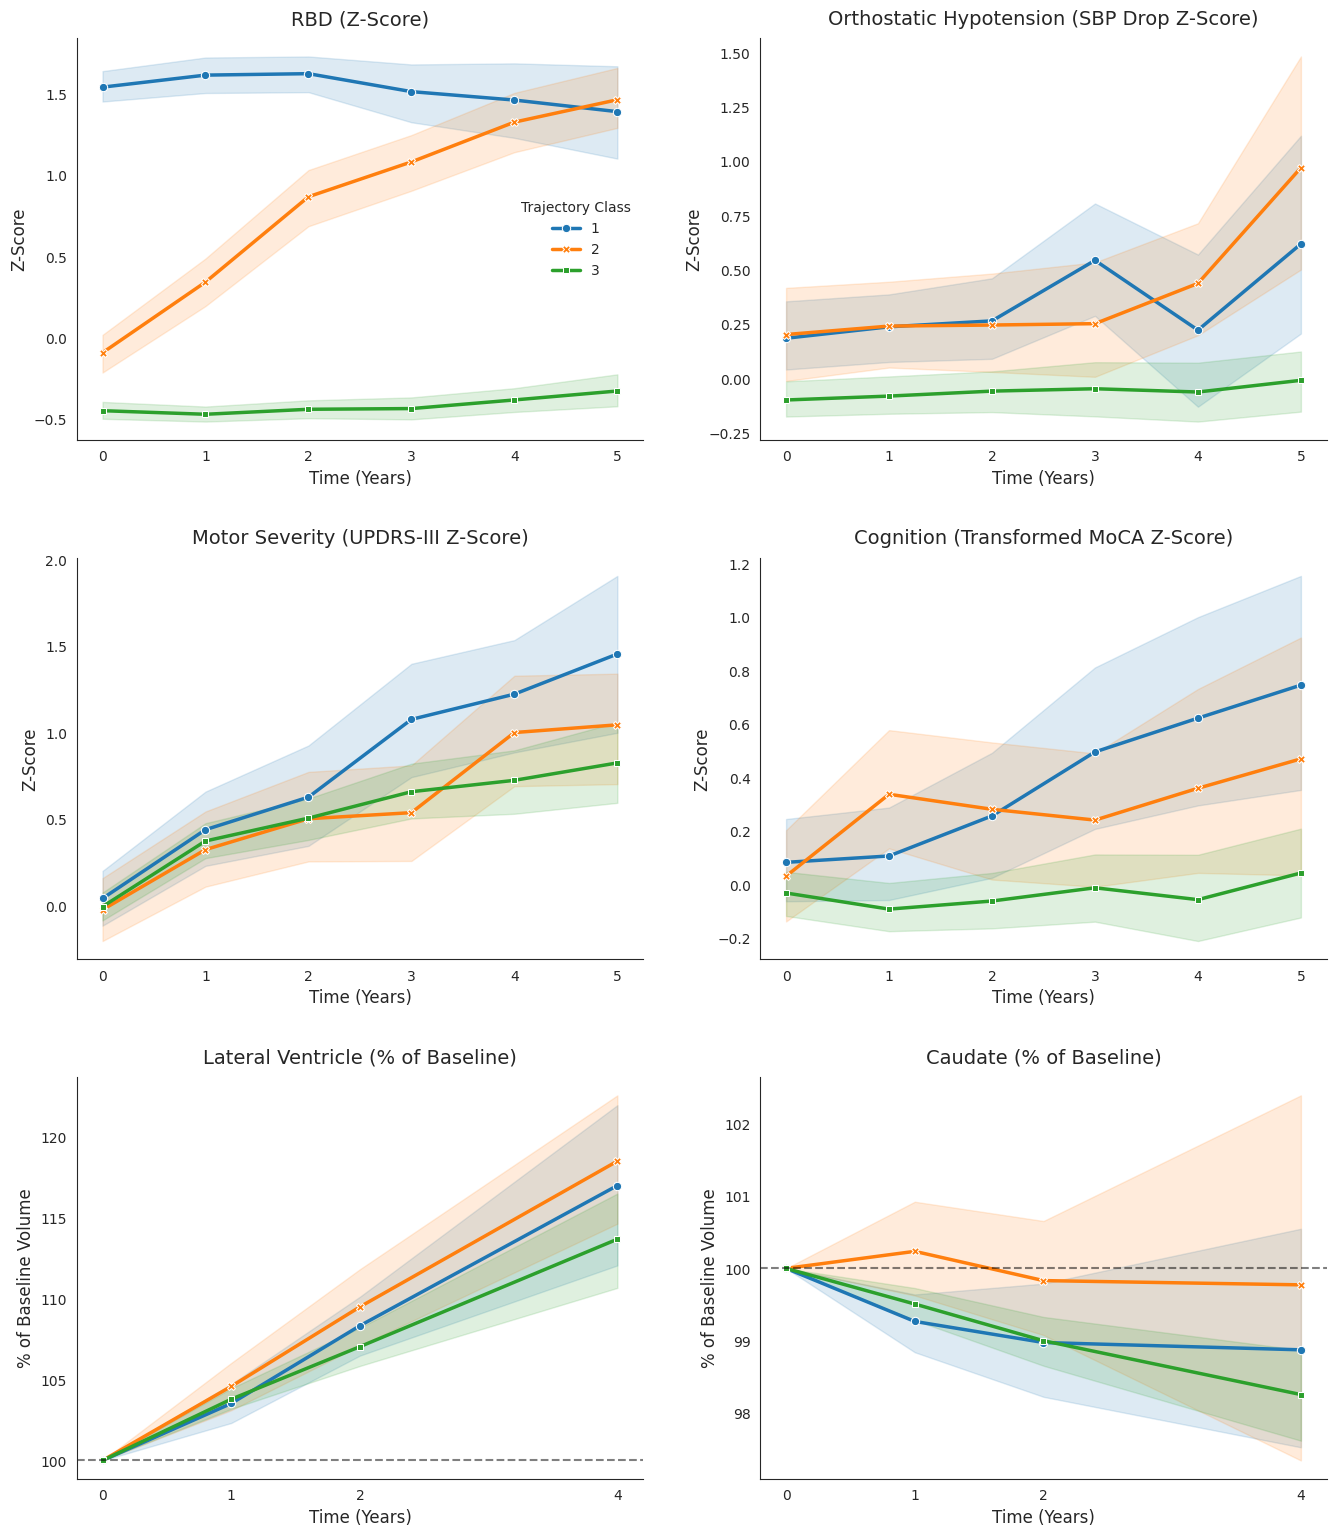

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Ensure consistent class types (strings for categorical plotting)
pp_m3['class'] = pp_m3['class'].astype(int).astype(str)
df_plot_clean['class'] = df_plot_clean['class'].astype(int).astype(str)

# 2. Prepare Clinical Data
# We map the clinical variables from df_pd_final to the permuted classes
clinical_vars = {
    'z_bl_rem': 'RBD (Z-Score)',
    'z_bl_delta_sbp': 'Orthostatic Hypotension (SBP Drop Z-Score)',
    'z_bl_updrs3_score': 'Motor Severity (UPDRS-III Z-Score)',
    'z_bl_trans_moca': 'Cognition (Transformed MoCA Z-Score)'
}

# Merge clinical features with consistent, permuted class assignments
df_clinical = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars.keys())].copy()
df_clinical = df_clinical.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

# 3. Setup the 3x2 Figure
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

# Define consistent color palette and order
hue_order = ['1', '2', '3']
palette = sns.color_palette("tab10", n_colors=3)

# 4. Plot Clinical variables (Top 2 rows = 4 panels)
for i, (col, title) in enumerate(clinical_vars.items()):
    sns.lineplot(data=df_clinical, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[i], legend=(i==0))

    axes[i].set_title(title, fontsize=14, pad=10)
    axes[i].set_xlabel("Time (Years)", fontsize=12)
    axes[i].set_ylabel("Z-Score", fontsize=12)
    axes[i].set_xticks([0, 1, 2, 3, 4, 5])
    sns.despine(ax=axes[i])

    if i == 0:
        axes[i].legend(title='Trajectory Class', frameon=False)

# 5. Plot MRI variables (Bottom row = 2 panels)
mri_vars = {
    'Lateral-Ventricle_pct': 'Lateral Ventricle (% of Baseline)',
    'Caudate_pct': 'Caudate (% of Baseline)'
}

robust_years = [0.0, 1.0, 2.0, 4.0]

for j, (col, title) in enumerate(mri_vars.items()):
    ax_idx = j + 4
    sns.lineplot(data=df_plot_clean, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[ax_idx], legend=False)

    axes[ax_idx].set_title(title, fontsize=14, pad=10)
    axes[ax_idx].set_xlabel("Time (Years)", fontsize=12)
    axes[ax_idx].set_ylabel("% of Baseline Volume", fontsize=12)
    axes[ax_idx].set_xticks(robust_years)
    axes[ax_idx].axhline(100, ls='--', color='black', alpha=0.5)
    sns.despine(ax=axes[ax_idx])

plt.tight_layout(pad=3.0)
plt.show()

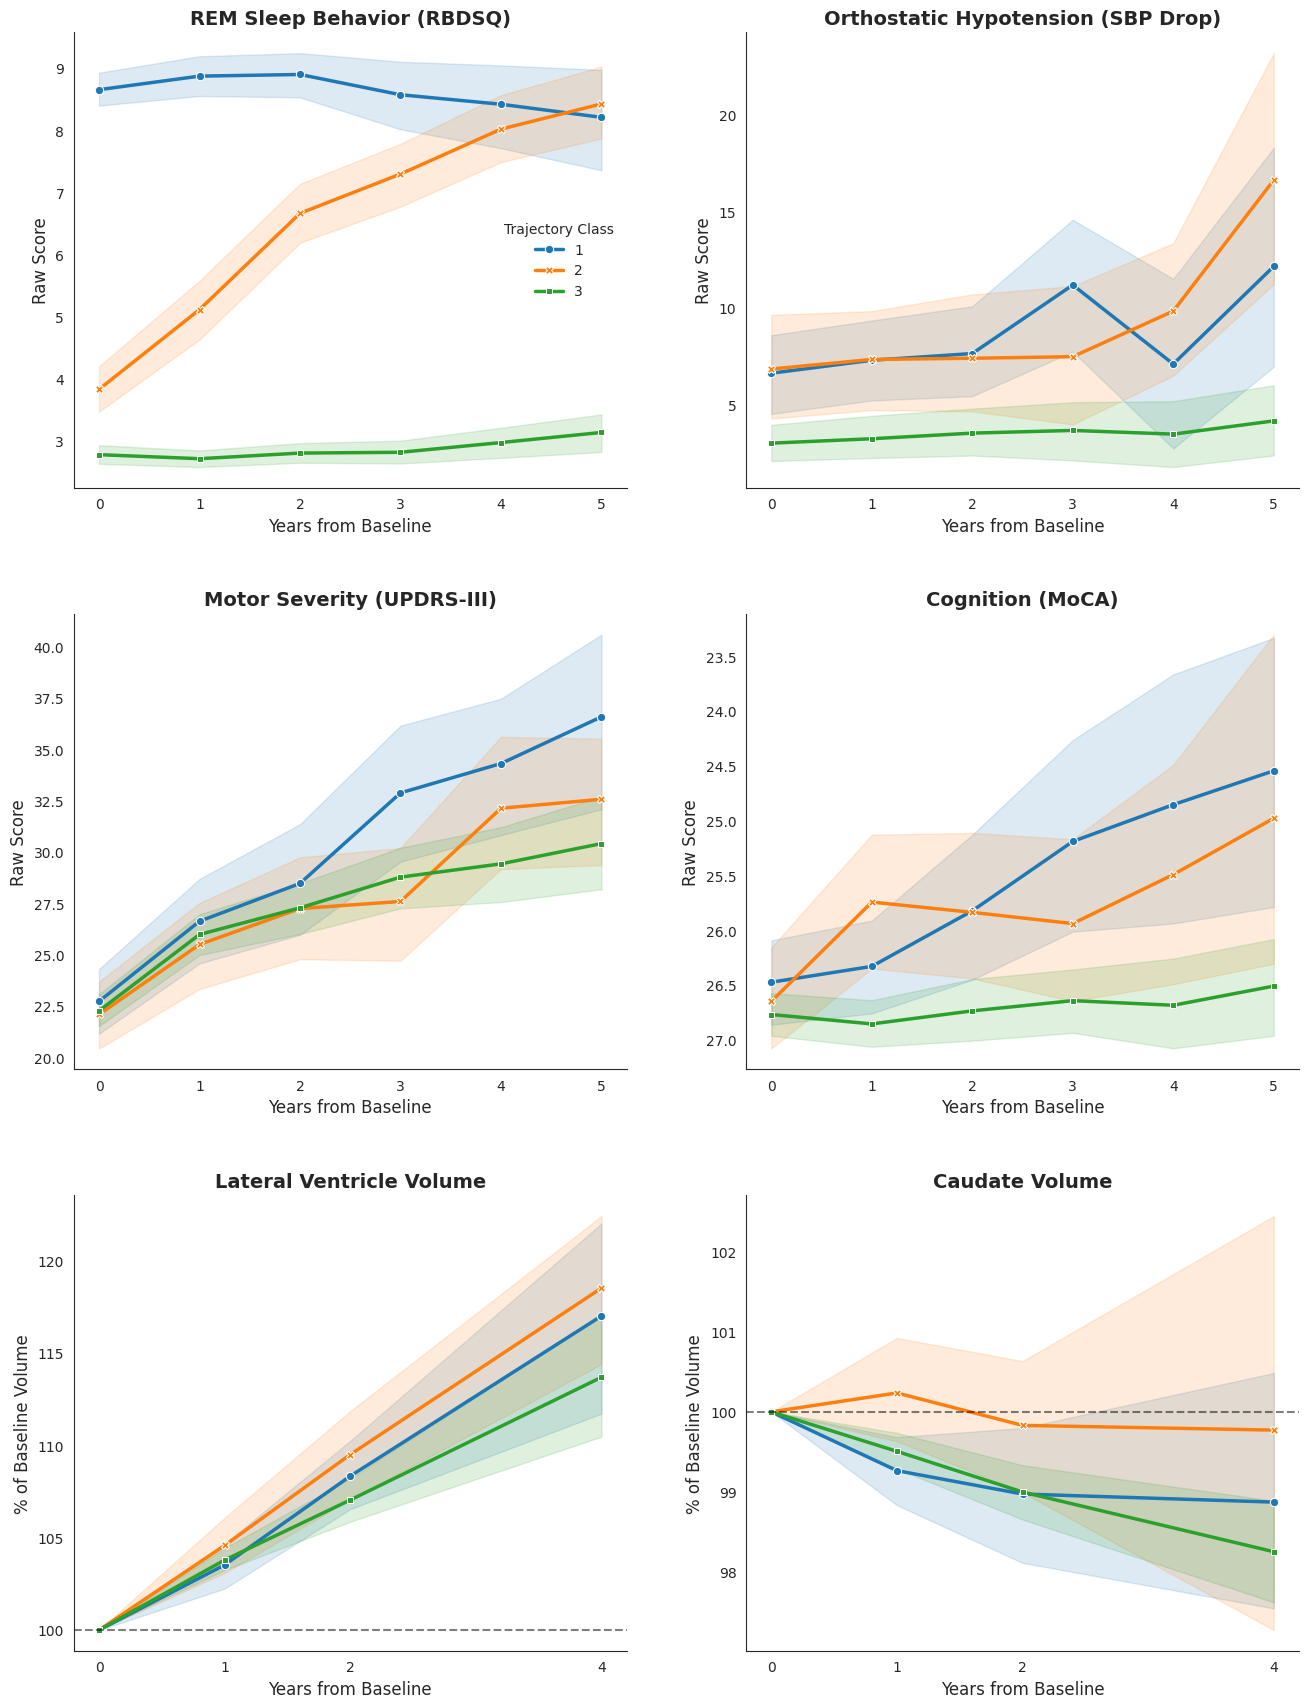

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Get consistent class assignments and metadata
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)
pp_m3['class'] = pp_m3['class'].astype(int).astype(str)

# 2. Prepare RAW Clinical Data
clinical_vars_raw = {
    'rem': 'REM Sleep Behavior (RBDSQ)',
    'delta_sbp': 'Orthostatic Hypotension (SBP Drop)',
    'updrs3_score': 'Motor Severity (UPDRS-III)',
    'moca': 'Cognition (MoCA)'
}

df_clinical_raw = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars_raw.keys())].copy()
df_clinical_raw = df_clinical_raw.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

# 3. Prepare MRI Data as % of Baseline
target_mri = ['Lateral-Ventricle', 'Caudate']
df_mri_pct = fs_data[['PATNO', 'EVENT_ID', 'MaskVol']].copy()
for region in target_mri:
    avg_vol = (fs_data[f'Left-{region}'] + fs_data[f'Right-{region}']) / 2
    df_mri_pct[region] = avg_vol / fs_data['MaskVol']

df_mri_pct = df_mri_pct.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')
df_mri_pct = df_mri_pct.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')

def get_pct_of_bl(group):
    group = group.sort_values('YEAR')
    bl_row = group[group['YEAR'] == 0]
    if not bl_row.empty:
        for region in target_mri:
            bl_val = bl_row[region].values[0]
            if bl_val > 0:
                group[f'{region}_pct'] = (group[region] / bl_val) * 100
            else:
                group[f'{region}_pct'] = np.nan
    else:
        for region in target_mri:
            group[f'{region}_pct'] = np.nan
    return group

df_mri_pct = df_mri_pct.groupby('PATNO', group_keys=False).apply(get_pct_of_bl, include_groups=False).reset_index()
robust_years = [0.0, 1.0, 2.0, 4.0]
df_mri_clean = df_mri_pct[df_mri_pct['YEAR'].isin(robust_years)].copy()
df_mri_clean['class'] = df_mri_clean['class'].astype(str)

# 4. Create the 3x2 Unified Figure
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

hue_order = ['1', '2', '3']
palette = sns.color_palette("tab10", n_colors=3)

# A. Plot Clinical Raw Scores
for i, (col, title) in enumerate(clinical_vars_raw.items()):
    sns.lineplot(data=df_clinical_raw, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[i], legend=(i==0))
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Years from Baseline", fontsize=12)
    axes[i].set_ylabel("Raw Score", fontsize=12)
    axes[i].set_xticks([0, 1, 2, 3, 4, 5])

    # INVERT Y-AXIS SPECIFICALLY FOR MOCA
    if col == 'moca':
        axes[i].invert_yaxis()

    sns.despine(ax=axes[i])
    if i == 0:
        # Updated legend handling to match previous stable method
        axes[i].legend(title='Trajectory Class', frameon=False)

# B. Plot MRI % of Baseline
mri_vars = ['Lateral-Ventricle_pct', 'Caudate_pct']
mri_labels = ['Lateral Ventricle', 'Caudate']
for j, col in enumerate(mri_vars):
    ax_idx = j + 4
    sns.lineplot(data=df_mri_clean, x='YEAR', y=col, hue='class', style='class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=axes[ax_idx], legend=False)
    axes[ax_idx].set_title(mri_labels[j] + " Volume", fontsize=14, fontweight='bold')
    axes[ax_idx].set_xlabel("Years from Baseline", fontsize=12)
    axes[ax_idx].set_ylabel("% of Baseline Volume", fontsize=12)
    axes[ax_idx].set_xticks(robust_years)
    axes[ax_idx].axhline(100, ls='--', color='black', alpha=0.5)
    sns.despine(ax=axes[ax_idx])

plt.tight_layout(pad=4.0)
plt.show()

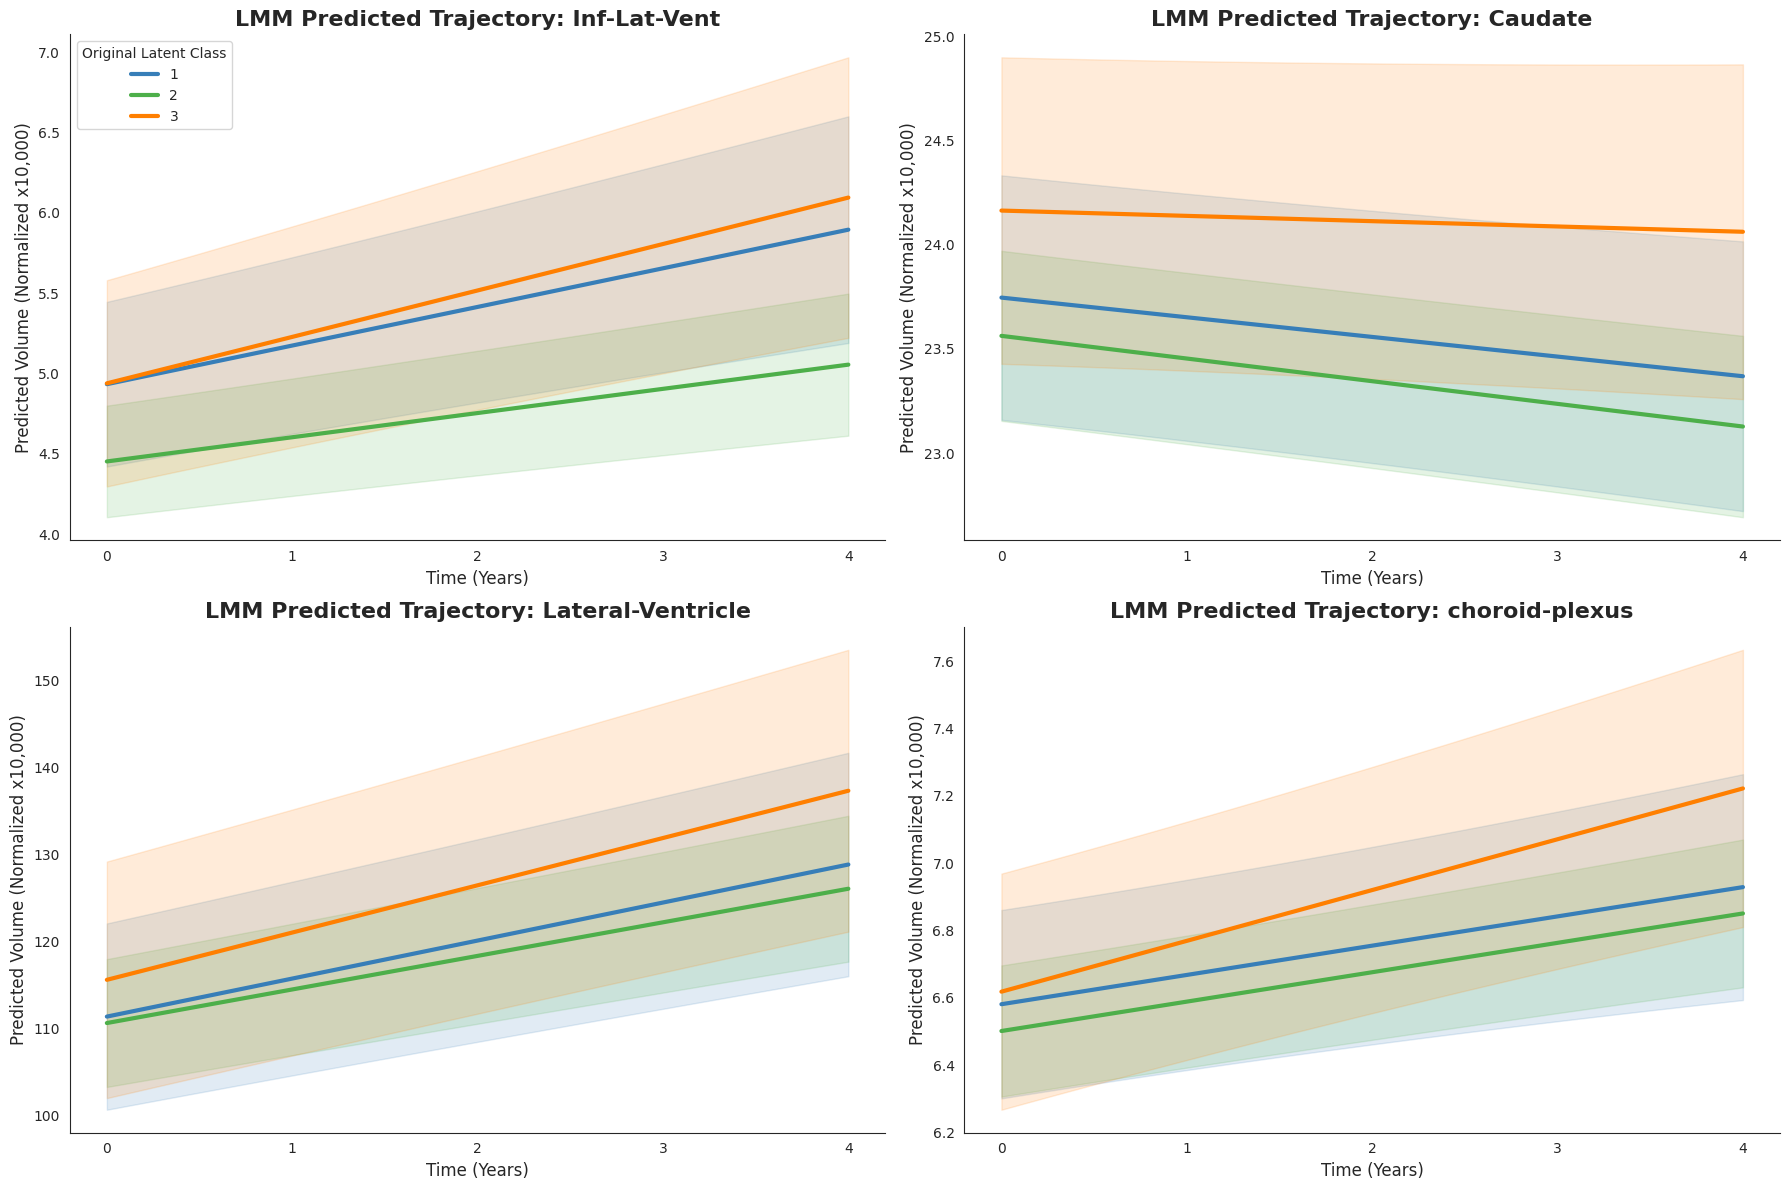

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rpy2.robjects as ro

# 1. Generate predictions in R for all 4 models
ro.r("""
library(lcmm)
new_data <- expand.grid(
    YEAR = seq(0, 4, length.out = 100),
    class = factor(c("1", "2", "3")),
    age_bl = mean(df_lmm_raw$age_bl, na.rm = TRUE),
    sex = factor("1", levels = c("0", "1"))
)

get_preds <- function(model, region_name) {
    pred <- predictY(model, new_data, var.time = "YEAR", draws = TRUE)
    df <- cbind(new_data, pred$pred)
    df$Region <- region_name
    return(df)
}

pred_inf_lat_vent <- get_preds(model_Inf_Lat_Vent, 'Inf-Lat-Vent')
pred_caudate <- get_preds(model_Caudate, 'Caudate')
pred_lat_vent <- get_preds(model_Lateral_Ventricle, 'Lateral-Ventricle')
pred_choroid <- get_preds(model_choroid_plexus, 'choroid-plexus')

all_preds <- rbind(pred_inf_lat_vent, pred_caudate, pred_lat_vent, pred_choroid)
""")

# 2. Pull predictions back into Python
with (ro.default_converter + ro.pandas2ri.converter).context():
    df_preds = ro.conversion.get_conversion().rpy2py(ro.r("all_preds"))

# --- RELABEL CLASSES TO UNPERMUTED ORIGINALS ---
# Model Class 1 -> Original Class 1
# Model Class 2 -> Original Class 3
# Model Class 3 -> Original Class 2
class_map = {'1': '1', '2': '3', '3': '2'}
df_preds['orig_class'] = df_preds['class'].astype(str).map(class_map)

# 3. Setup the 2x2 Figure
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

target_regions = ['Inf-Lat-Vent', 'Caudate', 'Lateral-Ventricle', 'choroid-plexus']

# Reverting to the preferred color scheme:
# Class 3 (Fastest) in Orange
palette_dict = {
    '1': '#377eb8', # Blue
    '2': '#4daf4a', # Green
    '3': '#ff7f00'  # Orange (Distinctive for Class 3)
}
hue_order = ['1', '2', '3']

# 4. Plotting
for i, region in enumerate(target_regions):
    data = df_preds[df_preds['Region'] == region]

    # Plot central lines
    sns.lineplot(data=data, x='YEAR', y='Ypred', hue='orig_class',
                 palette=palette_dict, hue_order=hue_order, linewidth=3, ax=axes[i], legend=(i==0))

    # Plot confidence bands manually
    for cls in hue_order:
        cls_data = data[data['orig_class'] == cls]
        axes[i].fill_between(cls_data['YEAR'], cls_data['lower.Ypred'], cls_data['upper.Ypred'],
                             color=palette_dict[cls], alpha=0.15)

    axes[i].set_title(f"LMM Predicted Trajectory: {region}", fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Time (Years)", fontsize=12)
    axes[i].set_ylabel("Predicted Volume (Normalized x10,000)", fontsize=12)
    axes[i].set_xticks([0, 1, 2, 3, 4])
    sns.despine(ax=axes[i])

axes[0].legend(title='Original Latent Class', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## Boxplots



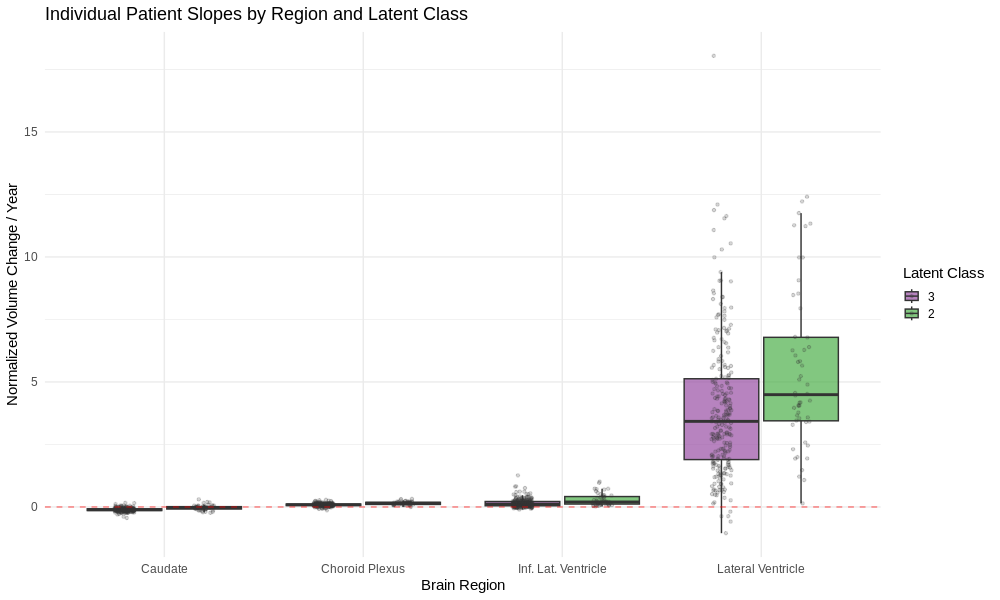

In [ ]:
%%R -w 1000 -h 600 -u px
library(ggplot2)
library(dplyr)

# Function to extract Individual Subject Slopes
extract_slopes <- function(model_obj, region_name) {
  b <- model_obj$best
  slope_ref <- b["YEAR"]
  slope_diff_c1 <- b["class1:YEAR"]
  slope_diff_c2 <- b["class2:YEAR"]

  re <- model_obj$predRE
  names(re)[which(names(re) == "YEAR")] <- "Random_Slope"

  classes <- unique(df_lmm_raw[, c("PATNO", "class")])
  dat <- merge(re, classes, by="PATNO")

  dat$Fixed_Slope <- ifelse(dat$class == "3", slope_ref,
                     ifelse(dat$class == "1", slope_ref + slope_diff_c1,
                            slope_ref + slope_diff_c2))

  dat$Total_Slope <- dat$Fixed_Slope + dat$Random_Slope
  dat$Region <- region_name

  return(dat)
}

# Extract slopes
slopes_caudate <- extract_slopes(model_Caudate, "Caudate")
slopes_ilv <- extract_slopes(model_Inf_Lat_Vent, "Inf. Lat. Ventricle")
slopes_lv <- extract_slopes(model_Lateral_Ventricle, "Lateral Ventricle")
slopes_choroid <- extract_slopes(model_choroid_plexus, "Choroid Plexus")

df_all_slopes <- rbind(slopes_caudate, slopes_ilv, slopes_lv, slopes_choroid)

# Filter to compare Class 2 vs Class 3
df_plot <- df_all_slopes %>%
  filter(class %in% c("2", "3")) %>%
  mutate(Region_Class = paste(Region, "\nClass", class))

# Plot the distribution of individual slopes in one continuous plot
ggplot(df_plot, aes(x = Region, y = Total_Slope, fill = class)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA, position = position_dodge(width = 0.8)) +
  geom_jitter(aes(group = class), position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
              alpha = 0.2, size = 1.2, color="#333333") +
  theme_minimal(base_size = 15) +
  labs(title = "Individual Patient Slopes by Region and Latent Class",
       y = "Normalized Volume Change / Year",
       x = "Brain Region",
       fill = "Latent Class") +
  scale_fill_manual(values = c("2" = "#4daf4a", "3" = "#984ea3")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", alpha = 0.5) +
  theme(legend.position = "right",
        axis.text.x = element_text(angle = 0, hjust = 0.5))

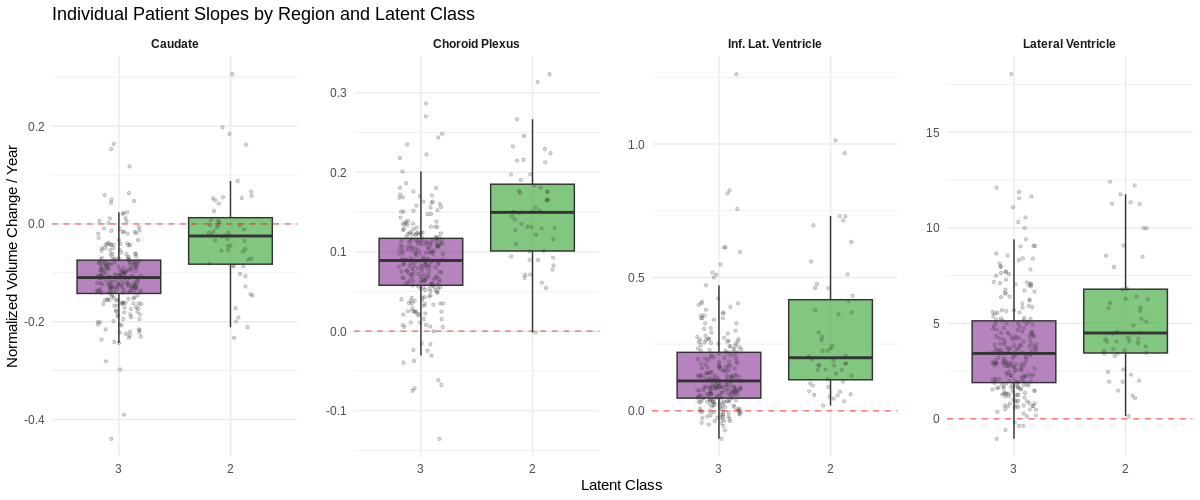

In [ ]:
%%R -w 1200 -h 500 -u px
library(ggplot2)
library(dplyr)

# Using the df_all_slopes dataframe already created in the previous cell
df_plot <- df_all_slopes %>%
  filter(class %in% c("2", "3"))

# Create faceted plot with free y-scales
ggplot(df_plot, aes(x = class, y = Total_Slope, fill = class)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +
  geom_jitter(alpha = 0.2, size = 1.2, color="#333333", width = 0.2) +
  facet_wrap(~Region, scales = "free_y", nrow = 1) +
  theme_minimal(base_size = 15) +
  labs(title = "Individual Patient Slopes by Region and Latent Class",
       y = "Normalized Volume Change / Year",
       x = "Latent Class",
       fill = "Latent Class") +
  scale_fill_manual(values = c("2" = "#4daf4a", "3" = "#984ea3")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", alpha = 0.5) +
  theme(legend.position = "none",
        panel.spacing = unit(2, "lines"),
        strip.text = element_text(face = "bold"))

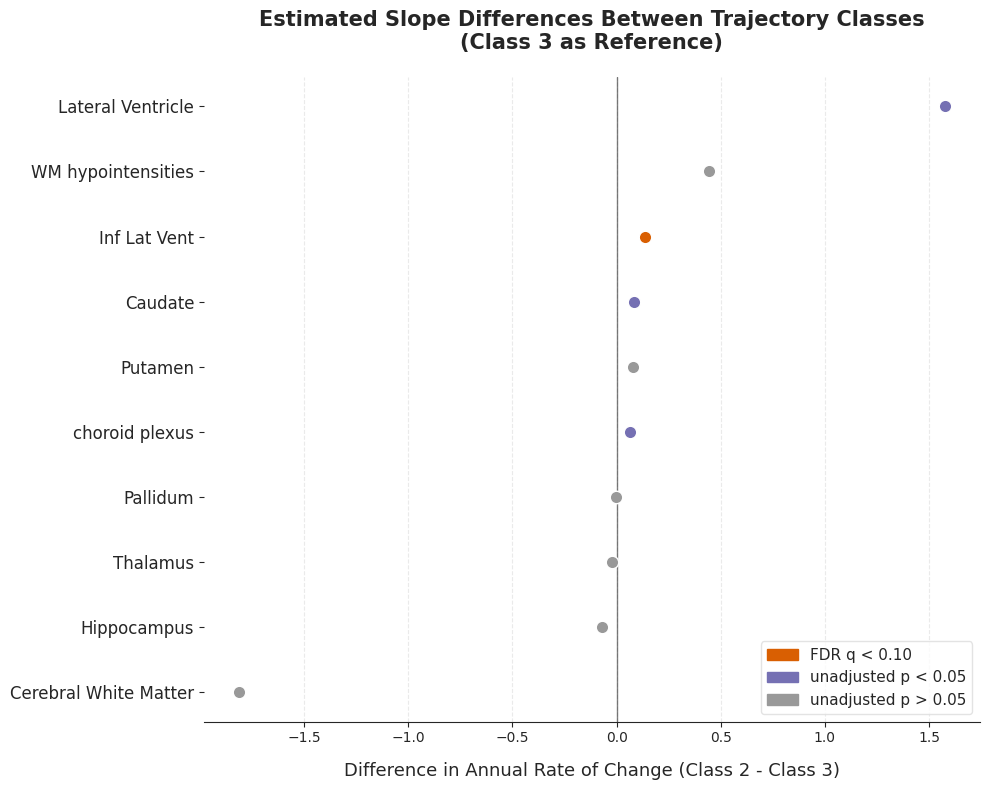

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Robust extraction of estimates and standard errors from R models
# We ensure SE extraction handles the internal structure of hlme objects correctly
ro.r("""
regions <- c('Thalamus', 'Caudate', 'Putamen', 'Hippocampus', 'choroid_plexus',
             'Pallidum', 'Lateral_Ventricle', 'Inf_Lat_Vent',
             'Cerebral_White_Matter', 'WM_hypointensities')

results <- data.frame(Region=character(), Estimate=numeric(), SE=numeric(), stringsAsFactors=FALSE)

for (reg in regions) {
  mod_name <- paste0("model_", reg)
  if (exists(mod_name)) {
    mod <- get(mod_name)
    # Extract coefficients and SEs from the variance-covariance matrix
    coefs <- mod$best
    ses <- sqrt(abs(diag(mod$V)))

    if ("class2:YEAR" %in% names(coefs)) {
        results <- rbind(results, data.frame(
            Region = reg,
            Estimate = as.numeric(coefs["class2:YEAR"]),
            SE = as.numeric(ses["class2:YEAR"]),
            stringsAsFactors = FALSE
        ))
    }
  }
}
""")

# Pull the results back to Python
with (ro.default_converter + ro.pandas2ri.converter).context():
    df_forest = ro.conversion.get_conversion().rpy2py(ro.r("results"))

# 2. Merge with p-values
df_forest = df_forest.merge(df_pvals_fdr[['Region', 'P_Class2_vs_3_YEAR', 'FDR_P_Class2']], on='Region', how='left')

# 3. Calculate 95% Confidence Intervals (1.96 * SE)
df_forest['CI_lower'] = df_forest['Estimate'] - 1.96 * df_forest['SE']
df_forest['CI_upper'] = df_forest['Estimate'] + 1.96 * df_forest['SE']

# Clean region names for display
df_forest['Region'] = df_forest['Region'].str.replace('_', ' ')
# Sort by effect size for a professional 'waterfall' presentation
df_forest = df_forest.sort_values('Estimate', ascending=True).reset_index(drop=True)

# 4. Professional Plotting
plt.figure(figsize=(10, 8))
sns.set_style("ticks")

# Define color palette
color_fdr = '#d95f02'   # Orange
color_unadj = '#7570b3' # Purple
color_ns = '#999999'    # Gray

colors = []
for _, row in df_forest.iterrows():
    if row['FDR_P_Class2'] < 0.10: colors.append(color_fdr)
    elif row['P_Class2_vs_3_YEAR'] < 0.05: colors.append(color_unadj)
    else: colors.append(color_ns)

for i, row in df_forest.iterrows():
    # Plot the 95% CI using errorbar for better visibility
    plt.errorbar(row['Estimate'], i, xerr=[[row['Estimate'] - row['CI_lower']], [row['CI_upper'] - row['Estimate']]],
                 fmt='o', color=colors[i], markersize=9, markeredgecolor='white', markeredgewidth=1, linewidth=2.5, capsize=5)

# Refined Formatting
plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.yticks(range(len(df_forest)), df_forest['Region'], fontsize=12, fontweight='medium')
plt.xlabel('Difference in Annual Rate of Change (Class 2 - Class 3)', fontsize=13, labelpad=12)
plt.title('Estimated Slope Differences Between Trajectory Classes\n(Class 3 as Reference)', fontsize=15, pad=20, fontweight='bold')

# Legend without stars
fdr_patch = mpatches.Patch(color=color_fdr, label='FDR q < 0.10')
unadj_patch = mpatches.Patch(color=color_unadj, label='unadjusted p < 0.05')
ns_patch = mpatches.Patch(color=color_ns, label='unadjusted p > 0.05')

plt.legend(handles=[fdr_patch, unadj_patch, ns_patch], loc='lower right',
           fontsize=11, frameon=True, facecolor='white', edgecolor='#dddddd')

sns.despine(left=True, bottom=False)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


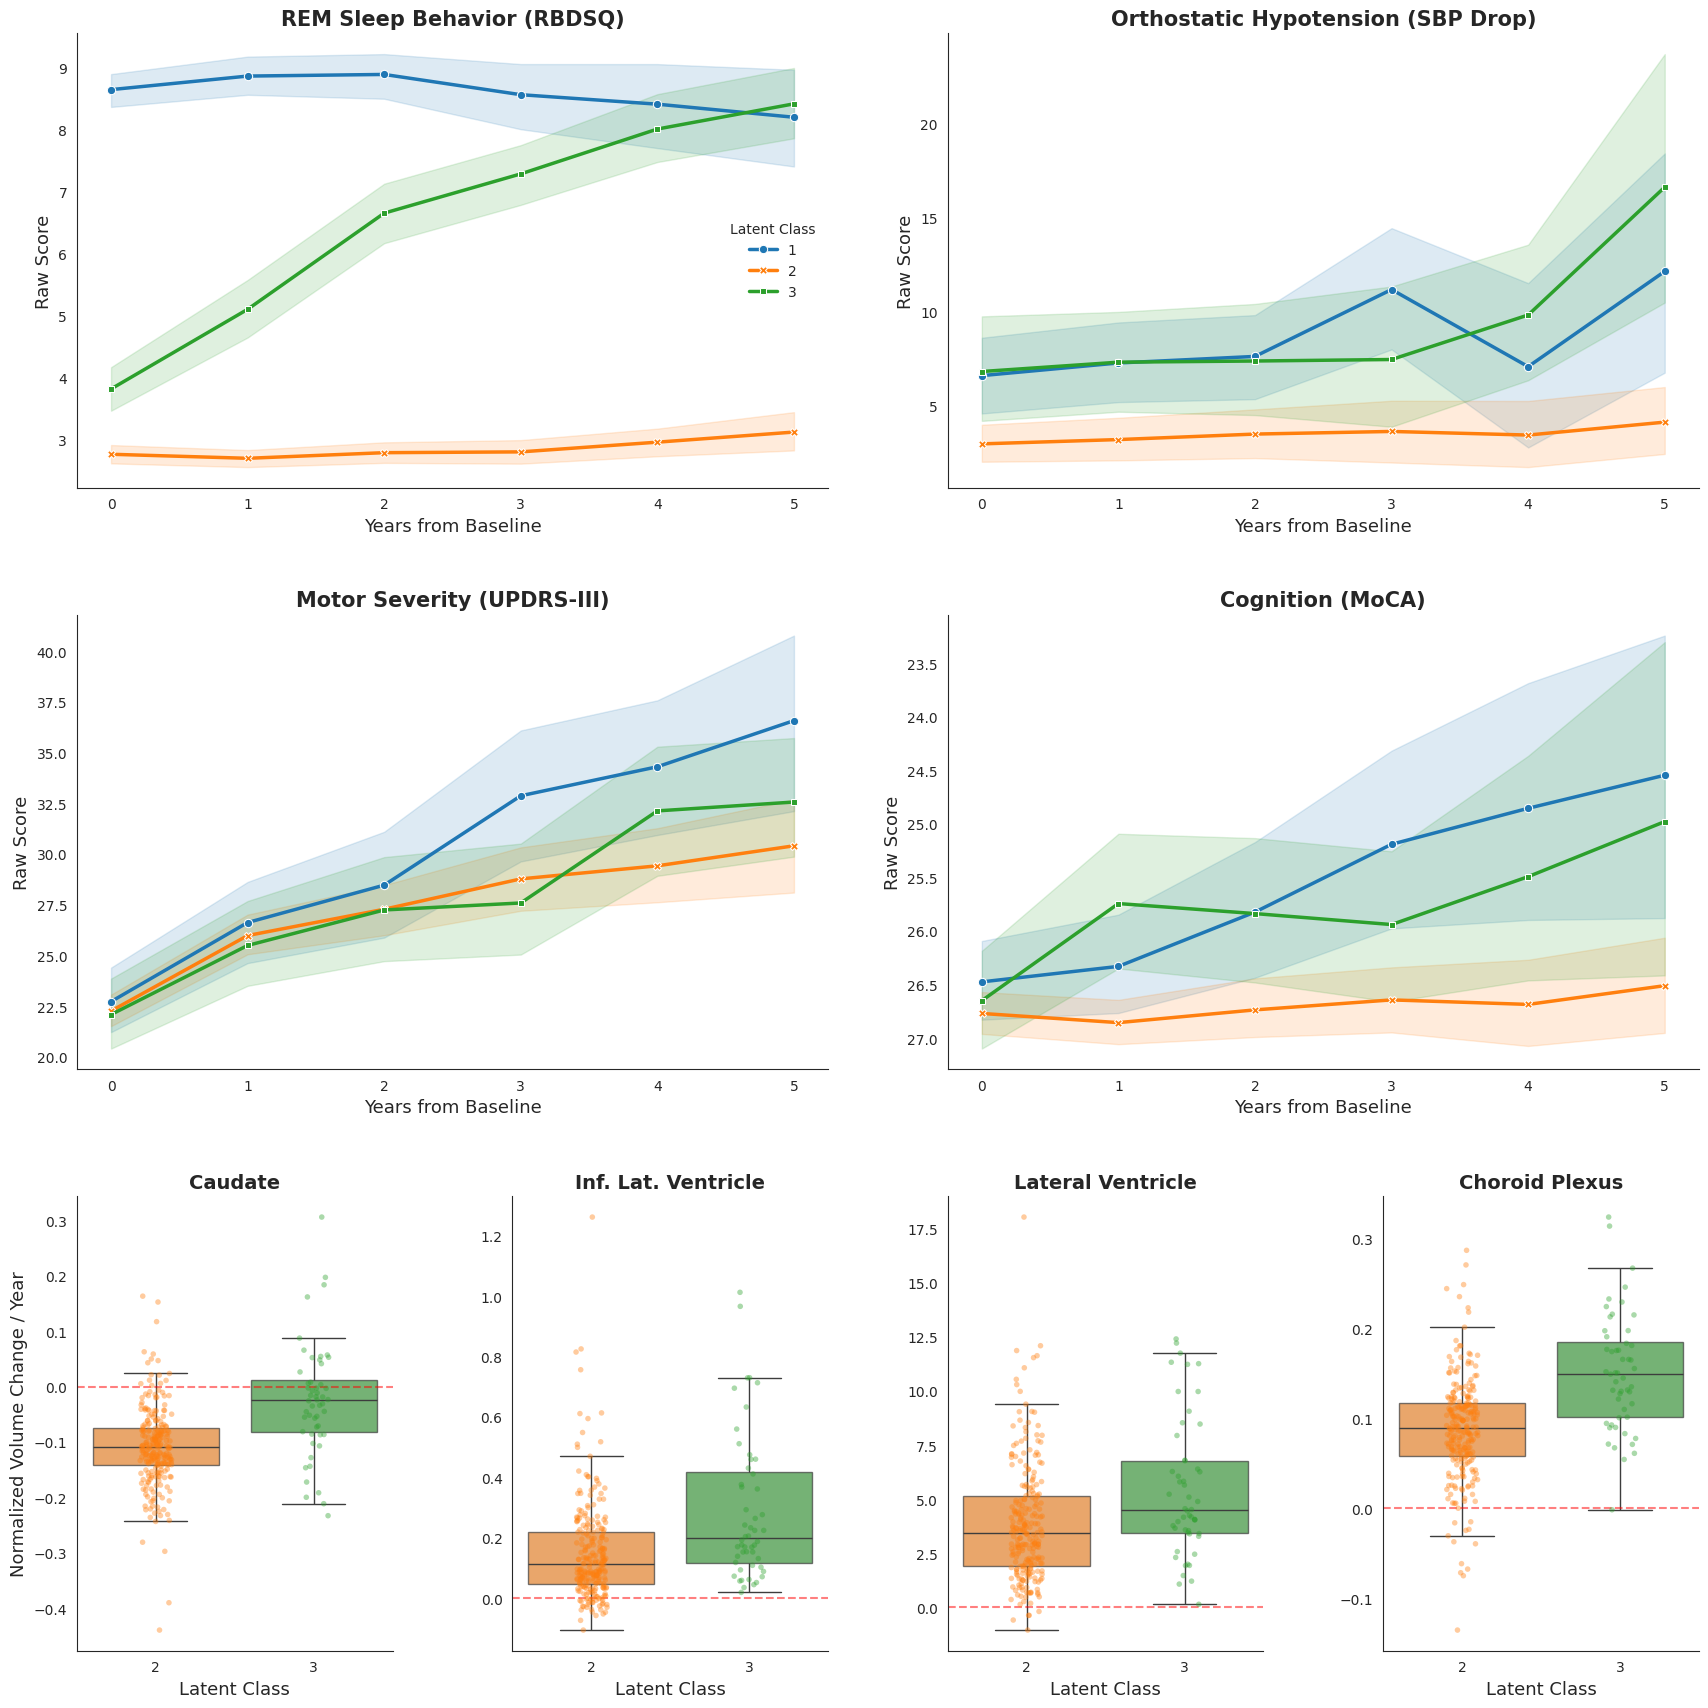

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Map classes back to unpermuted originals
# The permuted model used: c(1, 3, 2), which means:
# Permuted 1 -> Original 1
# Permuted 2 -> Original 3
# Permuted 3 -> Original 2 (Reference class)
class_map = {'1': '1', '2': '3', '3': '2'}

# 2. Prepare Clinical Data
clinical_vars_raw = {
    'rem': 'REM Sleep Behavior (RBDSQ)',
    'delta_sbp': 'Orthostatic Hypotension (SBP Drop)',
    'updrs3_score': 'Motor Severity (UPDRS-III)',
    'moca': 'Cognition (MoCA)'
}

# Extract class assignments from R
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

df_clinical_raw = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars_raw.keys())].copy()
df_clinical_raw = df_clinical_raw.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

df_clinical_plot = df_clinical_raw.copy()
df_clinical_plot['orig_class'] = df_clinical_plot['class'].astype(str).map(class_map)

# 3. Prepare Boxplot Data from R
with (ro.default_converter + ro.pandas2ri.converter).context():
    df_all_slopes = ro.conversion.get_conversion().rpy2py(ro.r("df_all_slopes"))

df_all_slopes['orig_class'] = df_all_slopes['class'].astype(str).map(class_map)

# Filter for the non-reference vs reference (Original Class 3 vs Original Class 2)
df_box_plot = df_all_slopes[df_all_slopes['orig_class'].isin(['2', '3'])].copy()

# 4. Setup Unified Figure
sns.set_style("white")
fig = plt.figure(figsize=(18, 18))
gs = fig.add_gridspec(3, 4)

ax1 = fig.add_subplot(gs[0, 0:2]) # REM
ax2 = fig.add_subplot(gs[0, 2:4]) # SBP
ax3 = fig.add_subplot(gs[1, 0:2]) # UPDRS3
ax4 = fig.add_subplot(gs[1, 2:4]) # MOCA

axes_clin = [ax1, ax2, ax3, ax4]

# Shared color palette mapped to original classes
base_palette = sns.color_palette("tab10", n_colors=3)
palette_dict = {'1': base_palette[0], '2': base_palette[1], '3': base_palette[2]}
hue_order = ['1', '2', '3']
box_hue_order = ['2', '3'] # This ensures 2 comes before 3

# --- A. Plot Clinical Trajectories ---
for i, (col, title) in enumerate(clinical_vars_raw.items()):
    ax = axes_clin[i]
    sns.lineplot(data=df_clinical_plot, x='YEAR', y=col, hue='orig_class', style='orig_class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette_dict,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=ax, legend=(i==0))

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel("Years from Baseline", fontsize=13)
    ax.set_ylabel("Raw Score", fontsize=13)
    ax.set_xticks([0, 1, 2, 3, 4, 5])

    if col == 'moca':
        ax.invert_yaxis()

    sns.despine(ax=ax)
    if i == 0:
        ax.legend(title='Latent Class', frameon=False)

# --- B. Plot Individual Slopes Boxplot ---
unique_regions = df_box_plot['Region'].unique()
axes_box = [fig.add_subplot(gs[2, i]) for i in range(len(unique_regions))]

for i, region in enumerate(unique_regions):
    ax = axes_box[i]
    df_region = df_box_plot[df_box_plot['Region'] == region]

    sns.boxplot(data=df_region, x='orig_class', y='Total_Slope', hue='orig_class',
                palette=palette_dict, hue_order=box_hue_order, order=box_hue_order, ax=ax,
                boxprops={'alpha': 0.7}, showfliers=False)

    sns.stripplot(data=df_region, x='orig_class', y='Total_Slope', hue='orig_class',
                  palette=palette_dict, hue_order=box_hue_order, order=box_hue_order,
                  dodge=False, alpha=0.4, size=4, ax=ax)

    ax.set_title(region, fontsize=14, fontweight='bold')
    ax.set_xlabel("Latent Class", fontsize=13)
    if i == 0:
        ax.set_ylabel("Normalized Volume Change / Year", fontsize=13)
    else:
        ax.set_ylabel("")

    ax.axhline(0, ls='--', color='red', alpha=0.5)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    sns.despine(ax=ax)

plt.tight_layout(pad=4.0)
plt.show()

# Linear Link Model with z-scored indicators (final version)

## Model Loading and Permutation

In [ ]:
model_path = "/content/drive/MyDrive/data/m3_rmus_intercept_z_bl_trans_linear.rds"

ro.r(f'm3_rmus_intercept_z_bl_trans_linear <- readRDS("{model_path}")')

m3_rmus_intercept_z_bl_trans_linear = ro.globalenv['m3_rmus_intercept_z_bl_trans_linear']

In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
vars_to_z = ["rem", "trans_moca", "updrs3_score", "delta_sbp"]

base = df_pd_final[df_pd_final["YEAR"] == 0]

mu_base = base[vars_to_z].mean()
sd_base = base[vars_to_z].std()

df_pd_final[["z_bl_" + v for v in vars_to_z]] = (df_pd_final[vars_to_z] - mu_base) / sd_base

In [ ]:
df_pd_final.filter(like="z_bl_").describe()

In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r('''
library(lcmm)
m3_rmus_intercept_z_bl_trans_linear_ref2 = permut(m3_rmus_intercept_z_bl_trans_linear, c(1, 3, 2))
postprob(m3_rmus_intercept_z_bl_trans_linear_ref2)
''')

 
Posterior classification: 
  class1 class2 class3
N 173.00 114.00 568.00
%  20.23  13.33  66.43
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2  prob3
class1 0.8684 0.0917 0.0400
class2 0.0894 0.7868 0.1238
class3 0.0080 0.0699 0.9221
 
Posterior probaBIlities above a threshold (%): 
         class1 class2 class3
prob>0.7  83.24  69.30  92.25
prob>0.8  75.72  54.39  85.92
prob>0.9  61.27  39.47  74.82
 


## Adding CSFSAA

In [ ]:
import rpy2.robjects as ro
import pandas as pd

# 1. Re-construct df_extended_240
df_subset_240_longitudinal = df_pd_final[df_pd_final['PATNO'].isin(biomarker_complete_patnos)].copy()
df_baseline_biomarkers = df_overlap.rename(columns={col: f'{col}_bl' for col in df_overlap.columns if col not in ['PATNO', 'EVENT_ID', 'YEAR']}).copy()
df_baseline_biomarkers = df_baseline_biomarkers[['PATNO'] + [col for col in df_baseline_biomarkers.columns if col.endswith('_bl')]].drop_duplicates(subset=['PATNO'])

df_extended_240 = df_subset_240_longitudinal.merge(
    df_baseline_biomarkers,
    on='PATNO',
    how='left',
    validate='many_to_one'
)

# 2. Binarize the existing baseline CSFSAA column (1 = LBD-like, 0 = other)
df_saa_full = df_extended_240.copy()
df_saa_full['CSFSAA_bl'] = df_saa_full['CSFSAA_bl'].apply(lambda x: 1.0 if x == 1.0 else 0.0)

# 3. Define the extended predictors
non_imaging_preds_saa = [
    "SEX", "EDUCYRS", "age", "asyn_bl", "ptau_bl", "abeta_bl",
    "upsit_bl", "nfl_serum_bl", "MIA_CAUDATE_BILAT_bl", "MIA_PUTAMEN_BILAT_bl",
    "APOE_e4_bl", "CSFSAA_bl"
]

# 4. Filter for complete cases on all predictors
df_saa_full = df_saa_full.dropna(subset=non_imaging_preds_saa).copy()

# 5. Consolidate APOE (1 and 2 become 1 - Carrier)
df_saa_full['APOE_e4_bl'] = df_saa_full['APOE_e4_bl'].replace({2.0: 1.0})

# 6. Push to R and configure factors (Using RAW values, no z-scoring)
ro.globalenv["df_saa_full"] = df_saa_full

ro.r("""
library(lcmm)
df_saa_full$TP <- factor(df_saa_full$YEAR)
df_saa_full$SEX <- factor(df_saa_full$SEX)
df_saa_full$APOE_e4_bl <- factor(df_saa_full$APOE_e4_bl)
df_saa_full$CSFSAA_bl <- factor(df_saa_full$CSFSAA_bl)
""")

print(f"Non-Imaging cohort size with CSFSAA: {df_saa_full['PATNO'].nunique()} subjects")

Non-Imaging cohort size with CSFSAA: 240 subjects


In [ ]:
# 1. Construct the formula string for the non-imaging predictors including CSFSAA
non_imaging_preds_saa = [
    "SEX", "EDUCYRS", "age", "asyn_bl", "ptau_bl", "abeta_bl",
    "upsit_bl", "nfl_serum_bl", "MIA_CAUDATE_BILAT_bl", "MIA_PUTAMEN_BILAT_bl",
    "APOE_e4_bl", "CSFSAA_bl"
]
formula_saa = " ~ " + " + ".join(non_imaging_preds_saa)

print(f"--- Running Non-Imaging 3-Class Model with Raw Values and CSF-SAA (N=240) ---")

# 2. Execute externVar in R using the reference model
ro.r(f"""
library(lcmm)

# Run the secondary multinomial logistic regression
m3_ni_saa_model = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                            classmb = {formula_saa},
                            subject = 'PATNO',
                            data = df_saa_full,
                            method = 'twoStageJoint',
                            maxiter = 100)

# Display the summary
summary_saa <- summary(m3_ni_saa_model)
print(summary_saa)
""")

--- Running Non-Imaging 3-Class Model with Raw Values and CSF-SAA (N=240) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + asyn_bl + ptau_bl + abeta_bl + 
        upsit_bl + nfl_serum_bl + MIA_CAUDATE_BILAT_bl + MIA_PUTAMEN_BILAT_bl + 
        APOE_e4_bl + CSFSAA_bl, data = df_saa_full, method = "twoStageJoint", 
    maxiter = 100)
 
Statistical Model: 
     Dataset: df_saa_full 
     Number of subjects: 240 
     Number of latent classes: 3 
     Number of parameters: 26  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  72 
     Convergence criteria: parameters= 9e-05 
                         : likelihood= 4.8e-07 
                         : second derivatives= 2.7e-06 
 
Goodness-of-fit s

In [ ]:
# 1. Identify all PD subjects with baseline CSF-SAA and demographics
saa_data_full = df_curated[
    (df_curated['PATNO'].isin(df_pd_final['PATNO'].unique())) &
    (df_curated['YEAR'] == 0)
][['PATNO', 'SEX', 'EDUCYRS', 'age', 'CSFSAA']].copy()

# 2. Binarize SAA (1.0 = Positive, 0.0 = Negative/Other)
saa_data_full['CSFSAA_bl'] = saa_data_full['CSFSAA'].apply(lambda x: 1.0 if x == 1.0 else 0.0)

# 3. Drop rows missing predictors (Demographics are usually complete, but checking SAA)
saa_data_full = saa_data_full.dropna(subset=['SEX', 'EDUCYRS', 'age', 'CSFSAA'])

print(f"Total unique subjects with baseline CSF-SAA and demographics: {saa_data_full['PATNO'].nunique()}")
display(saa_data_full['CSFSAA'].value_counts(dropna=False))

# 4. Prepare the expanded dataframe for R
# We merge with the longitudinal clinical data to ensure the model has the trajectory context
df_saa_expanded = df_pd_final.merge(
    saa_data_full[['PATNO', 'CSFSAA_bl']],
    on='PATNO',
    how='inner'
)

import rpy2.robjects as ro
ro.globalenv['df_saa_expanded'] = df_saa_expanded

Total unique subjects with baseline CSF-SAA and demographics: 796


,count
CSFSAA,
1.0,707
0.0,75
3.0,8
2.0,6


In [ ]:
ro.r("""
library(lcmm)
df_saa_expanded$SEX <- factor(df_saa_expanded$SEX)
df_saa_expanded$CSFSAA_bl <- factor(df_saa_expanded$CSFSAA_bl)
df_saa_expanded$TP <- factor(df_saa_expanded$YEAR)

cat("--- Running Expanded 3-Class Model: Demographics + CSF-SAA ---\n")
m3_saa_isolated = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                            classmb = ~ SEX + EDUCYRS + age + CSFSAA_bl,
                            subject = 'PATNO',
                            data = df_saa_expanded,
                            method = 'twoStageJoint',
                            maxiter = 100)

print(summary(m3_saa_isolated))
""")

--- Running Expanded 3-Class Model: Demographics + CSF-SAA ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age + CSFSAA_bl, data = df_saa_expanded, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_saa_expanded 
     Number of subjects: 796 
     Number of latent classes: 3 
     Number of parameters: 10  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  17 
     Convergence criteria: parameters= 2.5e-07 
                         : likelihood= 5.3e-07 
                         : second derivatives= 1.6e-08 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -17230.32  
     AIC: 34480.64  
     BIC: 34527.44  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import rpy2.robjects as ro

# 1. Extract class assignments directly from the reference model
with (ro.default_converter + ro.pandas2ri.converter).context():
    pprob_df = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))

df_classes = pprob_df[['PATNO', 'class']].copy()
df_classes['PATNO'] = df_classes['PATNO'].astype(int)

# 2. Filter dataframes to BASELINE only and merge with classes
# For the N=240 subset
df_240_bl = df_saa_full[df_saa_full['YEAR'] == 0].merge(df_classes, on='PATNO', how='inner')

# For the full N=796 cohort
df_796_bl = df_saa_expanded[df_saa_expanded['YEAR'] == 0].merge(df_classes, on='PATNO', how='inner')

print(f"--- CSF-SAA Frequencies per Class (Baseline N={len(df_240_bl)} subset) ---")
print("0.0 = Negative/Other, 1.0 = LBD-like (Positive)")
display(pd.crosstab(df_240_bl['class'], df_240_bl['CSFSAA_bl'], margins=True))

print(f"\n--- CSF-SAA Frequencies per Class (Baseline N={len(df_796_bl)} full cohort) ---")
display(pd.crosstab(df_796_bl['class'], df_796_bl['CSFSAA_bl'], margins=True))

# 3. Correlation check between continuous asyn and binarized CSF-SAA (N=240 Baseline)
asyn_vals = df_240_bl['asyn_bl'].astype(float)
saa_vals = df_240_bl['CSFSAA_bl'].astype(float)

# Point-biserial correlation
corr, p_val = stats.pointbiserialr(saa_vals, asyn_vals)
print(f"\n--- Correlation between asyn_bl and CSFSAA_bl (Baseline N={len(df_240_bl)}) ---")
print(f"Point-Biserial Correlation: {corr:.4f}, p-value: {p_val:.4e}")

# Spearman rank correlation
spearman_corr, spearman_p = stats.spearmanr(saa_vals, asyn_vals)
print(f"Spearman Correlation:       {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

--- CSF-SAA Frequencies per Class (Baseline N=240 subset) ---
0.0 = Negative/Other, 1.0 = LBD-like (Positive)


CSFSAA_bl,0.0,1.0,All
class,,,
1,7,31,38
2,1,43,44
3,18,140,158
All,26,214,240



--- CSF-SAA Frequencies per Class (Baseline N=796 full cohort) ---


CSFSAA_bl,0.0,1.0,All
class,,,
1,14,145,159
2,5,104,109
3,70,458,528
All,89,707,796



--- Correlation between asyn_bl and CSFSAA_bl (Baseline N=240) ---
Point-Biserial Correlation: 0.0448, p-value: 4.8975e-01
Spearman Correlation:       0.0561, p-value: 3.8677e-01


In [ ]:
import pandas as pd

# 1. Define the specific variables requested
# MIA_CAUDATE_BILAT and MIA_PUTAMEN_BILAT are the two primary DATscan variables
target_overlap_vars = ['CSFSAA', 'MIA_CAUDATE_BILAT', 'MIA_PUTAMEN_BILAT', 'APOE_e4', 'upsit']

# 2. Filter df_biomarkers for baseline (YEAR 0)
df_bl_overlap = df_biomarkers[df_biomarkers['YEAR'] == 0].copy()

# 3. Drop rows with missing values in the target variables
df_final_overlap = df_bl_overlap.dropna(subset=target_overlap_vars)

# 4. Report results
num_overlap = df_final_overlap['PATNO'].nunique()
print(f"--- Overlap Analysis ---")
print(f"Variables: {', '.join(target_overlap_vars)}")
print(f"Number of unique subjects with complete baseline data: {num_overlap}")

# Show the first few subjects in the overlap
display(df_final_overlap[['PATNO'] + target_overlap_vars].head())

In [ ]:
import rpy2.robjects as ro
import pandas as pd

# 1. Start with the subjects identified in the N=731 overlap (df_final_overlap)
# This includes: CSFSAA, MIA_CAUDATE_BILAT, MIA_PUTAMEN_BILAT, APOE_e4, upsit
target_ids = df_final_overlap['PATNO'].unique()

# 2. Get the full longitudinal context for these 731 subjects from df_pd_final
# We need the 'z_bl' variables and YEAR/TP for externVar to function
df_731_logistic = df_pd_final[df_pd_final['PATNO'].isin(target_ids)].copy()

# 3. Merge in the baseline biomarker predictors from df_final_overlap
# We rename them to clarify they are baseline predictors
preds_to_merge = df_final_overlap[['PATNO', 'CSFSAA', 'MIA_CAUDATE_BILAT', 'MIA_PUTAMEN_BILAT', 'APOE_e4', 'upsit']].copy()
preds_to_merge.columns = ['PATNO', 'CSFSAA_bl', 'MIA_CAUDATE_BILAT_bl', 'MIA_PUTAMEN_BILAT_bl', 'APOE_e4_bl', 'upsit_bl']

df_731_logistic = df_731_logistic.merge(preds_to_merge, on='PATNO', how='inner')

# 4. Clean and Prepare Variables
# Binarize SAA: 1 = Positive, 0 = Negative/Other
df_731_logistic['CSFSAA_bl'] = df_731_logistic['CSFSAA_bl'].apply(lambda x: 1.0 if x == 1.0 else 0.0)

# Consolidate APOE: 0 = non-carrier, 1 = carrier (1 or 2 alleles)
df_731_logistic['APOE_e4_bl'] = df_731_logistic['APOE_e4_bl'].replace({2.0: 1.0})

# Scale DATscan (OR per 0.1 change)
df_731_logistic['MIA_CAUDATE_BILAT_bl'] = df_731_logistic['MIA_CAUDATE_BILAT_bl'] * 10.0
df_731_logistic['MIA_PUTAMEN_BILAT_bl'] = df_731_logistic['MIA_PUTAMEN_BILAT_bl'] * 10.0

# 5. Push to R and Configure Factors
ro.globalenv['df_731_logistic'] = df_731_logistic
ro.r("""
library(lcmm)
df_731_logistic$SEX <- factor(df_731_logistic$SEX)
df_731_logistic$APOE_e4_bl <- factor(df_731_logistic$APOE_e4_bl)
df_731_logistic$CSFSAA_bl <- factor(df_731_logistic$CSFSAA_bl)
df_731_logistic$TP <- factor(df_731_logistic$YEAR)
""")

print(f"Data prepared for logistic regression: {df_731_logistic['PATNO'].nunique()} unique subjects.")
print(f"Total longitudinal rows: {len(df_731_logistic)}")
display(df_731_logistic[['PATNO', 'YEAR', 'CSFSAA_bl', 'MIA_PUTAMEN_BILAT_bl', 'z_bl_rem']].head())

In [ ]:
display(df_731_logistic)

In [ ]:
import rpy2.robjects as ro

# 1. Define the formula and ensure all required variables are present
logistic_preds = ['SEX', 'EDUCYRS', 'age', 'CSFSAA_bl', 'MIA_CAUDATE_BILAT_bl', 'MIA_PUTAMEN_BILAT_bl', 'APOE_e4_bl', 'upsit_bl']
classmb_formula = " ~ " + " + ".join(logistic_preds)

# Ensure the R environment has the correct dataframe and formula
ro.globalenv['df_731_logistic'] = df_731_logistic
ro.globalenv['classmb_formula_str'] = classmb_formula

ro.r("""
library(lcmm)
# Configure factors for the regression
df_731_logistic$SEX <- factor(df_731_logistic$SEX)
df_731_logistic$APOE_e4_bl <- factor(df_731_logistic$APOE_e4_bl)
df_731_logistic$CSFSAA_bl <- factor(df_731_logistic$CSFSAA_bl)
df_731_logistic$TP <- factor(df_731_logistic$YEAR)

cat("--- Running Logistic Regression (N=731) ---\n")
# Execute externVar using the 3-class linear model with Class 2 as reference
m3_logistic_731 = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                            classmb = as.formula(classmb_formula_str),
                            subject = 'PATNO',
                            data = df_731_logistic,
                            method = 'twoStageJoint',
                            maxiter = 100)

print(summary(m3_logistic_731))
""")

--- Running Logistic Regression (N=731) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = as.formula(classmb_formula_str), data = df_731_logistic, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_731_logistic 
     Number of subjects: 731 
     Number of latent classes: 3 
     Number of parameters: 18  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  12 
     Convergence criteria: parameters= 8.3e-05 
                         : likelihood= 3.6e-05 
                         : second derivatives= 2.4e-08 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -16139.72  
     AIC: 32315.43  
     BIC: 32398.13  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the clas

## MRI Regions Associated with RBD

In [ ]:
import rpy2.robjects as ro

# 1. Define predictors & subset data for the 474 MRI subjects
mri_feat_cols = [
    'Thalamus_vol', 'Putamen_vol', 'Caudate_vol', 'Pallidum_vol',
    'insula_cth', 'Amygdala_vol', 'Hippocampus_vol',
    'inferiortemporal_cth', 'parahippocampal_cth', 'posteriorcingulate_cth',
    'superiorparietal_cth', 'rostralmiddlefrontal_cth', 'caudalmiddlefrontal_cth',
    'caudalanteriorcingulate_cth', 'rostralanteriorcingulate_cth',
    'Lateral_Ventricle_vol', 'choroid_plexus_vol'
]

# Inner merge automatically filters to the 474 subjects with integrated MRI data
df_mri_logistic = df_pd_final.merge(df_mri_integrated[['PATNO'] + mri_feat_cols], on='PATNO', how='inner')

# 2. Scale MRI features based on suffix
for c in mri_feat_cols:
    if c.endswith('_vol'):
        df_mri_logistic[c] *= 1000
    elif c.endswith('_cth'):
        df_mri_logistic[c] *= 10

# 3. Push to R
ro.globalenv['df_mri_logistic'] = df_mri_logistic
ro.globalenv['classmb_formula_str'] = " ~ SEX + EDUCYRS + age + " + " + ".join(mri_feat_cols)

ro.r("""
library(lcmm)
df_mri_logistic$SEX <- factor(df_mri_logistic$SEX)
df_mri_logistic$TP <- factor(df_mri_logistic$YEAR)
""")

print(f"Data Prepared: N={df_mri_logistic['PATNO'].nunique()} subjects. Predictors: {len(mri_feat_cols)+3}")

Data Prepared: N=474 subjects. Predictors: 20


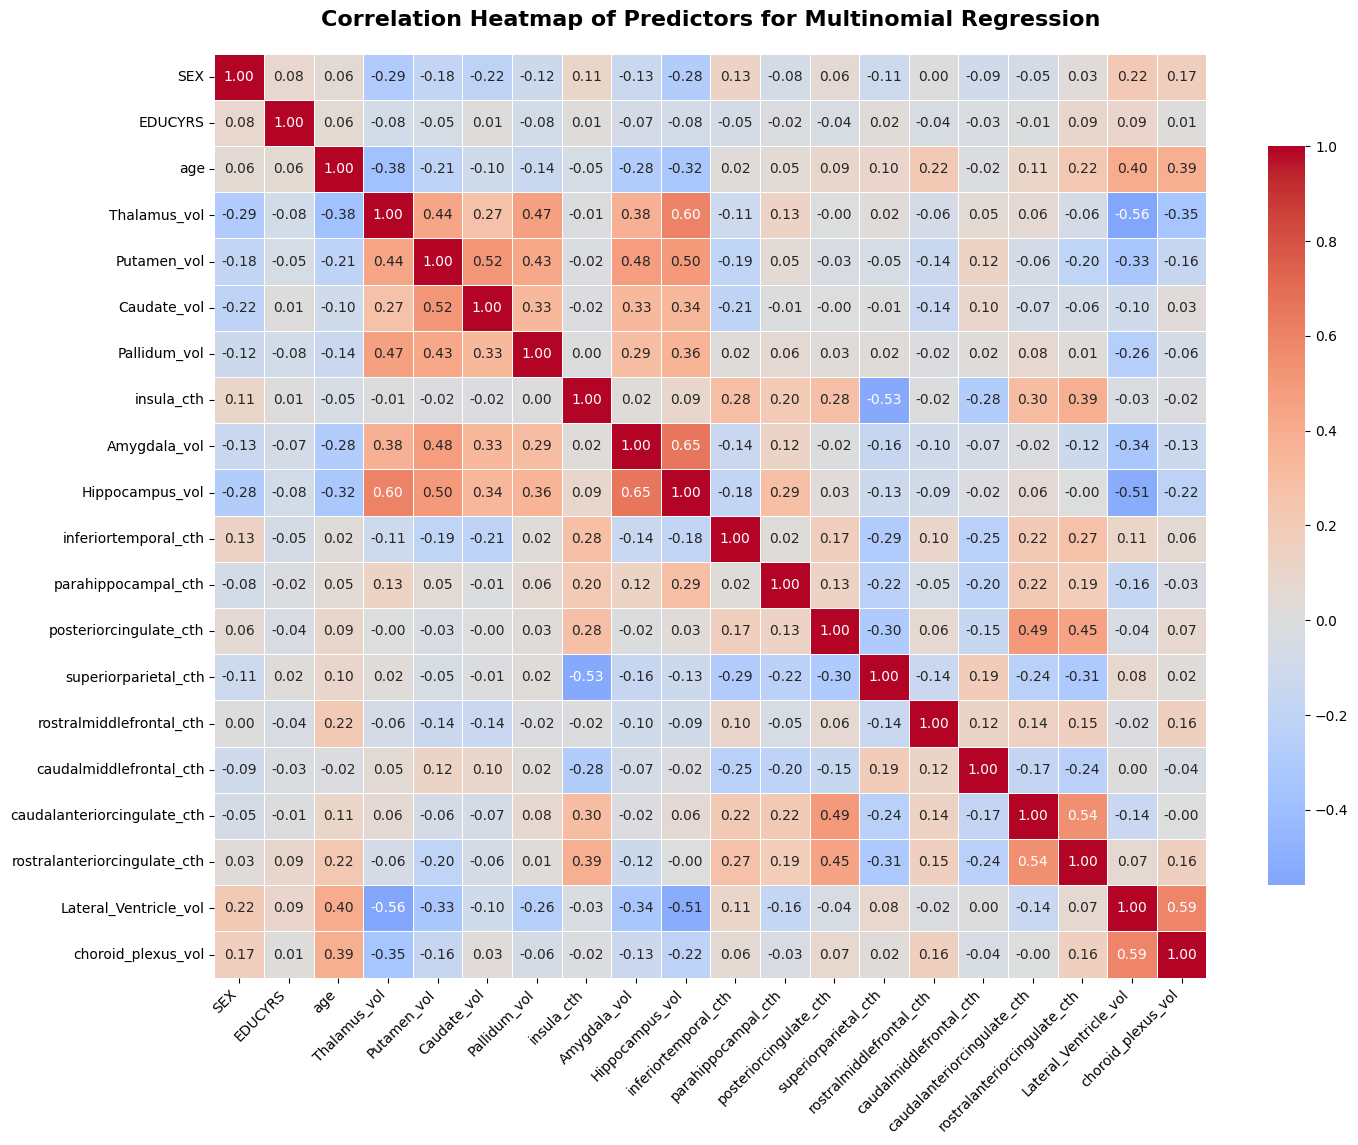

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the 20 variables to check (3 demographics + 17 MRI features)
corr_vars = ['SEX', 'EDUCYRS', 'age'] + mri_feat_cols

# 2. Calculate the Spearman correlation matrix
# Spearman is used to better handle the categorical SEX variable and any non-linear relationships
corr_matrix = df_mri_logistic[corr_vars].corr(method='spearman')

# 3. Plot the Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=.5, cbar_kws={'shrink': .8})

plt.title('Correlation Heatmap of Predictors for Multinomial Regression', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

# Installing 'car' for VIF calculation; this may take several minutes.
packages = ["car"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)































	‘/tmp/RtmpJvvotD/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7bb176ce6150> [0]

In [ ]:
import rpy2.robjects as ro

# Run VIF calculation using a dummy linear model to check for multicollinearity among the 20 predictors
ro.r("""
library(car)

# Construct formula from the 20 predictors defined in classmb_formula_str
# We use a dummy outcome (rnorm) because VIF only depends on the predictors
vif_formula <- as.formula(paste("rnorm(nrow(df_mri_logistic))", classmb_formula_str))

dummy_model <- lm(vif_formula, data = df_mri_logistic)

vif_results <- vif(dummy_model)
print("--- Variance Inflation Factors (VIF) ---")
print(sort(vif_results, decreasing = TRUE))
""")

[1] "--- Variance Inflation Factors (VIF) ---"
             Hippocampus_vol rostralanteriorcingulate_cth 
                    3.140538                     2.366695 
                Thalamus_vol        Lateral_Ventricle_vol 
                    2.259328                     2.235267 
                Amygdala_vol                   insula_cth 
                    2.231129                     2.132931 
                 Putamen_vol         superiorparietal_cth 
                    2.116756                     2.116194 
 caudalanteriorcingulate_cth           choroid_plexus_vol 
                    1.993593                     1.840682 
      posteriorcingulate_cth                  Caudate_vol 
                    1.832552                     1.675376 
                Pallidum_vol                          age 
                    1.526940                     1.498786 
        inferiortemporal_cth     rostralmiddlefrontal_cth 
                    1.385633                     1.312230 
         

In [ ]:
import pandas as pd

# Define the 20 predictors (3 demographic + 17 MRI-based)
demographic_vars = ['SEX', 'EDUCYRS', 'age']
all_20_vars = demographic_vars + mri_feat_cols

# Calculate summary statistics for the dataframe used in the logistic regression
summary_stats = df_mri_logistic[all_20_vars].describe().T
summary_stats = summary_stats[['mean', 'std', 'min', 'max']]

print("--- Summary Statistics of the 20 Predictors ---")
display(summary_stats)

# Calculate the scale ratio for inspection
print(f"\nMax SD: {summary_stats['std'].max():.4f}")
print(f"Min SD: {summary_stats['std'].min():.4f}")
print(f"Ratio (Max/Min SD): {summary_stats['std'].max() / summary_stats['std'].min():.2f}x")

--- Summary Statistics of the 20 Predictors ---


,mean,std,min,max
SEX,0.662138,0.473089,0.000000,1.000000
EDUCYRS,15.912138,2.714554,5.000000,20.000000
age,65.112154,7.129808,51.408219,84.534247
Thalamus_vol,4.502349,0.503918,2.841442,6.223783
Putamen_vol,2.813328,0.367450,1.814695,4.813853
Caudate_vol,2.113467,0.298484,0.888613,3.240252
Pallidum_vol,1.258262,0.149568,0.758217,1.870675
insula_cth,12.336400,0.760053,8.159516,14.822229
Amygdala_vol,1.054761,0.162477,0.536328,2.091688
Hippocampus_vol,2.611586,0.320773,1.572737,3.789718



Max SD: 7.1298
Min SD: 0.1455
Ratio (Max/Min SD): 49.01x


In [ ]:
import rpy2.robjects as ro

# Run the final multinomial logistic regression using externVar
# Interest is focused on the significance of the 20 predictors, especially choroid plexus.
ro.r("""
cat("--- Executing Final Multinomial Logistic Regression ---\n")
final_mri_externVar_model = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                                      classmb = as.formula(classmb_formula_str),
                                      subject = 'PATNO',
                                      data = df_mri_logistic,
                                      method = 'twoStageJoint',
                                      maxiter = 100)

print(summary(final_mri_externVar_model))
""")

--- Executing Final Multinomial Logistic Regression ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = as.formula(classmb_formula_str), data = df_mri_logistic, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_mri_logistic 
     Number of subjects: 474 
     Number of latent classes: 3 
     Number of parameters: 42  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 0.034 
                         : likelihood= 0.31 
                         : second derivatives= 1 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -11803.05  
     AIC: 23690.09  
     BIC: 23864.86  
 
 
 
Maximum Likelihood Estimates: 


35 mins, no convergence

In [ ]:
import rpy2.robjects as ro

# 1. Define the updated MRI features (15 total after consolidation)
mri_feat_cols = [
    'Thalamus_vol', 'Putamen_vol', 'Caudate_vol', 'Pallidum_vol',
    'insula_cth', 'Amygdala_vol', 'Hippocampus_vol',
    'inferiortemporal_cth', 'parahippocampal_cth', 'posteriorcingulate_cth',
    'superiorparietal_cth', 'middlefrontal_cth', 'anteriorcingulate_cth',
    'Lateral_Ventricle_vol', 'choroid_plexus_vol'
]

# 2. Consolidate variables: Sum rostral and caudal into new columns
# Anterior Cingulate
df_mri_logistic['anteriorcingulate_cth'] = df_mri_logistic['rostralanteriorcingulate_cth'] + df_mri_logistic['caudalanteriorcingulate_cth']

# Middle Frontal
df_mri_logistic['middlefrontal_cth'] = df_mri_logistic['rostralmiddlefrontal_cth'] + df_mri_logistic['caudalmiddlefrontal_cth']

# 3. Update R environment with new columns and formula
ro.globalenv['df_mri_logistic'] = df_mri_logistic
ro.globalenv['classmb_formula_str'] = " ~ SEX + EDUCYRS + age + " + " + ".join(mri_feat_cols)

print(f"Data Prepared with 18 Predictors (3 Demographic + 15 MRI).")
print(f"Consolidated 'anteriorcingulate_cth' and 'middlefrontal_cth' created.")

Data Prepared with 18 Predictors (3 Demographic + 15 MRI).
Consolidated 'anteriorcingulate_cth' and 'middlefrontal_cth' created.


In [ ]:
import rpy2.robjects as ro

# Run the final multinomial logistic regression using externVar with 18 predictors
ro.r("""
cat("--- Executing Final Multinomial Logistic Regression ---\n")
final_mri_externVar_model = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                                      classmb = as.formula(classmb_formula_str),
                                      subject = 'PATNO',
                                      data = df_mri_logistic,
                                      method = 'twoStageJoint',
                                      maxiter = 100)

print(summary(final_mri_externVar_model))
""")

--- Executing Final Multinomial Logistic Regression ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = as.formula(classmb_formula_str), data = df_mri_logistic, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_mri_logistic 
     Number of subjects: 474 
     Number of latent classes: 3 
     Number of parameters: 38  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 0.00047 
                         : likelihood= 0.095 
                         : second derivatives= 1 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -11811.87  
     AIC: 23699.74  
     BIC: 23857.86  
 
 
 
Maximum Likelihood Estimates

27 mins, still no convergence

In [ ]:
import rpy2.robjects as ro

# 1. Update the MRI feature list by dropping Lateral Ventricle and Choroid Plexus (13 total MRI features)
mri_feat_cols_16 = [
    'Thalamus_vol', 'Putamen_vol', 'Caudate_vol', 'Pallidum_vol',
    'insula_cth', 'Amygdala_vol', 'Hippocampus_vol',
    'inferiortemporal_cth', 'parahippocampal_cth', 'posteriorcingulate_cth',
    'superiorparietal_cth', 'middlefrontal_cth', 'anteriorcingulate_cth'
]

# 2. Update the R environment with the revised formula
ro.globalenv['classmb_formula_str'] = " ~ SEX + EDUCYRS + age + " + " + ".join(mri_feat_cols_16)

# 3. Execute the multinomial logistic regression in R
ro.r("""
cat("--- Executing Multinomial Logistic Regression with 16 Predictors ---\n")
final_mri_externVar_model = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                                      classmb = as.formula(classmb_formula_str),
                                      subject = 'PATNO',
                                      data = df_mri_logistic,
                                      method = 'twoStageJoint',
                                      maxiter = 100)

print(summary(final_mri_externVar_model))
""")

--- Executing Multinomial Logistic Regression with 16 Predictors ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = as.formula(classmb_formula_str), data = df_mri_logistic, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_mri_logistic 
     Number of subjects: 474 
     Number of latent classes: 3 
     Number of parameters: 34  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 0.001 
                         : likelihood= 0.037 
                         : second derivatives= 0.03 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -11806.61  
     AIC: 23681.21  
     BIC: 23822.69  
 
 
 
Maximum Likeli

Still not convergent

In [ ]:
import rpy2.robjects as ro

# 1. Update the MRI feature list by dropping Lateral Ventricle and Choroid Plexus (13 total MRI features)
mri_feat_cols_16 = [
    'Thalamus_vol', 'Putamen_vol', 'Caudate_vol', 'Pallidum_vol',
    'insula_cth', 'Amygdala_vol', 'Hippocampus_vol',
    'inferiortemporal_cth', 'parahippocampal_cth', 'posteriorcingulate_cth',
    'superiorparietal_cth', 'middlefrontal_cth', 'anteriorcingulate_cth'
]

# 2. Update the R environment with the revised formula
ro.globalenv['classmb_formula_str'] = " ~ SEX + age + " + " + ".join(mri_feat_cols_16)

# 3. Execute the multinomial logistic regression in R
ro.r("""
cat("--- Executing Multinomial Logistic Regression with 15 Predictors ---\n")
final_mri_externVar_model = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                                      classmb = as.formula(classmb_formula_str),
                                      subject = 'PATNO',
                                      data = df_mri_logistic,
                                      method = 'twoStageJoint',
                                      maxiter = 100)

print(summary(final_mri_externVar_model))
""")

--- Executing Multinomial Logistic Regression with 16 Predictors ---


Exception ignored from cffi callback <function _processevents at 0x7bb17202f880>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 
Exception ignored from cffi callback <function _processevents at 0x7bb17202f880>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 
Exception ignored from cffi callback <function _processevents at 0x7bb17202f880>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 
Exception ignored from cffi callback <function _processevents at 0x7bb17202f880

Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = as.formula(classmb_formula_str), data = df_mri_logistic, 
    method = "twoStageJoint", maxiter = 100)
 
Statistical Model: 
     Dataset: df_mri_logistic 
     Number of subjects: 474 
     Number of latent classes: 3 
     Number of parameters: 32  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  87 
     Convergence criteria: parameters= 1.1e-08 
                         : likelihood= 2.9e-06 
                         : second derivatives= 1.2e-07 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -11806.21  
     AIC: 23676.42  
     BIC: 23809.57  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the class-membership model:
(the class of reference 

17 mins, converged!

## Linear Mixed Models

In [ ]:
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Define the 10 regions and their FastSurfer L/R prefixes
cortical_amygdala_regions = [
    ('Amygdala', 'Left-', 'Right-'),
    ('insula', 'ctx-lh-', 'ctx-rh-'),
    ('inferiortemporal', 'ctx-lh-', 'ctx-rh-'),
    ('parahippocampal', 'ctx-lh-', 'ctx-rh-'),
    ('posteriorcingulate', 'ctx-lh-', 'ctx-rh-'),
    ('superiorparietal', 'ctx-lh-', 'ctx-rh-'),
    ('rostralmiddlefrontal', 'ctx-lh-', 'ctx-rh-'),
    ('caudalmiddlefrontal', 'ctx-lh-', 'ctx-rh-'),
    ('rostralanteriorcingulate', 'ctx-lh-', 'ctx-rh-'),
    ('caudalanteriorcingulate', 'ctx-lh-', 'ctx-rh-')
]

# 2. Extract RAW longitudinal volumes from fs_data, average L/R, and normalize by MaskVol
# fs_data contains raw un-normalized volumes (only the outlier was removed)
df_lmm_cortical = fs_data[['PATNO', 'EVENT_ID']].copy()

for region, left_prefix, right_prefix in cortical_amygdala_regions:
    left_col = f'{left_prefix}{region}'
    right_col = f'{right_prefix}{region}'
    # Average left and right hemispheres
    avg_vol = (fs_data[left_col] + fs_data[right_col]) / 2
    # Normalize by MaskVol
    df_lmm_cortical[region] = avg_vol / fs_data['MaskVol']

# 3. Add YEAR, baseline age, sex, and class assignments
# Reusing pprob_df to get classes
df_classes = pprob_df[['PATNO', 'class']].copy()
df_classes['PATNO'] = df_classes['PATNO'].astype(int)

df_years = df_pd_final[['PATNO', 'EVENT_ID', 'YEAR']].drop_duplicates()
missing_years = pd.DataFrame([
    {'PATNO': 101070, 'EVENT_ID': 'V06', 'YEAR': 2.0},
    {'PATNO': 140671, 'EVENT_ID': 'V02', 'YEAR': 0.5},
    {'PATNO': 182927, 'EVENT_ID': 'V02', 'YEAR': 0.5},
    {'PATNO': 184507, 'EVENT_ID': 'V02', 'YEAR': 0.5}
])
df_years = pd.concat([df_years, missing_years], ignore_index=True)

df_bl_demo = df_pd_final[df_pd_final['YEAR'] == 0][['PATNO', 'age', 'SEX']].drop_duplicates()
df_bl_demo = df_bl_demo.rename(columns={'age': 'age_bl', 'SEX': 'sex'})

# Merge covariates
df_lmm_cortical = df_lmm_cortical.merge(df_classes, on='PATNO', how='inner')
df_lmm_cortical = df_lmm_cortical.merge(df_years, on=['PATNO', 'EVENT_ID'], how='inner')
df_lmm_cortical = df_lmm_cortical.merge(df_bl_demo, on='PATNO', how='left')

# Drop rows missing necessary covariates
df_lmm_cortical = df_lmm_cortical.dropna(subset=['YEAR', 'age_bl', 'sex'])

# 4. Push to R
ro.globalenv['df_lmm_cortical'] = df_lmm_cortical
region_names = [r[0] for r in cortical_amygdala_regions]

# 5. Debug Checks
print("--- Cortical & Amygdala LMM Data Preparation Summary ---")
print(f"Total scans available for LMM: {len(df_lmm_cortical)}")
print(f"Unique patients: {df_lmm_cortical['PATNO'].nunique()}")

is_182427_bl_excluded = not ((df_lmm_cortical['PATNO'] == 182427) & (df_lmm_cortical['EVENT_ID'] == 'BL')).any()
print(f"Is outlier PATNO 182427 BL excluded? {is_182427_bl_excluded}")

print("\nFirst rows of normalized data (raw proportions):")
display(df_lmm_cortical[['PATNO', 'EVENT_ID', 'YEAR', 'class'] + region_names].head())


--- Cortical & Amygdala LMM Data Preparation Summary ---
Total scans available for LMM: 1035
Unique patients: 382
Is outlier PATNO 182427 BL excluded? True

First rows of normalized data (raw proportions):


,PATNO,EVENT_ID,YEAR,class,Amygdala,insula,inferiortemporal,parahippocampal,posteriorcingulate,superiorparietal,rostralmiddlefrontal,caudalmiddlefrontal,rostralanteriorcingulate,caudalanteriorcingulate
0,100001,BL,0.0,3,0.001203,0.004066,0.007505,0.001590,0.002192,0.005605,0.006795,0.003616,0.002027,0.001672
1,100001,V06,2.0,3,0.001200,0.004073,0.007490,0.001597,0.002214,0.005627,0.006824,0.003700,0.002007,0.001687
2,100001,V10,4.0,3,0.001170,0.003992,0.007777,0.001437,0.002067,0.005484,0.007197,0.003864,0.002067,0.001696
3,100005,BL,0.0,3,0.001265,0.003916,0.006758,0.001276,0.002027,0.007328,0.006476,0.003794,0.002059,0.002029
4,100005,V04,1.0,3,0.001269,0.003836,0.006489,0.001242,0.002022,0.007368,0.006225,0.003834,0.001994,0.002025


In [ ]:
import rpy2.robjects as ro

print("--- Running LMM for Amygdala ---")
ro.r("""
library(lcmm)

# Initial setup for all cortical models
df_lmm_cortical$class <- relevel(as.factor(df_lmm_cortical$class), ref = "3")
df_lmm_cortical$YEAR <- as.numeric(df_lmm_cortical$YEAR)
df_lmm_cortical$sex <- as.factor(df_lmm_cortical$sex)

p_vals_cortical_c1 <- list()
p_vals_cortical_c2 <- list()

df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$Amygdala), ]
model_Amygdala <- hlme(Amygdala ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_Amygdala))

# Calculate p-values manually from the model's coefficients and variance-covariance matrix
b <- model_Amygdala$best
se <- sqrt(abs(diag(model_Amygdala$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$Amygdala <- p_val["class1:YEAR"]
    p_vals_cortical_c2$Amygdala <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$Amygdala <- NA
    p_vals_cortical_c2$Amygdala <- NA
}
""")

--- Running LMM for Amygdala ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = Amygdala ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  37 
     Convergence criteria: parameters= 7.3e-13 
                         : likelihood= 7.2e-05 
                         : second derivatives= 2.7e-05 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 8690.66  
     AIC: -17357.33  
     BIC: -17309.98  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept    0.00154 0.00005 28.984 0.00000
class1      -0.00001 0.00001 -0.397 0.69159
class2       0.00001 0.0000

In [ ]:
print("--- Running LMM for insula ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$insula), ]
model_insula <- hlme(insula ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_insula))

b <- model_insula$best
se <- sqrt(abs(diag(model_insula$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$insula <- p_val["class1:YEAR"]
    p_vals_cortical_c2$insula <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$insula <- NA
    p_vals_cortical_c2$insula <- NA
}
""")

--- Running LMM for insula ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = insula ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  35 
     Convergence criteria: parameters= 3e-12 
                         : likelihood= 7.7e-05 
                         : second derivatives= 2.2e-07 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 7841.56  
     AIC: -15659.12  
     BIC: -15611.78  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept    0.00442 0.00016 28.324 0.00000
class1       0.00002 0.00004  0.578 0.56311
class2       0.00012 0.00005  2.3

In [ ]:
print("--- Running LMM for inferiortemporal ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$inferiortemporal), ]
model_inferiortemporal <- hlme(inferiortemporal ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_inferiortemporal))

b <- model_inferiortemporal$best
se <- sqrt(abs(diag(model_inferiortemporal$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$inferiortemporal <- p_val["class1:YEAR"]
    p_vals_cortical_c2$inferiortemporal <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$inferiortemporal <- NA
    p_vals_cortical_c2$inferiortemporal <- NA
}
""")

--- Running LMM for inferiortemporal ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = inferiortemporal ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 1.8e-13 
                         : likelihood= 2.7e-06 
                         : second derivatives= 1.3e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 6948.86  
     AIC: -13873.72  
     BIC: -13826.37  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept    0.00940 0.00031 29.871 0.00000
class1       0.00002 0.00009  0.264 0.79157
class2     

In [ ]:
print("--- Running LMM for parahippocampal ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$parahippocampal), ]
model_parahippocampal <- hlme(parahippocampal ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_parahippocampal))

b <- model_parahippocampal$best
se <- sqrt(abs(diag(model_parahippocampal$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$parahippocampal <- p_val["class1:YEAR"]
    p_vals_cortical_c2$parahippocampal <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$parahippocampal <- NA
    p_vals_cortical_c2$parahippocampal <- NA
}
""")

--- Running LMM for parahippocampal ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = parahippocampal ~ class * YEAR + age_bl + sex, random = ~YEAR, 
    subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  41 
     Convergence criteria: parameters= 7.9e-13 
                         : likelihood= 6.8e-05 
                         : second derivatives= 5.6e-07 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 8511.96  
     AIC: -16999.93  
     BIC: -16952.58  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept    0.00178 0.00009  20.423 0.00000
class1       0.00000 0.00002   0.060 0.95217
class2    

In [ ]:
print("--- Running LMM for posteriorcingulate ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$posteriorcingulate), ]
model_posteriorcingulate <- hlme(posteriorcingulate ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_posteriorcingulate))

b <- model_posteriorcingulate$best
se <- sqrt(abs(diag(model_posteriorcingulate$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$posteriorcingulate <- p_val["class1:YEAR"]
    p_vals_cortical_c2$posteriorcingulate <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$posteriorcingulate <- NA
    p_vals_cortical_c2$posteriorcingulate <- NA
}
""")

--- Running LMM for posteriorcingulate ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = posteriorcingulate ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  37 
     Convergence criteria: parameters= 1.2e-12 
                         : likelihood= 8.5e-05 
                         : second derivatives= 4.5e-07 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 8162.4  
     AIC: -16300.8  
     BIC: -16253.45  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept    0.00251 0.00010  24.489 0.00000
class1       0.00001 0.00003   0.294 0.76854
class2

In [ ]:
print("--- Running LMM for superiorparietal ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$superiorparietal), ]
model_superiorparietal <- hlme(superiorparietal ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_superiorparietal))

b <- model_superiorparietal$best
se <- sqrt(abs(diag(model_superiorparietal$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$superiorparietal <- p_val["class1:YEAR"]
    p_vals_cortical_c2$superiorparietal <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$superiorparietal <- NA
    p_vals_cortical_c2$superiorparietal <- NA
}
""")

--- Running LMM for superiorparietal ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = superiorparietal ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  33 
     Convergence criteria: parameters= 6.7e-14 
                         : likelihood= 7.7e-07 
                         : second derivatives= 4.1e-10 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 6839.38  
     AIC: -13654.76  
     BIC: -13607.41  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept    0.00765 0.00030  25.244 0.00000
class1       0.00000 0.00008   0.011 0.99151
class2  

In [ ]:
print("--- Running LMM for rostralmiddlefrontal ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$rostralmiddlefrontal), ]
model_rostralmiddlefrontal <- hlme(rostralmiddlefrontal ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_rostralmiddlefrontal))

b <- model_rostralmiddlefrontal$best
se <- sqrt(abs(diag(model_rostralmiddlefrontal$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$rostralmiddlefrontal <- p_val["class1:YEAR"]
    p_vals_cortical_c2$rostralmiddlefrontal <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$rostralmiddlefrontal <- NA
    p_vals_cortical_c2$rostralmiddlefrontal <- NA
}
""")

--- Running LMM for rostralmiddlefrontal ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = rostralmiddlefrontal ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  29 
     Convergence criteria: parameters= 8.4e-12 
                         : likelihood= 9.2e-05 
                         : second derivatives= 4.4e-08 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 6746.67  
     AIC: -13469.34  
     BIC: -13422  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept    0.00815 0.00034 24.060 0.00000
class1      -0.00008 0.00009 -0.826 0.40854
class2

In [ ]:
print("--- Running LMM for caudalmiddlefrontal ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$caudalmiddlefrontal), ]
model_caudalmiddlefrontal <- hlme(caudalmiddlefrontal ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_caudalmiddlefrontal))

b <- model_caudalmiddlefrontal$best
se <- sqrt(abs(diag(model_caudalmiddlefrontal$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$caudalmiddlefrontal <- p_val["class1:YEAR"]
    p_vals_cortical_c2$caudalmiddlefrontal <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$caudalmiddlefrontal <- NA
    p_vals_cortical_c2$caudalmiddlefrontal <- NA
}
""")

--- Running LMM for caudalmiddlefrontal ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = caudalmiddlefrontal ~ class * YEAR + age_bl + sex, 
    random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 3.4e-13 
                         : likelihood= 8.6e-06 
                         : second derivatives= 8.3e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 7224.82  
     AIC: -14425.64  
     BIC: -14378.29  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept    0.00470 0.00023  20.082 0.00000
class1      -0.00006 0.00006  -0.919 0.35813
cl

In [ ]:
print("--- Running LMM for rostralanteriorcingulate ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$rostralanteriorcingulate), ]
model_rostralanteriorcingulate <- hlme(rostralanteriorcingulate ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_rostralanteriorcingulate))

b <- model_rostralanteriorcingulate$best
se <- sqrt(abs(diag(model_rostralanteriorcingulate$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$rostralanteriorcingulate <- p_val["class1:YEAR"]
    p_vals_cortical_c2$rostralanteriorcingulate <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$rostralanteriorcingulate <- NA
    p_vals_cortical_c2$rostralanteriorcingulate <- NA
}
""")

--- Running LMM for rostralanteriorcingulate ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = rostralanteriorcingulate ~ class * YEAR + age_bl + 
    sex, random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  38 
     Convergence criteria: parameters= 3e-13 
                         : likelihood= 6.1e-05 
                         : second derivatives= 2.4e-07 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 7943.93  
     AIC: -15863.86  
     BIC: -15816.51  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se   Wald p-value
intercept    0.00245 0.00011 21.900 0.00000
class1      -0.00001 0.00003 -0.457 0.647

In [ ]:
print("--- Running LMM for caudalanteriorcingulate ---")
ro.r("""
df_clean <- df_lmm_cortical[!is.na(df_lmm_cortical$caudalanteriorcingulate), ]
model_caudalanteriorcingulate <- hlme(caudalanteriorcingulate ~ class * YEAR + age_bl + sex,
              random = ~ YEAR,
              subject = "PATNO",
              data = df_clean,
              ng = 1)

print(summary(model_caudalanteriorcingulate))

b <- model_caudalanteriorcingulate$best
se <- sqrt(abs(diag(model_caudalanteriorcingulate$V)))
p_val <- 2 * pnorm(-abs(b / se))
names(p_val) <- names(b)

if ("class1:YEAR" %in% names(p_val)) {
    p_vals_cortical_c1$caudalanteriorcingulate <- p_val["class1:YEAR"]
    p_vals_cortical_c2$caudalanteriorcingulate <- p_val["class2:YEAR"]
} else {
    p_vals_cortical_c1$caudalanteriorcingulate <- NA
    p_vals_cortical_c2$caudalanteriorcingulate <- NA
}
""")

--- Running LMM for caudalanteriorcingulate ---
Heterogenous linear mixed model 
     fitted by maximum likelihood method 
 
hlme(fixed = caudalanteriorcingulate ~ class * YEAR + age_bl + 
    sex, random = ~YEAR, subject = "PATNO", ng = 1, data = df_clean)
 
Statistical Model: 
     Dataset: df_clean 
     Number of subjects: 382 
     Number of observations: 1035 
     Number of latent classes: 1 
     Number of parameters: 12  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  33 
     Convergence criteria: parameters= 4.1e-13 
                         : likelihood= 3.6e-05 
                         : second derivatives= 1.3e-07 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: 8142.79  
     AIC: -16261.57  
     BIC: -16214.23  
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                coef      Se    Wald p-value
intercept    0.00218 0.00011  19.544 0.00000
class1       0.00000 0.00003   0.116 0.

In [ ]:
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# 1. Manually create the DataFrame from the LMM outputs
# P-values extracted from 'class1:YEAR' and 'class2:YEAR' interaction terms
data = {
    'Region': [
        'Amygdala', 'insula', 'inferiortemporal', 'parahippocampal',
        'posteriorcingulate', 'superiorparietal', 'rostralmiddlefrontal',
        'caudalmiddlefrontal', 'rostralanteriorcingulate', 'caudalanteriorcingulate'
    ],
    'P_Class1_vs_3_YEAR': [
        0.01021, 0.41382, 0.01202, 0.02814,
        0.14841, 0.04748, 0.68648, 0.04850,
        0.33980, 0.11631
    ],
    'P_Class2_vs_3_YEAR': [
        0.76756, 0.75653, 0.46960, 0.65133,
        0.06924, 0.14510, 0.70133, 0.51217,
        0.75097, 0.05089
    ]
}

df_pvals_cortical = pd.DataFrame(data)

print("--- P-values for class-time interactions (Cortical & Amygdala) ---")
display(df_pvals_cortical)

# 2. Apply FDR correction (q < 0.10)
df_pvals_cortical_fdr = df_pvals_cortical.copy()

reject_c1, pval_corr_c1 = fdrcorrection(df_pvals_cortical_fdr['P_Class1_vs_3_YEAR'], alpha=0.10, method='indep')
reject_c2, pval_corr_c2 = fdrcorrection(df_pvals_cortical_fdr['P_Class2_vs_3_YEAR'], alpha=0.10, method='indep')

df_pvals_cortical_fdr['FDR_P_Class1'] = pval_corr_c1
df_pvals_cortical_fdr['Sig_Class1 (q<0.10)'] = reject_c1

df_pvals_cortical_fdr['FDR_P_Class2'] = pval_corr_c2
df_pvals_cortical_fdr['Sig_Class2 (q<0.10)'] = reject_c2

print("\n--- FDR Corrected P-values (q < 0.10) ---")
display(df_pvals_cortical_fdr)

--- P-values for class-time interactions (Cortical & Amygdala) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR
0,Amygdala,0.01021,0.76756
1,insula,0.41382,0.75653
2,inferiortemporal,0.01202,0.46960
3,parahippocampal,0.02814,0.65133
4,posteriorcingulate,0.14841,0.06924
5,superiorparietal,0.04748,0.14510
6,rostralmiddlefrontal,0.68648,0.70133
7,caudalmiddlefrontal,0.04850,0.51217
8,rostralanteriorcingulate,0.33980,0.75097
9,caudalanteriorcingulate,0.11631,0.05089



--- FDR Corrected P-values (q < 0.10) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR,FDR_P_Class1,Sig_Class1 (q<0.10),FDR_P_Class2,Sig_Class2 (q<0.10)
0,Amygdala,0.01021,0.76756,0.060100,True,0.767560,False
1,insula,0.41382,0.75653,0.459800,False,0.767560,False
2,inferiortemporal,0.01202,0.46960,0.060100,True,0.767560,False
3,parahippocampal,0.02814,0.65133,0.093800,True,0.767560,False
4,posteriorcingulate,0.14841,0.06924,0.212014,False,0.346200,False
5,superiorparietal,0.04748,0.14510,0.097000,True,0.483667,False
6,rostralmiddlefrontal,0.68648,0.70133,0.686480,False,0.767560,False
7,caudalmiddlefrontal,0.04850,0.51217,0.097000,True,0.767560,False
8,rostralanteriorcingulate,0.33980,0.75097,0.424750,False,0.767560,False
9,caudalanteriorcingulate,0.11631,0.05089,0.193850,False,0.346200,False


In [ ]:
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

# 1. Subcortical Regions (from previous Primary Analysis)
data_subcortical = {
    'Region': [
        'Thalamus', 'Caudate', 'Putamen', 'Hippocampus',
        'choroid_plexus', 'Pallidum', 'Lateral_Ventricle',
        'Inf_Lat_Vent', 'Cerebral_White_Matter', 'WM_hypointensities'
    ],
    'P_Class1_vs_3_YEAR': [
        0.94989, 0.68395, 0.43270, 0.56099,
        0.99015, 0.27110, 0.39287, 0.05395,
        0.79898, 0.06723
    ],
    'P_Class2_vs_3_YEAR': [
        0.83530, 0.03572, 0.30584, 0.09017,
        0.04356, 0.98973, 0.02019, 0.00886,
        0.43032, 0.37777
    ]
}

# 2. Cortical & Amygdala Regions (from newest LMMs)
data_cortical = {
    'Region': [
        'Amygdala', 'insula', 'inferiortemporal', 'parahippocampal',
        'posteriorcingulate', 'superiorparietal', 'rostralmiddlefrontal',
        'caudalmiddlefrontal', 'rostralanteriorcingulate', 'caudalanteriorcingulate'
    ],
    'P_Class1_vs_3_YEAR': [
        0.01021, 0.41382, 0.01202, 0.02814,
        0.14841, 0.04748, 0.68648, 0.04850,
        0.33980, 0.11631
    ],
    'P_Class2_vs_3_YEAR': [
        0.76756, 0.75653, 0.46960, 0.65133,
        0.06924, 0.14510, 0.70133, 0.51217,
        0.75097, 0.05089
    ]
}

# Combine into one master p-value dataframe (20 regions total)
df_all_pvals = pd.concat([
    pd.DataFrame(data_subcortical),
    pd.DataFrame(data_cortical)
], ignore_index=True)

# 3. Apply FDR correction across all 20 tests for each class comparison
reject_c1, q_c1 = fdrcorrection(df_all_pvals['P_Class1_vs_3_YEAR'], alpha=0.10, method='indep')
reject_c2, q_c2 = fdrcorrection(df_all_pvals['P_Class2_vs_3_YEAR'], alpha=0.10, method='indep')

# Add results back to dataframe
df_all_pvals['FDR_q_Class1'] = q_c1
df_all_pvals['Sig_Class1 (q<0.10)'] = reject_c1

df_all_pvals['FDR_q_Class2'] = q_c2
df_all_pvals['Sig_Class2 (q<0.10)'] = reject_c2

print("--- Final Master FDR Table (All 20 Regions) ---")
display(df_all_pvals.sort_values('P_Class1_vs_3_YEAR'))

--- Final Master FDR Table (All 20 Regions) ---


,Region,P_Class1_vs_3_YEAR,P_Class2_vs_3_YEAR,FDR_q_Class1,Sig_Class1 (q<0.10),FDR_q_Class2,Sig_Class2 (q<0.10)
10,Amygdala,0.01021,0.76756,0.120200,False,0.852844,False
12,inferiortemporal,0.01202,0.46960,0.120200,False,0.782667,False
13,parahippocampal,0.02814,0.65133,0.179833,False,0.852844,False
15,superiorparietal,0.04748,0.14510,0.179833,False,0.362750,False
17,caudalmiddlefrontal,0.04850,0.51217,0.179833,False,0.787954,False
7,Inf_Lat_Vent,0.05395,0.00886,0.179833,False,0.177200,False
9,WM_hypointensities,0.06723,0.37777,0.192086,False,0.755540,False
19,caudalanteriorcingulate,0.11631,0.05089,0.290775,False,0.203560,False
14,posteriorcingulate,0.14841,0.06924,0.329800,False,0.230800,False
5,Pallidum,0.27110,0.98973,0.542200,False,0.989730,False


## Saving Results to CSV, for MyST Markdown

### Methodological Notes on Model Selection and Feature Scaling

**Model Selection (Complete Case vs. Full Sample)**
The analysis utilizes a "complete case" approach (N=240) for reporting the primary cross-domain biomarker results. Because the `CSFSAA` variable is highly sparse, forcing it into the complete case cohort risked quasi-complete separation, which undermines model stability. Therefore, `CSFSAA`, along with DATscan and UPSIT, were evaluated in their own dedicated "full sample" analyses. The early pre-CSFSAA complete case regression (N=240) is the version used for reporting the final results and exported to CSV. The later regression incorporating `CSFSAA` is included in this notebook for reference but was not exported.

**Scaling for Numerical Stability**
To ensure numerical stability during model fitting (particularly for the multinomial logistic regressions), specific predictors were scaled. The scaling factors applied to the predictors in the final MRI and overlap models are:
*   `asyn_bl` & `abeta_bl`: $\times 0.01$
*   DATscan (`MIA_CAUDATE_BILAT` & `MIA_PUTAMEN_BILAT`): $\times 10.0$
*   MRI Volumes (`_vol`): $\times 1000.0$
*   MRI Cortical Thicknesses (`_cth`): $\times 10.0$

**Z-Scoring (Standardization) of MRI Features**
Separate from the scaling applied for model convergence, the Odds Ratios (ORs) for MRI features were ultimately standardized (z-scored) using their sample standard deviations. Because the MRI volumes are normalized to the total mask volume (where 1 unit represents the full brain), a 1-unit change is impossible in practice, and non-z-scored ORs would be practically infinite. Z-scoring ensures the MRI ORs can be meaningfully interpreted as the risk associated with a 1-SD change.

In [ ]:
import rpy2.robjects as ro

# 1. Use the full cohort from df_pd_final (N=855)
df_demo_full = df_pd_final.copy()

# 2. Prepare for R
# Note: age is age at enrollment, so it is already time-invariant per patient

# 3. Push to R and configure factors
ro.globalenv['df_demo_full'] = df_demo_full
ro.r("""
library(lcmm)

# Ensure factor types
df_demo_full$SEX <- factor(df_demo_full$SEX)
df_demo_full$TP <- factor(df_demo_full$YEAR)

cat("--- Running Demographics-Only Model (Full Cohort N=855, Raw Values) ---\n")

# Run externVar on the reference model (m3_rmus_intercept_z_bl_trans_linear_ref2)
# This model already has original Class 2 as the reference (permut index 3)
m3_demo_full_cohort = externVar(m3_rmus_intercept_z_bl_trans_linear_ref2,
                                classmb = ~ SEX + EDUCYRS + age,
                                subject = 'PATNO',
                                data = df_demo_full,
                                method = 'twoStageJoint',
                                maxiter = 100)

print(summary(m3_demo_full_cohort))
""")

--- Running Demographics-Only Model (Full Cohort N=855, Raw Values) ---
Secondary multinomial model for external class predictor 
     fitted by maximum likelihood method 
 ** Total parameter variance estimated using the Hessian of the joint likelihood ** 
 
 
externVar(model = m3_rmus_intercept_z_bl_trans_linear_ref2, subject = "PATNO", 
    classmb = ~SEX + EDUCYRS + age, data = df_demo_full, method = "twoStageJoint", 
    maxiter = 100)
 
Statistical Model: 
     Dataset: df_demo_full 
     Number of subjects: 855 
     Number of latent classes: 3 
     Number of parameters: 8  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  11 
     Convergence criteria: parameters= 9.7e-05 
                         : likelihood= 6e-05 
                         : second derivatives= 1.5e-08 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18283.87  
     AIC: 36583.75  
     BIC: 36621.76  
 
 
 
Maximum Likelihood Estimates: 
 
Fixed effects in 

In [ ]:
import pandas as pd
import numpy as np
import csv

demo_text = """
intercept class1 -2.39655 1.07487 -2.230 0.02577
intercept class2 -1.75433 1.38930 -1.263 0.20668
SEX1 class1       1.18727 0.26176  4.536 0.00001
SEX1 class2       0.49051 0.29198  1.680 0.09297
EDUCYRS class1   -0.02530 0.03511 -0.721 0.47120
EDUCYRS class2   -0.01606 0.04440 -0.362 0.71751
age class1        0.01109 0.01412  0.786 0.43193
age class2        0.00539 0.01888  0.286 0.77516
"""

dat_text = """
intercept class1      -0.98656 1.53969 -0.641 0.52168
intercept class2      -0.17635 1.49648 -0.118 0.90619
SEX1 class1            1.09824 0.26608  4.127 0.00004
SEX1 class2            0.39774 0.29636  1.342 0.17957
EDUCYRS class1        -0.02426 0.03576 -0.678 0.49749
EDUCYRS class2        -0.00023 0.02676 -0.009 0.99304
age class1             0.00337 0.01979  0.170 0.86496
age class2             0.00094 0.01975  0.048 0.96188
MIA_CAUDATE_bl class1 -0.83064 0.46656 -1.780 0.07502
MIA_CAUDATE_bl class2 -0.59786 0.60494 -0.988 0.32301
MIA_PUTAMEN_bl class1 -0.26516 0.47839 -0.554 0.57938
MIA_PUTAMEN_bl class2 -1.39123 0.72197 -1.927 0.05398
"""

upsit_text = """
intercept class1 -1.28493 1.20029 -1.071 0.28439
intercept class2  0.26131 1.53393  0.170 0.86473
SEX1 class1       1.18803 0.27851  4.266 0.00002
SEX1 class2       0.37479 0.30201  1.241 0.21461
EDUCYRS class1   -0.03071 0.03617 -0.849 0.39580
EDUCYRS class2   -0.01975 0.04595 -0.430 0.66739
age class1        0.00774 0.01464  0.529 0.59687
age class2       -0.00576 0.01929 -0.299 0.76529
upsit_bl class1  -0.03774 0.01357 -2.780 0.00543
upsit_bl class2  -0.05381 0.01710 -3.147 0.00165
"""

csfsaa_text = """
intercept class1  -2.31403 1.23205 -1.878 0.06035
intercept class2  -3.22570 2.39381 -1.348 0.17781
SEX1 class1        1.05909 0.26114  4.056 0.00005
SEX1 class2        0.53465 0.30333  1.763 0.07797
EDUCYRS class1    -0.02496 0.03654 -0.683 0.49461
EDUCYRS class2    -0.01507 0.04506 -0.334 0.73802
age class1         0.00513 0.01550  0.331 0.74073
age class2         0.00163 0.02826  0.058 0.95389
CSFSAA_bl1 class1  0.42843 0.34022  1.259 0.20793
CSFSAA_bl1 class2  1.78886 1.11542  1.604 0.10877
"""

ni_text = """
intercept class1             5.63644 3.13430  1.798 0.07213
intercept class2             3.71546 2.87852  1.291 0.19679
SEX1 class1                  0.83399 0.63568  1.312 0.18953
SEX1 class2                 -0.01251 0.32715 -0.038 0.96950
EDUCYRS class1              -0.04481 0.08005 -0.560 0.57563
EDUCYRS class2              -0.00568 0.06664 -0.085 0.93209
age class1                  -0.06047 0.04442 -1.361 0.17339
age class2                  -0.01737 0.04001 -0.434 0.66411
asyn_bl class1              -0.14893 0.09842 -1.513 0.13021
asyn_bl class2              -0.04598 0.06665 -0.690 0.49026
ptau_bl class1               0.11072 0.08694  1.274 0.20281
ptau_bl class2               0.06018 0.06373  0.944 0.34499
abeta_bl class1             -0.05334 0.11083 -0.481 0.63036
abeta_bl class2             -0.10680 0.09253 -1.154 0.24840
upsit_bl class1             -0.03431 0.02874 -1.194 0.23263
upsit_bl class2             -0.04657 0.02626 -1.773 0.07623
nfl_serum_bl class1          0.04224 0.03053  1.383 0.16654
nfl_serum_bl class2         -0.02214 0.03795 -0.583 0.55964
MIA_CAUDATE_BILAT_bl class1 -0.09802 0.12298 -0.797 0.42543
MIA_CAUDATE_BILAT_bl class2  0.00857 0.11559  0.074 0.94088
MIA_PUTAMEN_BILAT_bl class1 -0.18148 0.14855 -1.222 0.22180
MIA_PUTAMEN_BILAT_bl class2 -0.23260 0.13797 -1.686 0.09182
APOE_e4_bl1 class1          -0.09343 0.59304 -0.158 0.87481
APOE_e4_bl1 class2          -0.29605 0.52808 -0.561 0.57506
"""

img_text = """
intercept class1              -4.76419 11.48981 -0.415 0.67840
intercept class2              -0.81786 12.98292 -0.063 0.94977
SEX class1                     1.10491  0.40841  2.705 0.00682
SEX class2                     0.51863  0.37307  1.390 0.16447
age class1                    -0.00809  0.02544 -0.318 0.75040
age class2                     0.00270  0.02563  0.105 0.91615
Thalamus_vol class1           -1.02552  0.45977 -2.231 0.02571
Thalamus_vol class2           -0.28119  0.44455 -0.633 0.52704
Putamen_vol class1            -1.33301  0.58783 -2.268 0.02335
Putamen_vol class2            -0.28861  0.59861 -0.482 0.62971
Caudate_vol class1             1.00170  0.66642  1.503 0.13281
Caudate_vol class2            -0.56374  0.65979 -0.854 0.39287
Pallidum_vol class1            0.91534  1.28876  0.710 0.47755
Pallidum_vol class2            2.76190  1.29629  2.131 0.03312
insula_cth class1              0.40518  0.31370  1.292 0.19649
insula_cth class2             -0.12254  0.27357 -0.448 0.65421
Amygdala_vol class1            0.00215  0.06681  0.032 0.97427
Amygdala_vol class2           -0.48381  1.41524 -0.342 0.73246
Hippocampus_vol class1         1.33922  0.70648  1.896 0.05801
Hippocampus_vol class2         0.10952  0.89882  0.122 0.90302
inferiortemporal_cth class1   -0.07974  0.32567 -0.245 0.80657
inferiortemporal_cth class2    0.09515  0.33365  0.285 0.77551
parahippocampal_cth class1    -0.27043  0.15950 -1.696 0.08998
parahippocampal_cth class2     0.01353  0.16123  0.084 0.93312
posteriorcingulate_cth class1  0.07174  0.32365  0.222 0.82458
posteriorcingulate_cth class2 -0.22376  0.32716 -0.684 0.49402
superiorparietal_cth class1    0.29008  0.43674  0.664 0.50657
superiorparietal_cth class2   -0.21172  0.49478 -0.428 0.66871
middlefrontal_cth class1      -0.23500  0.27095 -0.867 0.38577
middlefrontal_cth class2       0.03701  0.30256  0.122 0.90265
anteriorcingulate_cth class1   0.23173  0.15498  1.495 0.13487
anteriorcingulate_cth class2   0.12290  0.14735  0.834 0.40425
"""

# We need SDs for standardizing MRI variables
raw_sds = df_mri_logistic[[c for c in df_mri_logistic.columns if '_vol' in c or '_cth' in c]].std()

def get_scale_factor(pred_name):
    if 'asyn_bl' in pred_name: return 0.01
    if 'abeta_bl' in pred_name: return 0.01
    if 'MIA_CAUDATE_BILAT_bl' in pred_name: return 10.0
    if 'MIA_PUTAMEN_BILAT_bl' in pred_name: return 10.0
    if '_vol' in pred_name: return 1000.0
    if '_cth' in pred_name: return 10.0
    return 1.0

def safe_exp(x):
    return np.exp(np.clip(x, -500, 500))

def parse_lcmm_text(text, sample_label, include_demographics=True):
    data = {}
    for line in text.strip().split('\n'):
        if not line.strip(): continue
        parts = line.split()
        pred = parts[0]
        if 'intercept' in pred.lower(): continue
        if not include_demographics and any(k in pred for k in ['SEX', 'EDUCYRS', 'age']): continue
        cls = parts[1]
        coef = float(parts[2])
        pval = float(parts[5])
        if pred not in data: data[pred] = {}
        data[pred][cls] = {'coef': coef, 'pval': pval}
    rows = []
    for pred_name, vals in data.items():
        if 'class1' in vals and 'class2' in vals:
            scale_factor = get_scale_factor(pred_name)
            unscaled_coef_c1 = vals['class1']['coef'] * scale_factor
            unscaled_coef_c2 = vals['class2']['coef'] * scale_factor

            if '_vol' in pred_name or '_cth' in pred_name:
                if pred_name in raw_sds.index:
                    sd = raw_sds[pred_name]
                    unscaled_coef_c1 = unscaled_coef_c1 * sd
                    unscaled_coef_c2 = unscaled_coef_c2 * sd

            clean_pred = pred_name.replace('_fs_bl', '').replace('_bl', '')
            if 'SEX' in clean_pred: clean_pred = 'Sex (Male=1)'
            elif 'APOE' in clean_pred: clean_pred = 'APOE_e4 (Carrier=1)'

            clean_pred = f"{clean_pred} {sample_label}"
            rows.append({
                'Predictor': clean_pred,
                'Original_Predictor': pred_name,
                'Odds Ratio (Class 1)': safe_exp(unscaled_coef_c1),
                'Odds Ratio (Class 3)': safe_exp(unscaled_coef_c2),
                'p-value (Class 1)': vals['class1']['pval'],
                'p-value (Class 3)': vals['class2']['pval']
            })
    return rows

rows_all = []
rows_all.extend(parse_lcmm_text(demo_text, '(full)', include_demographics=True))
rows_all.extend(parse_lcmm_text(dat_text, '(full)', include_demographics=False))
rows_all.extend(parse_lcmm_text(upsit_text, '(full)', include_demographics=False))
rows_all.extend(parse_lcmm_text(csfsaa_text, '(full)', include_demographics=False))
rows_all.extend(parse_lcmm_text(ni_text, '(overlap)', include_demographics=False))
rows_all.extend(parse_lcmm_text(img_text, '(overlap)', include_demographics=False))

df = pd.DataFrame(rows_all)

# Keep only one instance per variable, EXCEPT for the 3 target variables
keep_full_overlap = ['MIA_CAUDATE_BILAT', 'MIA_PUTAMEN_BILAT', 'upsit']

# Deduplicate logic: strip the suffix and see if it's one of the specials
def get_base_name(x):
    return x.replace(' (full)', '').replace(' (overlap)', '')

df['Base_Predictor'] = df['Predictor'].apply(get_base_name)

# Filter
final_rows = []
seen_bases = set()
for idx, row in df.iterrows():
    base = row['Base_Predictor']
    if any(k in base for k in keep_full_overlap):
        final_rows.append(row)
    else:
        if base not in seen_bases:
            # remove the (full)/(overlap) tag for normal variables
            row['Predictor'] = base
            final_rows.append(row)
            seen_bases.add(base)

df = pd.DataFrame(final_rows)
df = df[['Predictor', 'Odds Ratio (Class 1)', 'p-value (Class 1)', 'Odds Ratio (Class 3)', 'p-value (Class 3)']]

rename_map = {
    'asyn': r'CSF $\alpha$-synuclein',
    'ptau': r'CSF phosphorylated-$\tau$',
    'abeta': r'CSF amyloid-$\beta$',
    'MIA_CAUDATE_BILAT (full)': 'Striatal SBR Caudate (full)',
    'MIA_PUTAMEN_BILAT (full)': 'Striatal SBR Putamen (full)',
    'MIA_CAUDATE_BILAT (overlap)': 'Striatal SBR Caudate (overlap)',
    'MIA_PUTAMEN_BILAT (overlap)': 'Striatal SBR Putamen (overlap)',
    'APOE_e4 (Carrier=1)': r'APOE $\epsilon$4 (Carrier=1)',
    'upsit (full)': 'UPSIT (full)',
    'upsit (overlap)': 'UPSIT (overlap)',
    'nfl_serum': 'Serum NfL Chain',
    'CSFSAA1': 'CSF-SAA (Positive=1)',
    'EDUCYRS': 'Education (Years)',
    'age': 'Age'
}
df['Predictor'] = df['Predictor'].replace(rename_map)

def format_p_value(val):
    p_float = float(val)
    if p_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(p_float)
    return f"**{formatted}**" if p_float < 0.05 else formatted

def format_or(row, class_num):
    or_val = row[f'Odds Ratio (Class {class_num})']
    p_val = float(row[f'p-value (Class {class_num})'])
    formatted_or = '{:.2f}'.format(or_val)
    return f"**{formatted_or}**" if p_val < 0.05 else formatted_or

for cls in [1, 3]:
    p_col = f'p-value (Class {cls})'
    or_col = f'Odds Ratio (Class {cls})'
    df[or_col] = df.apply(lambda x: format_or(x, cls), axis=1)
    df[p_col] = df[p_col].apply(format_p_value)

df = df.rename(columns={
    'Odds Ratio (Class 1)': 'Odds Ratio<br>(Class 1)',
    'p-value (Class 1)': 'p-value<br>(Class 1)',
    'Odds Ratio (Class 3)': 'Odds Ratio<br>(Class 3)',
    'p-value (Class 3)': 'p-value<br>(Class 3)'
})

output_myst = '/content/m3_results_myst_formatted.csv'
df.to_csv(output_myst, index=False, quoting=csv.QUOTE_ALL)

print(f"Tailored CSV with bolded ORs and P-values saved to: {output_myst}")
display(df.style.set_properties(subset=['Predictor'], **{'text-align': 'left'}))


Tailored CSV with bolded ORs and P-values saved to: /content/m3_results_myst_formatted.csv


,Predictor,Odds Ratio(Class 1),p-value(Class 1),Odds Ratio(Class 3),p-value(Class 3)
0,Sex (Male=1),**3.28**,**<.001**,1.63,0.093
1,Education (Years),0.98,0.471,0.98,0.718
2,Age,1.01,0.432,1.01,0.775
3,MIA_CAUDATE,0.44,0.075,0.55,0.323
4,MIA_PUTAMEN,0.77,0.579,0.25,0.054
5,UPSIT (full),**0.96**,**0.005**,**0.95**,**0.002**
6,CSF-SAA (Positive=1),1.53,0.208,5.98,0.109
7,CSF $\alpha$-synuclein,1.00,0.130,1.00,0.490
8,CSF phosphorylated-$\tau$,1.12,0.203,1.06,0.345
9,CSF amyloid-$\beta$,1.00,0.630,1.00,0.248


In [ ]:
import pandas as pd
import numpy as np
import csv

# 1. Re-parse the model results from memory
def parse_lcmm_text(text, sample_label, n_val, include_demographics=True):
    data = {}
    for line in text.strip().split('\n'):
        if not line.strip(): continue
        parts = line.split()
        pred = parts[0]
        if 'intercept' in pred.lower(): continue
        if not include_demographics and any(k in pred for k in ['SEX', 'EDUCYRS', 'age']): continue
        cls = parts[1]
        coef = float(parts[2])
        pval = float(parts[5])
        if pred not in data: data[pred] = {}
        data[pred][cls] = {'coef': coef, 'pval': pval}
    rows = []
    for pred_name, vals in data.items():
        if 'class1' in vals and 'class2' in vals:
            clean_pred = pred_name.replace('_fs_bl', '').replace('_bl', '').replace('_vol', '').replace('_cth', '')
            if 'SEX' in clean_pred: clean_pred = 'Sex (Male=1)'
            elif 'APOE' in clean_pred: clean_pred = 'APOE_e4 (Carrier=1)'

            # RESTORE TAGGING so (full) and (overlap) are properly separated
            clean_pred = f"{clean_pred} {sample_label}"

            rows.append({
                'Predictor': clean_pred,
                'N': n_val,
                'Raw_Coef_C1': vals['class1']['coef'],
                'p-value (Class 1)': vals['class1']['pval'],
                'Raw_Coef_C3': vals['class2']['coef'],
                'p-value (Class 3)': vals['class2']['pval'],
                'Label': sample_label
            })
    return rows

rows_all = []
rows_all.extend(parse_lcmm_text(demo_text, '(full)', 855, include_demographics=True))
rows_all.extend(parse_lcmm_text(dat_text, '(full)', 846, include_demographics=False))
rows_all.extend(parse_lcmm_text(upsit_text, '(full)', 834, include_demographics=False))
rows_all.extend(parse_lcmm_text(csfsaa_text, '(full)', 796, include_demographics=False))
rows_all.extend(parse_lcmm_text(ni_text, '(overlap)', 240, include_demographics=False))
rows_all.extend(parse_lcmm_text(img_text, '(overlap)', 474, include_demographics=False))

df = pd.DataFrame(rows_all)

# 2. Unified Standardization & Unscaling Logic
def safe_exp(x):
    return np.exp(np.clip(x, -500, 500))

def process_results(row, class_num):
    pred = row['Predictor']
    coef = row[f'Raw_Coef_C{class_num}']

    scale_factor = 1.0
    # Apply 100x unscaling for biomarkers provided in 0.01 units
    if any(k in pred for k in ['asyn', 'abeta']):
        scale_factor = 0.01
    elif 'MIA_CAUDATE' in pred or 'MIA_PUTAMEN' in pred:
        if '(overlap)' in pred:
            scale_factor = 10.0
        else:
            scale_factor = 1.0

    unscaled_coef = coef * scale_factor

    # Apply SD standardization for MRI regions if available
    for sd_idx in raw_sds.index:
        base_idx = sd_idx.replace('_vol', '').replace('_cth', '').replace('_fs_bl', '')
        if base_idx in pred:
            unscaled_coef *= raw_sds[sd_idx]
            break

    return safe_exp(unscaled_coef)

df['Odds Ratio (Class 1)'] = df.apply(lambda x: process_results(x, 1), axis=1)
df['Odds Ratio (Class 3)'] = df.apply(lambda x: process_results(x, 3), axis=1)

# 3. Predictor Renaming and deduplication
df['Base_Name'] = df['Predictor'].str.replace(' (full)', '', regex=False).str.replace(' (overlap)', '', regex=False)

# Keep separate rows for these target variables to show both cohorts
specials = ['MIA_CAUDATE', 'MIA_PUTAMEN', 'upsit', 'CSFSAA']
df['Dedupe_Key'] = df.apply(lambda x: x['Predictor'] if any(k in x['Predictor'] for k in specials) else x['Base_Name'], axis=1)
df = df.drop_duplicates(subset=['Dedupe_Key', 'p-value (Class 1)']).copy()

# LaTeX Professional Renaming
rename_map = {
    'asyn': r'CSF $\alpha$-synuclein',
    'ptau': r'CSF phosphorylated-$\tau$',
    'abeta': r'CSF amyloid-$\beta$',
    'MIA_CAUDATE_BILAT': 'Striatal SBR Caudate',
    'MIA_PUTAMEN_BILAT': 'Striatal SBR Putamen',
    'MIA_CAUDATE': 'Striatal SBR Caudate',
    'MIA_PUTAMEN': 'Striatal SBR Putamen',
    'APOE_e4 (Carrier=1)': r'APOE $\epsilon$4 (Carrier=1)',
    'upsit': 'UPSIT',
    'nfl_serum': 'Serum NfL Chain',
    'CSFSAA1': 'CSF-SAA (Positive=1)',
    'EDUCYRS': 'Education (Years)',
    'age': 'Age',
    'insula': 'Insula',
    'inferiortemporal': 'Inferior Temporal',
    'parahippocampal': 'Para-Hippocampal',
    'posteriorcingulate': 'Posterior Cingulate',
    'superiorparietal': 'Superior Parietal',
    'middlefrontal': 'Middle Frontal',
    'anteriorcingulate': 'Anterior Cingulate'
}

def apply_rename(name):
    base = name.replace(' (full)', '').replace(' (overlap)', '')
    if any(k in base for k in specials):
        suffix = ' (full)' if '(full)' in name else (' (overlap)' if '(overlap)' in name else '')
        return rename_map.get(base, base) + suffix
    return rename_map.get(base, base)

df['Predictor'] = df['Predictor'].apply(apply_rename)

# 4. Conditional Formatting Helpers
def format_p_value(val):
    p_float = float(val)
    formatted = '<.001' if p_float < 0.001 else '{:.3f}'.format(p_float)
    return f"**{formatted}**" if p_float < 0.05 else formatted

def format_or_display(row, class_num):
    or_val = row[f'Odds Ratio (Class {class_num})']
    p_val = float(row[f'p-value (Class {class_num})'])
    formatted_or = '{:.3f}'.format(or_val)
    return f"**{formatted_or}**" if p_val < 0.05 else formatted_or

# 5. Apply display formatting
for cls in [1, 3]:
    or_col = f'Odds Ratio (Class {cls})'
    p_col = f'p-value (Class {cls})'
    df[or_col] = df.apply(lambda x: format_or_display(x, cls), axis=1)
    df[p_col] = df[p_col].apply(format_p_value)

# 6. Final Polish
df = df[['Predictor', 'N', 'Odds Ratio (Class 1)', 'p-value (Class 1)', 'Odds Ratio (Class 3)', 'p-value (Class 3)']]
df = df.rename(columns={
    'Odds Ratio (Class 1)': 'Odds Ratio<br>(Class 1)',
    'p-value (Class 1)': 'p-value<br>(Class 1)',
    'Odds Ratio (Class 3)': 'Odds Ratio<br>(Class 3)',
    'p-value (Class 3)': 'p-value<br>(Class 3)'
})

output_myst = '/content/m3_results_myst_formatted.csv'
df.to_csv(output_myst, index=False, quoting=csv.QUOTE_ALL)

print(f"Corrected results saved to: {output_myst}")
display(df.style.set_properties(subset=['Predictor'], **{'text-align': 'left'}))


Corrected results saved to: /content/m3_results_myst_formatted.csv


,Predictor,N,Odds Ratio(Class 1),p-value(Class 1),Odds Ratio(Class 3),p-value(Class 3)
0,Sex (Male=1),855,**3.278**,**<.001**,1.633,0.093
1,Education (Years),855,0.975,0.471,0.984,0.718
2,Age,855,1.011,0.432,1.005,0.775
3,Striatal SBR Caudate (full),846,0.436,0.075,0.550,0.323
4,Striatal SBR Putamen (full),846,0.767,0.579,0.249,0.054
5,UPSIT (full),834,**0.963**,**0.005**,**0.948**,**0.002**
6,CSF-SAA (Positive=1) (full),796,1.535,0.208,5.983,0.109
7,CSF $\alpha$-synuclein,240,0.999,0.130,1.000,0.490
8,CSF phosphorylated-$\tau$,240,1.117,0.203,1.062,0.345
9,CSF amyloid-$\beta$,240,0.999,0.630,0.999,0.248


In [ ]:
import pandas as pd
import numpy as np

# Technical Mapping Logic for LMM Trajectories:
# The model was run with Original Class 2 as the reference (permut index 3).
# Permuted Class 1 -> Original Class 1
# Permuted Class 2 -> Original Class 3

# 1. Use the FDR-corrected p-value table from the Master 20-region model
df_lmm_unpermuted = df_all_pvals.copy()

# 2. Rename columns to reflect the original class identities for publication
# Removing 'vs 2' as requested and focusing on Class 1 and Class 3 labels
df_lmm_final = df_lmm_unpermuted.rename(columns={
    'P_Class1_vs_3_YEAR': 'p-value (Class 1)',
    'FDR_q_Class1': 'FDR q (Class 1)',
    'P_Class2_vs_3_YEAR': 'p-value (Class 3)',
    'FDR_q_Class2': 'FDR q (Class 3)'
})

# 3. Organize columns for the final table
output_cols = [
    'Region',
    'p-value (Class 1)', 'FDR q (Class 1)',
    'p-value (Class 3)', 'FDR q (Class 3)'
]
df_lmm_final = df_lmm_final[output_cols]

# 4. Export the unpermuted LMM results
output_path_lmm = '/content/m3_lmm_trajectories_unpermuted.csv'
df_lmm_final.to_csv(output_path_lmm, index=False)

print(f'Unpermuted LMM Results Table exported to: {output_path_lmm}')

# Display with left-aligned Region column
display(df_lmm_final.style.set_properties(subset=['Region'], **{'text-align': 'left'}).set_caption('LMM Slope Comparisons (Reference: Class 2)'))

Unpermuted LMM Results Table exported to: /content/m3_lmm_trajectories_unpermuted.csv


,Region,p-value (Class 1),FDR q (Class 1),p-value (Class 3),FDR q (Class 3)
0,Thalamus,0.949890,0.990150,0.835300,0.879263
1,Caudate,0.683950,0.807624,0.035720,0.203560
2,Putamen,0.432700,0.618143,0.305840,0.679644
3,Hippocampus,0.560990,0.747987,0.090170,0.257629
4,choroid_plexus,0.990150,0.990150,0.043560,0.203560
5,Pallidum,0.271100,0.542200,0.989730,0.989730
6,Lateral_Ventricle,0.392870,0.618143,0.020190,0.201900
7,Inf_Lat_Vent,0.053950,0.179833,0.008860,0.177200
8,Cerebral_White_Matter,0.798980,0.887756,0.430320,0.782400
9,WM_hypointensities,0.067230,0.192086,0.377770,0.755540


In [ ]:
import pandas as pd
import csv

# 1. Load the unpermuted LMM results
df_lmm = pd.read_csv('/content/m3_lmm_trajectories_unpermuted.csv')

# 2. Professional Region Mapping
rename_map = {
    'Thalamus': 'Thalamus',
    'Caudate': 'Caudate',
    'Putamen': 'Putamen',
    'Hippocampus': 'Hippocampus',
    'choroid_plexus': 'Choroid Plexus',
    'Pallidum': 'Pallidum',
    'Lateral_Ventricle': 'Lateral Ventricle',
    'Inf_Lat_Vent': 'Inf. Lat. Ventricle',
    'Cerebral_White_Matter': 'Cerebral White Matter',
    'WM_hypointensities': 'WM Hypointensities',
    'Amygdala': 'Amygdala',
    'insula': 'Insula',
    'inferiortemporal': 'Inferior Temporal',
    'parahippocampal': 'Para-Hippocampal',
    'posteriorcingulate': 'Posterior Cingulate',
    'superiorparietal': 'Superior Parietal',
    'rostralmiddlefrontal': 'Rostral Middle Frontal',
    'caudalmiddlefrontal': 'Caudal Middle Frontal',
    'rostralanteriorcingulate': 'Rostral Anterior Cingulate',
    'caudalanteriorcingulate': 'Caudal Anterior Cingulate'
}
df_lmm['Region'] = df_lmm['Region'].replace(rename_map)

# 3. Helper functions for conditional formatting
def format_p_value(val):
    p_float = float(val)
    if p_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(p_float)
    # Bold if unadjusted p < 0.05
    return f"**{formatted}**" if p_float < 0.05 else formatted

def format_q_value(val):
    q_float = float(val)
    if q_float < 0.001:
        formatted = '<.001'
    else:
        formatted = '{:.3f}'.format(q_float)
    # Bold if FDR q < 0.10
    return f"**{formatted}**" if q_float < 0.10 else formatted

# 4. Apply formatting to Classes 1 and 3
for cls in [1, 3]:
    p_col = f'p-value (Class {cls})'
    q_col = f'FDR q (Class {cls})'

    # Apply bolding based on independent thresholds for p and q
    df_lmm[p_col] = df_lmm[p_col].apply(format_p_value)
    df_lmm[q_col] = df_lmm[q_col].apply(format_q_value)

# 5. Rename Headings for MyST layout
df_lmm = df_lmm.rename(columns={
    'p-value (Class 1)': 'p-value<br>(Class 1)',
    'FDR q (Class 1)': 'FDR q<0.10<br>(Class 1)',
    'p-value (Class 3)': 'p-value<br>(Class 3)',
    'FDR q (Class 3)': 'FDR q<0.10<br>(Class 3)'
})

# 6. Export
output_myst_lmm = '/content/m3_lmm_results_myst_formatted.csv'
df_lmm.to_csv(output_myst_lmm, index=False, quoting=csv.QUOTE_ALL)

print(f"LMM results saved to: {output_myst_lmm}")
display(df_lmm.style.set_properties(subset=['Region'], **{'text-align': 'left'}))

LMM results saved to: /content/m3_lmm_results_myst_formatted.csv


,Region,p-value(Class 1),FDR q<0.10(Class 1),p-value(Class 3),FDR q<0.10(Class 3)
0,Thalamus,0.950,0.990,0.835,0.879
1,Caudate,0.684,0.808,**0.036**,0.204
2,Putamen,0.433,0.618,0.306,0.680
3,Hippocampus,0.561,0.748,0.090,0.258
4,Choroid Plexus,0.990,0.990,**0.044**,0.204
5,Pallidum,0.271,0.542,0.990,0.990
6,Lateral Ventricle,0.393,0.618,**0.020**,0.202
7,Inf. Lat. Ventricle,0.054,0.180,**0.009**,0.177
8,Cerebral White Matter,0.799,0.888,0.430,0.782
9,WM Hypointensities,0.067,0.192,0.378,0.756


## Final Main Figure

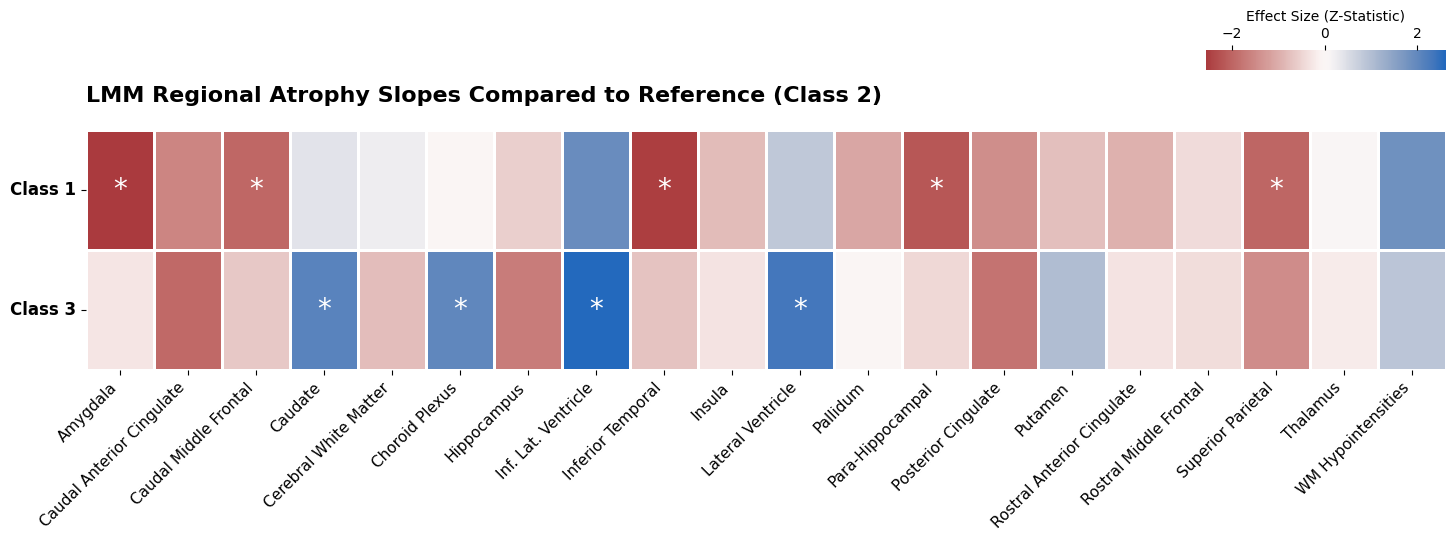

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Manually input the Wald (Z) statistics for each region and class comparison
# Extracted directly from the LMM summaries, but renamed to original unpermuted classes
# Internal Class 3 = Original Class 2 (Reference)
# Internal Class 1 = Original Class 1
# Internal Class 2 = Original Class 3
data = [
    # Subcortical & Global
    ('Thalamus', 'Class 1', 0.063), ('Thalamus', 'Class 3', -0.208),
    ('Caudate', 'Class 1', 0.407), ('Caudate', 'Class 3', 2.100),
    ('Putamen', 'Class 1', -0.785), ('Putamen', 'Class 3', 1.024),
    ('Hippocampus', 'Class 1', -0.581), ('Hippocampus', 'Class 3', -1.694),
    ('choroid_plexus', 'Class 1', -0.012), ('choroid_plexus', 'Class 3', 2.018),
    ('Pallidum', 'Class 1', -1.101), ('Pallidum', 'Class 3', -0.013),
    ('Lateral_Ventricle', 'Class 1', 0.854), ('Lateral_Ventricle', 'Class 3', 2.323),
    ('Inf_Lat_Vent', 'Class 1', 1.927), ('Inf_Lat_Vent', 'Class 3', 2.617),
    ('Cerebral_White_Matter', 'Class 1', 0.255), ('Cerebral_White_Matter', 'Class 3', -0.789),
    ('WM_hypointensities', 'Class 1', 1.830), ('WM_hypointensities', 'Class 3', 0.882),
    # Cortical & Amygdala
    ('Amygdala', 'Class 1', -2.569), ('Amygdala', 'Class 3', -0.296),
    ('insula', 'Class 1', -0.817), ('insula', 'Class 3', -0.310),
    ('inferiortemporal', 'Class 1', -2.512), ('inferiortemporal', 'Class 3', -0.723),
    ('parahippocampal', 'Class 1', -2.195), ('parahippocampal', 'Class 3', -0.452),
    ('posteriorcingulate', 'Class 1', -1.445), ('posteriorcingulate', 'Class 3', -1.817),
    ('superiorparietal', 'Class 1', -1.982), ('superiorparietal', 'Class 3', -1.457),
    ('rostralmiddlefrontal', 'Class 1', -0.404), ('rostralmiddlefrontal', 'Class 3', -0.384),
    ('caudalmiddlefrontal', 'Class 1', -1.973), ('caudalmiddlefrontal', 'Class 3', -0.655),
    ('rostralanteriorcingulate', 'Class 1', -0.955), ('rostralanteriorcingulate', 'Class 3', -0.317),
    ('caudalanteriorcingulate', 'Class 1', -1.570), ('caudalanteriorcingulate', 'Class 3', -1.952)
]

df_heatmap = pd.DataFrame(data, columns=['Region', 'Class', 'Z'])

# 2. Reconstruct P-values from Z-scores
df_heatmap['Pval'] = 2 * stats.norm.cdf(-np.abs(df_heatmap['Z']))

# 3. Clean region names for the x-axis
rename_map = {
    'Thalamus': 'Thalamus',
    'Caudate': 'Caudate',
    'Putamen': 'Putamen',
    'Hippocampus': 'Hippocampus',
    'choroid_plexus': 'Choroid Plexus',
    'Pallidum': 'Pallidum',
    'Lateral_Ventricle': 'Lateral Ventricle',
    'Inf_Lat_Vent': 'Inf. Lat. Ventricle',
    'Cerebral_White_Matter': 'Cerebral White Matter',
    'WM_hypointensities': 'WM Hypointensities',
    'Amygdala': 'Amygdala',
    'insula': 'Insula',
    'inferiortemporal': 'Inferior Temporal',
    'parahippocampal': 'Para-Hippocampal',
    'posteriorcingulate': 'Posterior Cingulate',
    'superiorparietal': 'Superior Parietal',
    'rostralmiddlefrontal': 'Rostral Middle Frontal',
    'caudalmiddlefrontal': 'Caudal Middle Frontal',
    'rostralanteriorcingulate': 'Rostral Anterior Cingulate',
    'caudalanteriorcingulate': 'Caudal Anterior Cingulate'
}
df_heatmap['Region'] = df_heatmap['Region'].map(rename_map)

# 4. Pivot data for heatmap
df_z = df_heatmap.pivot(index='Class', columns='Region', values='Z')
df_p = df_heatmap.pivot(index='Class', columns='Region', values='Pval')

# Sort columns alphabetically for neatness
df_z = df_z.reindex(sorted(df_z.columns), axis=1)
df_p = df_p.reindex(sorted(df_p.columns), axis=1)

# 5. Create annotations (asterisks for unadjusted p < 0.05)
annot_matrix = np.where(df_p < 0.05, '*', '')

# 6. Plotting
fig = plt.figure(figsize=(16, 4))
# Add main axes
ax = fig.add_axes([0.1, 0.15, 0.85, 0.6])
# Add colorbar axes (x, y, width, height) - top right next to title
cbar_ax = fig.add_axes([0.8, 0.9, 0.15, 0.05])

sns.heatmap(
    df_z,
    ax=ax,
    cbar_ax=cbar_ax,
    annot=annot_matrix,
    fmt="", # Format as string to handle the asterisks
    cmap="vlag_r", # Inverted Diverging colormap (negative is red)
    center=0,
    cbar_kws={'label': 'Effect Size (Z-Statistic)', 'orientation': 'horizontal'},
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 20, 'ha': 'center', 'va': 'center'}
)

# Move colorbar ticks to the top
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

ax.set_title('LMM Regional Atrophy Slopes Compared to Reference (Class 2)', fontsize=16, pad=20, fontweight='bold', loc='left')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12, fontweight='bold')

plt.show()

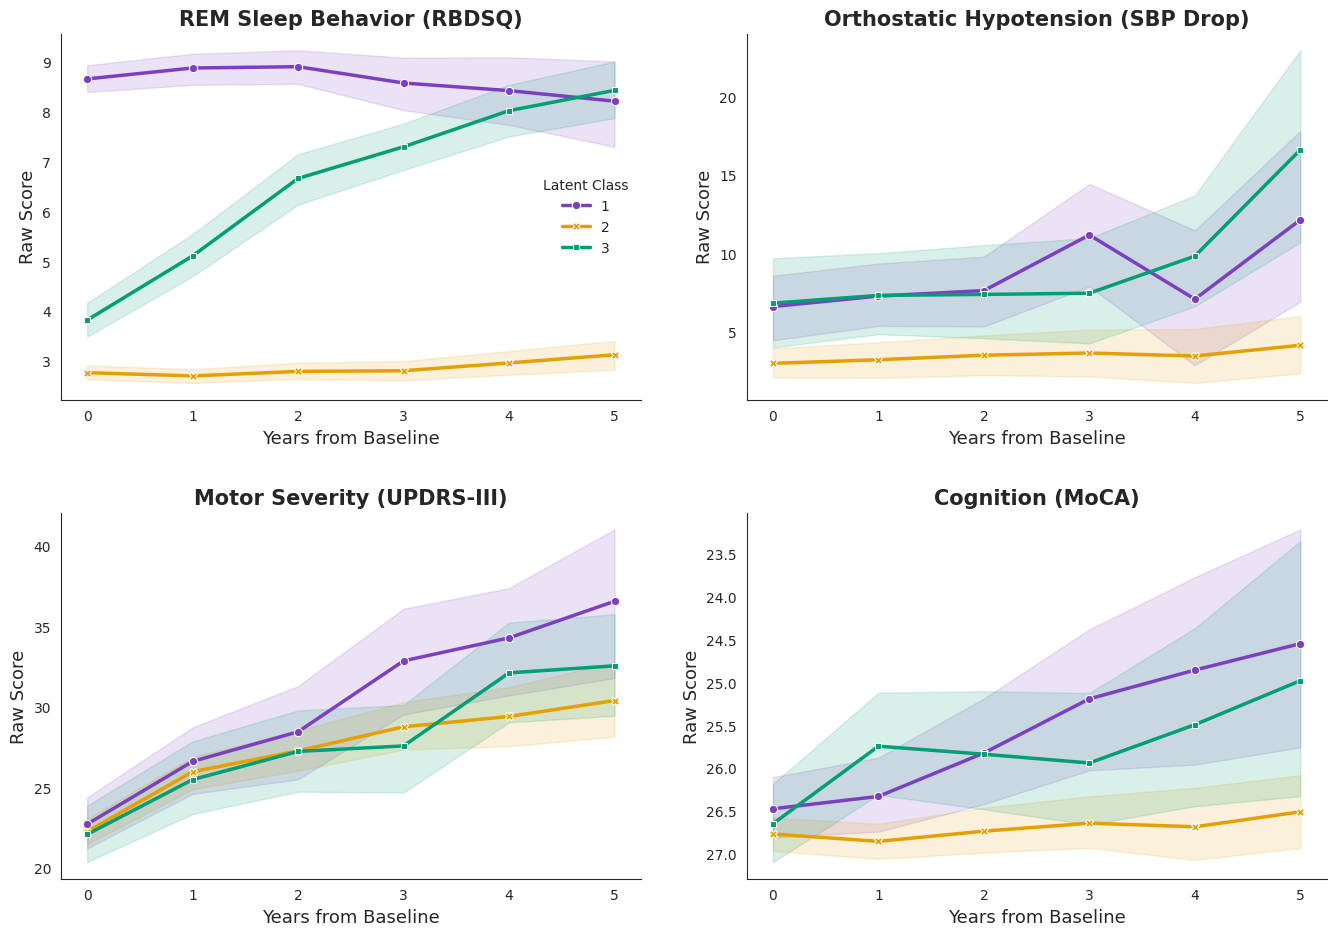

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import rpy2.robjects as ro

# 1. Map classes back to unpermuted originals
class_map = {'1': '1', '2': '3', '3': '2'}

# 2. Prepare Clinical Data (SBP moved to 2nd position)
clinical_vars_raw = {
    'rem': 'REM Sleep Behavior (RBDSQ)',
    'delta_sbp': 'Orthostatic Hypotension (SBP Drop)',
    'updrs3_score': 'Motor Severity (UPDRS-III)',
    'moca': 'Cognition (MoCA)'
}

# Extract class assignments from R
with (ro.default_converter + ro.pandas2ri.converter).context():
    pp_m3 = ro.conversion.get_conversion().rpy2py(ro.r("m3_rmus_intercept_z_bl_trans_linear_ref2$pprob"))
pp_m3['PATNO'] = pp_m3['PATNO'].astype(int)

df_clinical_raw = df_pd_final[['PATNO', 'YEAR'] + list(clinical_vars_raw.keys())].copy()
df_clinical_raw = df_clinical_raw.merge(pp_m3[['PATNO', 'class']], on='PATNO', how='inner')

df_clinical_plot = df_clinical_raw.copy()
df_clinical_plot['orig_class'] = df_clinical_plot['class'].astype(int).astype(str).map(class_map)

# 3. Setup the 2x2 Figure
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Custom Color Palette specified by the user
palette_dict = {
    '1': '#7B3FBF',
    '2': '#E69F00',
    '3': '#009E73'
}
hue_order = ['1', '2', '3']

# 4. Plot Clinical variables
for i, (col, title) in enumerate(clinical_vars_raw.items()):
    ax = axes[i]
    sns.lineplot(data=df_clinical_plot, x='YEAR', y=col, hue='orig_class', style='orig_class',
                 hue_order=hue_order, style_order=hue_order,
                 markers=True, dashes=False, palette=palette_dict,
                 errorbar=('ci', 95), err_style='band', err_kws={'alpha': 0.15},
                 linewidth=2.5, ax=ax, legend=(i==0))

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel("Years from Baseline", fontsize=13)
    ax.set_ylabel("Raw Score", fontsize=13)
    ax.set_xticks([0, 1, 2, 3, 4, 5])

    # Invert y-axis for MoCA so that decline goes downwards
    if col == 'moca':
        ax.invert_yaxis()

    sns.despine(ax=ax)
    if i == 0:
        ax.legend(title='Latent Class', frameon=False)

plt.tight_layout(pad=3.0)
plt.show()